# Analyse Exploratoire

### Import des modules

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
import numpy as np
import re

pd.set_option("display.max_columns", 50)
pd.set_option("display.max_rows", 30) 

### Analyse Exploratoire

In [2]:
building_consumption = pd.read_csv("data/2016_Building_Energy_Benchmarking.csv")

In [3]:
# On regarde comment un batiment est défini dans ce jeu de données 
print(building_consumption.shape)
building_consumption.head(10)

(3376, 46)


,OSEBuildingID,DataYear,BuildingType,PrimaryPropertyType,PropertyName,Address,City,State,ZipCode,TaxParcelIdentificationNumber,CouncilDistrictCode,Neighborhood,Latitude,Longitude,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),ListOfAllPropertyUseTypes,LargestPropertyUseType,LargestPropertyUseTypeGFA,SecondLargestPropertyUseType,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseType,ThirdLargestPropertyUseTypeGFA,YearsENERGYSTARCertified,ENERGYSTARScore,SiteEUI(kBtu/sf),SiteEUIWN(kBtu/sf),SourceEUI(kBtu/sf),SourceEUIWN(kBtu/sf),SiteEnergyUse(kBtu),SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),DefaultData,Comments,ComplianceStatus,Outlier,TotalGHGEmissions,GHGEmissionsIntensity
0,1,2016,NonResidential,Hotel,Mayflower park hotel,405 Olive way,Seattle,WA,98101.0,0659000030,7,DOWNTOWN,47.61220,-122.33799,1927,1.0,12,88434,0,88434,Hotel,Hotel,88434.0,NaN,NaN,NaN,NaN,NaN,60.0,81.699997,84.300003,182.500000,189.000000,7226362.5,7456910.0,2.003882e+06,1.156514e+06,3946027.0,12764.529300,1276453.0,False,NaN,Compliant,NaN,249.98,2.83
1,2,2016,NonResidential,Hotel,Paramount Hotel,724 Pine street,Seattle,WA,98101.0,0659000220,7,DOWNTOWN,47.61317,-122.33393,1996,1.0,11,103566,15064,88502,"Hotel, Parking, Restaurant",Hotel,83880.0,Parking,15064.0,Restaurant,4622.0,NaN,61.0,94.800003,97.900002,176.100006,179.399994,8387933.0,8664479.0,0.000000e+00,9.504252e+05,3242851.0,51450.816410,5145082.0,False,NaN,Compliant,NaN,295.86,2.86
2,3,2016,NonResidential,Hotel,5673-The Westin Seattle,1900 5th Avenue,Seattle,WA,98101.0,0659000475,7,DOWNTOWN,47.61393,-122.33810,1969,1.0,41,956110,196718,759392,Hotel,Hotel,756493.0,NaN,NaN,NaN,NaN,NaN,43.0,96.000000,97.699997,241.899994,244.100006,72587024.0,73937112.0,2.156655e+07,1.451544e+07,49526664.0,14938.000000,1493800.0,False,NaN,Compliant,NaN,2089.28,2.19
3,5,2016,NonResidential,Hotel,HOTEL MAX,620 STEWART ST,Seattle,WA,98101.0,0659000640,7,DOWNTOWN,47.61412,-122.33664,1926,1.0,10,61320,0,61320,Hotel,Hotel,61320.0,NaN,NaN,NaN,NaN,NaN,56.0,110.800003,113.300003,216.199997,224.000000,6794584.0,6946800.5,2.214446e+06,8.115253e+05,2768924.0,18112.130860,1811213.0,False,NaN,Compliant,NaN,286.43,4.67
4,8,2016,NonResidential,Hotel,WARWICK SEATTLE HOTEL (ID8),401 LENORA ST,Seattle,WA,98121.0,0659000970,7,DOWNTOWN,47.61375,-122.34047,1980,1.0,18,175580,62000,113580,"Hotel, Parking, Swimming Pool",Hotel,123445.0,Parking,68009.0,Swimming Pool,0.0,NaN,75.0,114.800003,118.699997,211.399994,215.600006,14172606.0,14656503.0,0.000000e+00,1.573449e+06,5368607.0,88039.984380,8803998.0,False,NaN,Compliant,NaN,505.01,2.88
5,9,2016,Nonresidential COS,Other,West Precinct,810 Virginia St,Seattle,WA,98101.0,0660000560,7,DOWNTOWN,47.61623,-122.33657,1999,1.0,2,97288,37198,60090,Police Station,Police Station,88830.0,NaN,NaN,NaN,NaN,NaN,NaN,136.100006,141.600006,316.299988,320.500000,12086616.0,12581712.0,0.000000e+00,2.160444e+06,7371434.0,47151.816410,4715182.0,False,NaN,Compliant,NaN,301.81,3.10
6,10,2016,NonResidential,Hotel,Camlin,1619 9th Avenue,Seattle,WA,98101.0,0660000825,7,DOWNTOWN,47.61390,-122.33283,1926,1.0,11,83008,0,83008,Hotel,Hotel,81352.0,NaN,NaN,NaN,NaN,NaN,27.0,70.800003,74.500000,146.600006,154.699997,5758795.0,6062767.5,0.000000e+00,8.239199e+05,2811215.0,29475.800780,2947580.0,False,NaN,Compliant,NaN,176.14,2.12
7,11,2016,NonResidential,Other,Paramount Theatre,911 Pine St,Seattle,WA,98101.0,0660000955,7,DOWNTOWN,47.61327,-122.33136,1926,1.0,8,102761,0,102761,Other - Entertainment/Public Assembly,Other - Entertainment/Public Assembly,102761.0,NaN,NaN,NaN,NaN,NaN,NaN,61.299999,68.800003,141.699997,152.300003,6298131.5,7067881.5,2.276286e+06,1.065843e+06,3636655.0,3851.890137,385189.0,False,NaN,Compliant,NaN,221.51,2.16
8,12,2016,NonResidential,Hotel,311wh-Pioneer Square,612 2nd Ave,Seattle,WA,98104.0,0939000080,7,DOWNTOWN,47.60294,-122.33263,1904,1.0,15,163984,0,163984,Hotel,Hotel,163984.0,Na

In [4]:
# On regarde le nombre de valeurs manquantes par colonne ainsi que leur type 
building_consumption.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3376 entries, 0 to 3375
Data columns (total 46 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   OSEBuildingID                    3376 non-null   int64  
 1   DataYear                         3376 non-null   int64  
 2   BuildingType                     3376 non-null   object 
 3   PrimaryPropertyType              3376 non-null   object 
 4   PropertyName                     3376 non-null   object 
 5   Address                          3376 non-null   object 
 6   City                             3376 non-null   object 
 7   State                            3376 non-null   object 
 8   ZipCode                          3360 non-null   float64
 9   TaxParcelIdentificationNumber    3376 non-null   object 
 10  CouncilDistrictCode              3376 non-null   int64  
 11  Neighborhood                     3376 non-null   object 
 12  Latitude            

#### TERMINER L'ANALYSE EXPLORATOIRE 

A réaliser : 
- Une analyse descriptive des données, y compris une explication du sens des colonnes gardées, des arguments derrière la suppression de lignes ou de colonnes, des statistiques descriptives et des visualisations pertinentes.

## Premier nettoyage (sur colonne BuildingType) et changement des types

### Changement de type

In [5]:
# Changement du type de la colonne ZipCode (actuellement float) c'est simplement pour avoir des chiffres ronds
# building_consumption['ZipCode'] = building_consumption['ZipCode'].apply(lambda x: str(int(x)) if pd.notna(x) else None)
building_consumption['ZipCode'] = building_consumption['ZipCode'].round().astype('Int64')
building_consumption['ZipCode'].head()

0    98101
1    98101
2    98101
3    98101
4    98121
Name: ZipCode, dtype: Int64

In [6]:
# Changement du type de la colonne NumberofBuildings (actuellement float) c'est simplement pour avoir des chiffres ronds
# building_consumption['NumberofBuildings'] = building_consumption['NumberofBuildings'].apply(lambda x: str(int(x)) if pd.notna(x) else None)
building_consumption['NumberofBuildings'] = building_consumption['NumberofBuildings'].round().astype('Int64')
building_consumption['NumberofBuildings'].head()

0    1
1    1
2    1
3    1
4    1
Name: NumberofBuildings, dtype: Int64

In [7]:
# # Changement du type de la colonne LargestPropertyUseTypeGFA (actuellement float) c'est simplement pour avoir des chiffres ronds
# building_consumption['LargestPropertyUseTypeGFA'] = building_consumption['LargestPropertyUseTypeGFA'].apply(lambda x: str(int(x)) if pd.notna(x) else None)
building_consumption['LargestPropertyUseTypeGFA'] = building_consumption['LargestPropertyUseTypeGFA'].round().astype('Int64')
building_consumption['LargestPropertyUseTypeGFA'].head()


0     88434
1     83880
2    756493
3     61320
4    123445
Name: LargestPropertyUseTypeGFA, dtype: Int64

### Control des colonnes primaires 

In [8]:
# Check pour voir si il y a des doublons dans la colonne OSEBuildingID
building_consumption['OSEBuildingID'].duplicated().sum()

np.int64(0)

In [9]:
# Check pour voir si il y a des valeurs bizarre dans les colonnes primaires
print(building_consumption['City'].value_counts(dropna=False))
print(building_consumption['State'].value_counts(dropna=False))
print(building_consumption['Outlier'].value_counts(dropna=False))
print(building_consumption['Comments'].value_counts(dropna=False))

City
Seattle    3376
Name: count, dtype: int64
State
WA    3376
Name: count, dtype: int64
Outlier
NaN             3344
Low outlier       23
High outlier       9
Name: count, dtype: int64
Comments
NaN    3376
Name: count, dtype: int64


### Premier nettoyage 

In [10]:
building_consumption['BuildingType'].value_counts(dropna=False)
# NonResidential : 1460 bâtiments étiquetés NonResidential = A garder 
# Multifamily LR (1-4) : 1018 bâtiments de type Multifamily Low Rise (1 à 4 étages) = Ne pas garder
# Multifamily MR (5-9) : 580 bâtiments multifamiliaux Medium Rise (5 à 9 étages) = Ne pas garder
# Multifamily HR (10+) : 110 bâtiments multifamiliaux High Rise (10 étages ou plus) = Ne pas garder
# SPS-District K-12 : 98 écoles primaires/secondaires = A garder
# Nonresidential COS : 85 bâtiments non résidentiels (City of Seattle aparement) = A garder
# Campus : 24 campus (probablement universités) = Je ne sais pas si il est possible de dormir dedans
# Nonresidential WA : 1 seul bâtiment (Washington state aparement) = A garder

BuildingType
NonResidential          1460
Multifamily LR (1-4)    1018
Multifamily MR (5-9)     580
Multifamily HR (10+)     110
SPS-District K-12         98
Nonresidential COS        85
Campus                    24
Nonresidential WA          1
Name: count, dtype: int64

Text(0, 0.5, 'BuildingType')

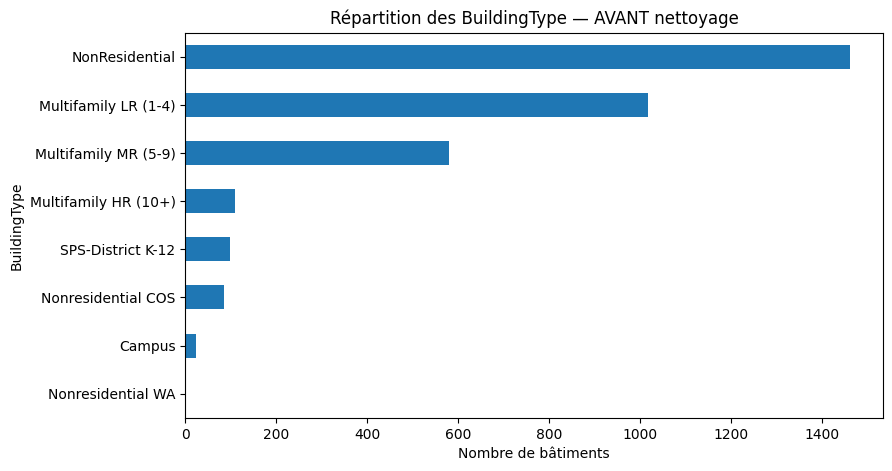

In [11]:
# Comptage brut
bt_counts_before = building_consumption['BuildingType'].value_counts(dropna=False)

# Figure
plt.figure(figsize=(9, 5))
bt_counts_before.sort_values().plot(kind='barh')
plt.title("Répartition des BuildingType — AVANT nettoyage")
plt.xlabel("Nombre de bâtiments")
plt.ylabel("BuildingType")

In [12]:
buildingtype_to_keep = ['NonResidential', 'SPS-District K-12', 'Nonresidential COS', 'Campus', 'Nonresidential WA']
df_premier_nettoyage = building_consumption[building_consumption['BuildingType'].isin(buildingtype_to_keep)]
print(df_premier_nettoyage.shape)
df_premier_nettoyage['BuildingType'].value_counts(dropna=False)

(1668, 46)


BuildingType
NonResidential        1460
SPS-District K-12       98
Nonresidential COS      85
Campus                  24
Nonresidential WA        1
Name: count, dtype: int64

## Deuxieme nettoyage (sur PrimaryPropertyType)

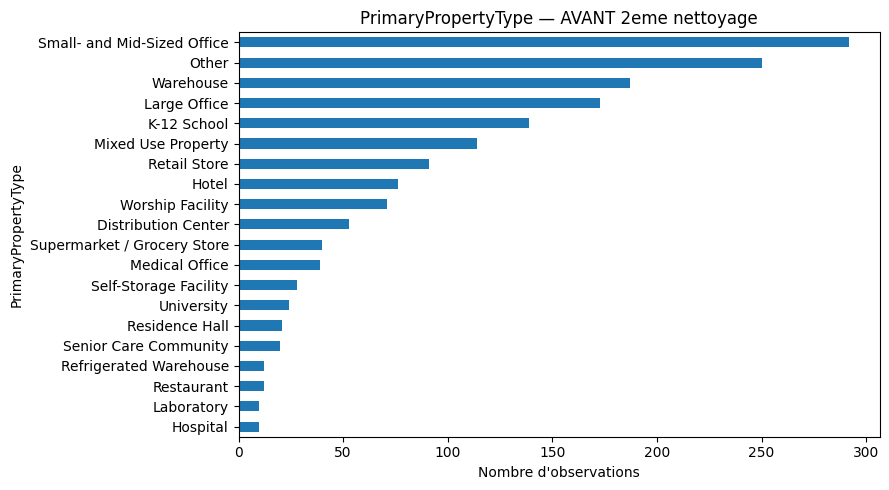

In [13]:
topN = 20
before_ct = df_premier_nettoyage['PrimaryPropertyType'].value_counts().head(topN)

plt.figure(figsize=(9,5))
before_ct.sort_values().plot(kind='barh')
plt.title(f"PrimaryPropertyType — AVANT 2eme nettoyage")
plt.xlabel("Nombre d'observations")
plt.ylabel("PrimaryPropertyType")
plt.tight_layout()
plt.show()

In [14]:
primarypropoertytype_not_to_keep = ['Residence Hall', 'Senior Care Community', 'Low-Rise Multifamily']
df_deuxieme_nettoyage = df_premier_nettoyage[~df_premier_nettoyage['PrimaryPropertyType'].isin(primarypropoertytype_not_to_keep)]
print(df_deuxieme_nettoyage.shape)
df_deuxieme_nettoyage['PrimaryPropertyType'].value_counts(dropna=False)

(1624, 46)


PrimaryPropertyType
Small- and Mid-Sized Office    292
Other                          250
Warehouse                      187
Large Office                   173
K-12 School                    139
Mixed Use Property             114
Retail Store                    91
Hotel                           76
Worship Facility                71
Distribution Center             53
Supermarket / Grocery Store     40
Medical Office                  39
Self-Storage Facility           28
University                      24
Refrigerated Warehouse          12
Restaurant                      12
Hospital                        10
Laboratory                      10
Office                           3
Name: count, dtype: int64

## Troisieme nettoyage (retrait des colonnes vides et inutiles pour l'étude)

In [15]:
def identifier_les_colonnes_entierement_vide(df):
    empty_cols = df.columns[df.isna().all()]
    if len(empty_cols) == 0:
        print("aucune colonne entièrement vide")
    else:
        print('colonne entièrement vide :')
        for col in empty_cols:
            print(f'- {col}')

In [16]:
identifier_les_colonnes_entierement_vide(df_deuxieme_nettoyage)

colonne entièrement vide :
- Comments


In [17]:
df_deuxieme_nettoyage[df_deuxieme_nettoyage['Outlier'].notna()]

,OSEBuildingID,DataYear,BuildingType,PrimaryPropertyType,PropertyName,Address,City,State,ZipCode,TaxParcelIdentificationNumber,CouncilDistrictCode,Neighborhood,Latitude,Longitude,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),ListOfAllPropertyUseTypes,LargestPropertyUseType,LargestPropertyUseTypeGFA,SecondLargestPropertyUseType,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseType,ThirdLargestPropertyUseTypeGFA,YearsENERGYSTARCertified,ENERGYSTARScore,SiteEUI(kBtu/sf),SiteEUIWN(kBtu/sf),SourceEUI(kBtu/sf),SourceEUIWN(kBtu/sf),SiteEnergyUse(kBtu),SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),DefaultData,Comments,ComplianceStatus,Outlier,TotalGHGEmissions,GHGEmissionsIntensity
226,350,2016,NonResidential,Large Office,Second And Spring Building,1100 Second Avenue,Seattle,WA,98101,0942000045,7,DOWNTOWN,47.60642,-122.33581,1958,1,6,172842,25920,146922,"Data Center, Office, Parking",Office,99890,Data Center,39336.0,Parking,25000.0,NaN,NaN,297.399994,299.200012,909.599976,911.500000,4.139950e+07,4.165040e+07,0.0,1.166315e+07,39794668.0,16048.309570,1604831.0,False,NaN,Non-Compliant,High outlier,362.66,2.10
384,539,2016,NonResidential,Retail Store,University Center,4501 Roosevelt Way NE,Seattle,WA,98105,5335200380,4,NORTHEAST,47.66178,-122.31812,1987,1,2,69492,0,69492,Retail Store,Retail Store,69800,Other,0.0,NaN,NaN,NaN,100.0,4.600000,4.600000,14.300000,14.300000,3.189628e+05,3.189628e+05,0.0,9.348260e+04,318963.0,0.000000,0.0,False,NaN,Non-Compliant,Low outlier,2.22,0.03
448,608,2016,NonResidential,Large Office,411 1ST AVE S (ID608),411 1ST AVE S,Seattle,WA,98104,5247800200,2,DOWNTOWN,47.59878,-122.33458,1913,5,7,154159,0,154159,Office,Office,193154,NaN,NaN,NaN,NaN,NaN,100.0,58.000000,58.799999,28.000000,28.700001,1.119592e+07,1.134876e+07,0.0,4.715030e+05,1608768.0,3430.500488,343050.0,False,NaN,Non-Compliant,Low outlier,29.43,0.19
517,704,2016,NonResidential,Large Office,401 Elliott Ave West,401 Elliot Ave West,Seattle,WA,98119,7666202110,7,MAGNOLIA / QUEEN ANNE,47.62235,-122.36378,2000,1,4,129551,42500,87051,"Data Center, Office, Parking",Office,82273,Parking,42500.0,Data Center,4778.0,NaN,1.0,311.700012,311.700012,978.900024,978.900024,2.713719e+07,2.713719e+07,0.0,7.953454e+06,27137187.0,0.000000,0.0,False,NaN,Non-Compliant,High outlier,189.18,1.46
839,19967,2016,SPS-District K-12,K-12 School,Queen Anne Gym,1431 2nd Ave N,Seattle,WA,98109,0811000005,7,MAGNOLIA / QUEEN ANNE,47.63203,-122.35337,2001,1,1,35805,0,35805,K-12 School,K-12 School,35805,NaN,NaN,NaN,NaN,NaN,100.0,12.100000,12.100000,27.000000,27.000000,4.314717e+05,4.314717e+05,0.0,7.228240e+04,246628.0,1848.439575,184844.0,True,NaN,Error - Correct Default Data,Low outlier,11.54,0.32
1045,20617,2016,NonResidential,Retail Store,Seattle Habitat Store,21 S Nevada St,Seattle,WA,98134,1824049074,2,GREATER DUWAMISH,47.56535,-122.34054,1953,1,1,39900,0,39900,"Non-Refrigerated Warehouse, Retail Store",Retail Store,25000,Non-Refrigerated Warehouse,15000.0,NaN,NaN,NaN,100.0,3.600000,3.600000,6.400000,6.400000,1.454688e+05,1.454688e+05,0.0,1.436250e+04,49005.0,964.640015,96464.0,True,NaN,Error - Correct Default Data,Low outlier,5.46,0.14
1229,21315,2016,NonResidential,Small- and Mid-Sized Office,1518 Fifith Ave,1520 Fifth Ave,Seattle,WA,98101,1975700135,7,DOWNTOWN,47.61119,-122.33581,1903,1,3,57720,0,57720,Office,Office,25000,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,1.000000,3.000000,3.000000,2.410550e+04,2.410550e+04,0.0,7.064900e+03,24105.0,0.000000,0.0,False,NaN,Non-Compliant,Low outlier,0.17,0.00
1295,21474,2016,NonResidential,Other,The Lusty Lady,1315 1st Ave,Seattle,WA,98101,1976200060,7,DOWNTOWN,47.60711,-122.33886,1900,1,3,49760,0,49760,Other,Other,24019,NaN,NaN,NaN,NaN,NaN,NaN,1.800000,1.800000,5.800000,5.800000,4.429350e+04,4.429350e+04,0.0,1.298170e+04,44294.0,0.000000,0.0,False,NaN,Non-Compliant,Low outlier,0.31,0.01
1611,22830,2016,NonResidential,Worship F

In [18]:
# df_troisieme_nettoyage = df_deuxieme_nettoyage.drop(columns=['DataYear', 'PropertyName', 'Address', 'City', 'State', 'Latitude', 
#                                                              'Longitude', 'TaxParcelIdentificationNumber', 'Comments', 'DefaultData', 'Outlier'])

df_troisieme_nettoyage = df_deuxieme_nettoyage.drop(columns=['PropertyName', 'Address', 'City', 'State',
                                                             'TaxParcelIdentificationNumber', 'Comments', 'DefaultData', 'Outlier'])
df_troisieme_nettoyage.reset_index(inplace=True, drop=True)
print(df_troisieme_nettoyage.shape)
df_troisieme_nettoyage

(1624, 38)


,OSEBuildingID,DataYear,BuildingType,PrimaryPropertyType,ZipCode,CouncilDistrictCode,Neighborhood,Latitude,Longitude,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),ListOfAllPropertyUseTypes,LargestPropertyUseType,LargestPropertyUseTypeGFA,SecondLargestPropertyUseType,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseType,ThirdLargestPropertyUseTypeGFA,YearsENERGYSTARCertified,ENERGYSTARScore,SiteEUI(kBtu/sf),SiteEUIWN(kBtu/sf),SourceEUI(kBtu/sf),SourceEUIWN(kBtu/sf),SiteEnergyUse(kBtu),SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),ComplianceStatus,TotalGHGEmissions,GHGEmissionsIntensity
0,1,2016,NonResidential,Hotel,98101,7,DOWNTOWN,47.61220,-122.33799,1927,1,12,88434,0,88434,Hotel,Hotel,88434,NaN,NaN,NaN,NaN,NaN,60.0,81.699997,84.300003,182.500000,189.000000,7.226362e+06,7.456910e+06,2003882.00,1.156514e+06,3.946027e+06,12764.529300,1.276453e+06,Compliant,249.98,2.83
1,2,2016,NonResidential,Hotel,98101,7,DOWNTOWN,47.61317,-122.33393,1996,1,11,103566,15064,88502,"Hotel, Parking, Restaurant",Hotel,83880,Parking,15064.0,Restaurant,4622.0,NaN,61.0,94.800003,97.900002,176.100006,179.399994,8.387933e+06,8.664479e+06,0.00,9.504252e+05,3.242851e+06,51450.816410,5.145082e+06,Compliant,295.86,2.86
2,3,2016,NonResidential,Hotel,98101,7,DOWNTOWN,47.61393,-122.33810,1969,1,41,956110,196718,759392,Hotel,Hotel,756493,NaN,NaN,NaN,NaN,NaN,43.0,96.000000,97.699997,241.899994,244.100006,7.258702e+07,7.393711e+07,21566554.00,1.451544e+07,4.952666e+07,14938.000000,1.493800e+06,Compliant,2089.28,2.19
3,5,2016,NonResidential,Hotel,98101,7,DOWNTOWN,47.61412,-122.33664,1926,1,10,61320,0,61320,Hotel,Hotel,61320,NaN,NaN,NaN,NaN,NaN,56.0,110.800003,113.300003,216.199997,224.000000,6.794584e+06,6.946800e+06,2214446.25,8.115253e+05,2.768924e+06,18112.130860,1.811213e+06,Compliant,286.43,4.67
4,8,2016,NonResidential,Hotel,98121,7,DOWNTOWN,47.61375,-122.34047,1980,1,18,175580,62000,113580,"Hotel, Parking, Swimming Pool",Hotel,123445,Parking,68009.0,Swimming Pool,0.0,NaN,75.0,114.800003,118.699997,211.399994,215.600006,1.417261e+07,1.465650e+07,0.00,1.573449e+06,5.368607e+06,88039.984380,8.803998e+06,Compliant,505.01,2.88
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1619,50222,2016,Nonresidential COS,Office,<NA>,2,GREATER DUWAMISH,47.56722,-122.31154,1990,1,1,12294,0,12294,Office,Office,12294,NaN,NaN,NaN,NaN,NaN,46.0,69.099998,76.699997,161.699997,176.100006,8.497457e+05,9.430032e+05,0.00,1.536550e+05,5.242709e+05,3254.750244,3.254750e+05,Error - Correct Default Data,20.94,1.70
1620,50223,2016,Nonresidential COS,Other,<NA>,2,DOWNTOWN,47.59625,-122.32283,2004,1,1,16000,0,16000,Other - Recreation,Other - Recreation,16000,NaN,NaN,NaN,NaN,NaN,NaN,59.400002,65.900002,114.199997,118.900002,9.502762e+05,1.053706e+06,0.00,1.162210e+05,3.965461e+05,5537.299805,5.537300e+05,Compliant,32.17,2.01
1621,50224,2016,Nonresidential COS,Other,<NA>,7,MAGNOLIA / QUEEN ANNE,47.63644,-122.35784,1974,1,1,13157,0,13157,"Fitness Center/Health Club/Gym, Other - Recrea...",Other - Recreation,7583,Fitness Center/Health Club/Gym,5574.0,Swimming Pool,0.0,NaN,NaN,438.200012,460.100006,744.799988,767.799988,5.765898e+06,6.053764e+06,0.00,5.252517e+05,1.792159e+06,39737.390630,3.973739e+06,Compliant,223.54,16.99
1622,50225,2016,Nonresidential COS,Mixed Use Property,<NA>,1,GREATER DUWAMISH,47.52832,-122.32431,1989,1,1,14101,0,14101,"Fitness Center/Health Club/Gym, Food Service, ...",Other - Recreation,6601,Fitness Center/Health Club/Gym,6501.0,Pre-school/Daycare,484.0,NaN,NaN,51.000000,55.500000,105.300003,110.800003,7.194712e+05,7.828413e+05,0.00,1.022480e+05,3.488702e+05,3706.010010,3.706010e+05,Compliant,22.11,1.57


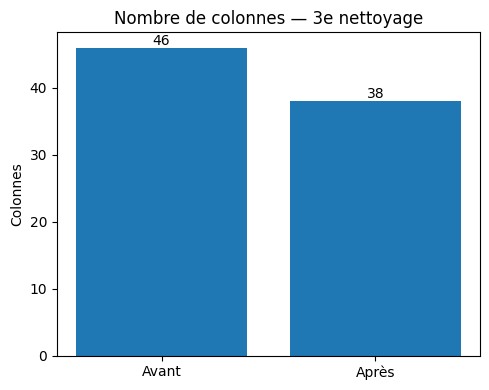

In [19]:
cols_before = df_deuxieme_nettoyage.shape[1]
cols_after  = df_troisieme_nettoyage.shape[1]

plt.figure(figsize=(5,4))
plt.bar(['Avant','Après'], [cols_before, cols_after])
plt.title("Nombre de colonnes — 3e nettoyage")
plt.ylabel("Colonnes")
for x, v in zip(['Avant','Après'], [cols_before, cols_after]):
    plt.text(x, v, str(v), ha='center', va='bottom')
plt.tight_layout()
plt.show()

## Identifier les données aberrantes 

In [20]:
# def analyse_colonne_numerique(df, col):
#     """
#     Analyse une colonne numérique d’un DataFrame :
#     - Histogramme de la distribution
#     - Boxplot pour repérer les valeurs aberrantes
#     - Détection des outliers via la méthode IQR
#     - Simple print du top 5 des données max et min

#     Paramètres :
#         df : DataFrame pandas
#         col : nom de la colonne
        
#     Retourne :
#         DataFrame contenant les valeurs aberrantes
#     """
#     if col not in df.columns:
#         print(f"Colonne '{col}' introuvable.")
#         return pd.DataFrame()
    
#     if not pd.api.types.is_numeric_dtype(df[col]):
#         print(f"Colonne '{col}' non numérique.")
#         return pd.DataFrame()

#     col_data = df[col].dropna()

#     # 1. Histogramme
#     plt.figure(figsize=(10, 4))
#     plt.hist(col_data, bins=50, alpha=0.7)
#     plt.title(f"Distribution - {col}")
#     plt.xlabel(col)
#     plt.ylabel("Fréquence")
#     plt.grid(True)
#     plt.tight_layout()
#     plt.show()

#     # 2. Boxplot
#     plt.figure(figsize=(10, 1.5))
#     # Mettre à True vert=False si je veux le boxplot verticalement
#     plt.boxplot(col_data, vert=False)
#     plt.title(f"Boxplot - {col}")
#     plt.grid(True)
#     plt.tight_layout()
#     plt.show()

#     # 3. Détection des outliers par IQR
#     Q1 = col_data.quantile(0.25)
#     Q3 = col_data.quantile(0.75)
#     IQR = Q3 - Q1
#     lower_bound = Q1 - 1.5 * IQR
#     upper_bound = Q3 + 1.5 * IQR

#     outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

#     print(f"{len(outliers)} valeur(s) aberrante(s) détectée(s) dans '{col}'")
    
#     col_sorted = col_data.sort_values()

#     print("\nTop 10 des valeurs min :")
#     for val in col_sorted.head(10):
#         print(f"- {val}")

#     print("\nTop 10 des valeurs max :")
#     for val in col_sorted.tail(10):
#         print(f"- {val}")

#     print()
#     nb_na = df[col].isna().sum()
#     print(f'Nombre de valeur NaN : {nb_na}')
#     print()
#     if nb_na > 0:
#         print("Lignes contenant NaN :")
#         print(df[df[col].isna()])

#     return outliers


In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def analyse_colonne_numerique(df, col):
    """
    Analyse d'une colonne numérique :
    - Boxplot horizontal coloré
    - Outliers détectés par IQR et affichés en rouge
    - Print des top 10 min/max + NaN
    - Retourne le DataFrame des outliers
    """
    if col not in df.columns:
        print(f"Colonne '{col}' introuvable.")
        return pd.DataFrame()
    if not pd.api.types.is_numeric_dtype(df[col]):
        print(f"Colonne '{col}' non numérique.")
        return pd.DataFrame()

    col_data = df[col].dropna()
    if col_data.empty:
        print(f"Aucune donnée non nulle dans '{col}'.")
        return pd.DataFrame()

    # 1. bornes IQR
    Q1 = col_data.quantile(0.25)
    Q3 = col_data.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    # masque outliers sur la série SANS NaN
    mask_out = (col_data < lower) | (col_data > upper)
    # lignes complètes d'origine
    outliers_df = df.loc[col_data.index[mask_out]]

    # 2. boxplot horizontal coloré
    plt.figure(figsize=(10, 1.8))
    bp = plt.boxplot(
        col_data,
        vert=False,
        patch_artist=True,  # pour pouvoir colorer
        boxprops=dict(facecolor="#8dd3c7", color="#006d6f"),
        medianprops=dict(color="#ff7f0e", linewidth=2),
        whiskerprops=dict(color="#006d6f"),
        capprops=dict(color="#006d6f"),
        # on met les marqueurs des outliers de base à rien, on va les tracer à la main
        flierprops=dict(marker='', markersize=0)
    )

    # 3. on trace NOUS-MÊMES les outliers en rouge
    out_vals = col_data[mask_out]
    if len(out_vals) > 0:
        y_jitter = np.random.normal(1, 0.02, size=len(out_vals))  # autour de y=1
        plt.scatter(out_vals, y_jitter, color="red", s=28, alpha=0.9, label="Outliers")

    plt.title(f"Boxplot - {col}")
    plt.xlabel(col)
    plt.yticks([])  # on masque l'axe Y (1 seule ligne)
    plt.grid(True, axis="x", alpha=0.25)
    if len(out_vals) > 0:
        plt.legend(loc="best")
    plt.tight_layout()
    plt.show()

    # 4. résumé texte
    print(f"Outliers détectés : {mask_out.sum()}  |  Bornes IQR = [{lower:.3g}, {upper:.3g}]")

    col_sorted = col_data.sort_values()
    print("\nTop 10 des valeurs min :")
    for v in col_sorted.head(10):
        print(f"- {v}")
    print("\nTop 10 des valeurs max :")
    for v in col_sorted.tail(10):
        print(f"- {v}")

    nb_na = df[col].isna().sum()
    print(f"\nNombre de valeurs NaN : {nb_na}")
    if nb_na > 0:
        print("\nLignes contenant NaN :")
        print(df[df[col].isna()])

    return outliers_df


In [22]:
print(df_troisieme_nettoyage['OSEBuildingID'].value_counts(dropna=False))
print(df_troisieme_nettoyage['ZipCode'].value_counts(dropna=False))
print(df_troisieme_nettoyage['CouncilDistrictCode'].value_counts(dropna=False))

OSEBuildingID
1        1
2        1
3        1
5        1
8        1
        ..
50222    1
50223    1
50224    1
50225    1
50226    1
Name: count, Length: 1624, dtype: int64
ZipCode
98134    182
98104    155
98101    145
98109    137
98108    120
        ... 
98165      1
98113      1
98177      1
98020      1
98145      1
Name: count, Length: 49, dtype: Int64
CouncilDistrictCode
7    520
2    393
3    196
4    157
5    127
1    118
6    113
Name: count, dtype: int64


### Retrait des lignes abérantes (fait avant l'analyse pour ne pas fausser les résultats suivants)

In [23]:
# ------------------------------
# lignes retirée avec la raison :
# ------------------------------

# OSEBuildingID = 49784
# Valeurs négatives dans : 'Electricity(kBtu)', 'TotalGHGEmissions', 'GHGEmissionsIntensity'
# Risque de fausser les calcules
df_troisieme_nettoyage = df_troisieme_nettoyage[df_troisieme_nettoyage['OSEBuildingID'] != 49784]

# OSEBuildingID = 49967
# Valeurs trop importante dans toutes les colonnes en raison du nombre de bâtiment dont est composé l'ensemble
# Risque de fausser les calcules
df_troisieme_nettoyage = df_troisieme_nettoyage[df_troisieme_nettoyage['OSEBuildingID'] != 49967]

# SiteEnergyUse(kBtu)
# Retrait de toutes les lignes à 0 (ça risque de fausser les études des modèles)
df_troisieme_nettoyage = df_troisieme_nettoyage[df_troisieme_nettoyage['SiteEnergyUse(kBtu)'] != 0]

# # Retrait des outliers :
# df_troisieme_nettoyage = df_troisieme_nettoyage[df_troisieme_nettoyage['SiteEnergyUse(kBtu)'] != 448385312.0]
# df_troisieme_nettoyage = df_troisieme_nettoyage[df_troisieme_nettoyage['SiteEnergyUse(kBtu)'] != 16808.90039]
# df_troisieme_nettoyage = df_troisieme_nettoyage[df_troisieme_nettoyage['SiteEnergyUse(kBtu)'] != 24105.5]
# df_troisieme_nettoyage = df_troisieme_nettoyage[df_troisieme_nettoyage['SiteEnergyUse(kBtu)'] != 44293.5]
# df_troisieme_nettoyage = df_troisieme_nettoyage[df_troisieme_nettoyage['SiteEnergyUse(kBtu)'] != 57133.19922]

# LargestPropertyUseTypeGFA
# Au départ je voulais mettre le GFATotal sur le LargestPropertyUseTypeGFA pour ceux ayant 1 building
# Mais quand j'ai regardé d'autres valeurs avec 1 building si le PropertyGFATotal ou PropertyGFABuilding(s) était les mêmes et ce n'est pas toujours le cas
# Donc je les retires simplement pour le test avec le 3ème jeu de donnée.
ids_a_supprimer_LargestPropertyUseTypeGFA = [496, 21103, 25568, 25711]
df_troisieme_nettoyage = df_troisieme_nettoyage[~df_troisieme_nettoyage['OSEBuildingID'].isin(ids_a_supprimer_LargestPropertyUseTypeGFA)]

# NumberofFloors
# Après vérification sur wikipedia il n'y a pas de batiment à Seatle supérieur à 76 étages
df_troisieme_nettoyage = df_troisieme_nettoyage[df_troisieme_nettoyage['NumberofFloors'] != 99]

# SecondLargestPropertyUseTypeGFA
# Certaine surface de SecondLargestPropertyUseTypeGFA sont à zero alors que le nombre de building est supérieur à 1
# Je retire donc ces valeurs
index_a_retirer = df_troisieme_nettoyage[
    (df_troisieme_nettoyage['NumberofBuildings'] > 1) & (df_troisieme_nettoyage['SecondLargestPropertyUseTypeGFA'] == 0)].index
df_troisieme_nettoyage = df_troisieme_nettoyage.drop(index_a_retirer)

# NumberofBuildings
# Il y a 2 lignes avec NaN dans NumberofBuildings
# Toutes les colonnes avec des données sur les dépenses energetiques sont vides pour les 2 valeurs à NaN
# je vais donc les retirer
df_troisieme_nettoyage = df_troisieme_nettoyage.dropna(subset=['NumberofBuildings'])


# NumberofBuildings
# Il y a 57 lignes à 0 dans NumberofBuildings, cette fonction permet de remplacer ces valeurs par la plus plausible
def corriger_number_of_buildings(df):
    """
    Remplace NumberofBuildings == 0 par le nombre minimal plausible
    """
    df = df.copy()
    gfa_cols = [
        "LargestPropertyUseTypeGFA",
        "SecondLargestPropertyUseTypeGFA",
        "ThirdLargestPropertyUseTypeGFA"
    ]

    # nb de GFA strictement > 0 par ligne
    nb_gfa_pos = (df[gfa_cols].fillna(0) > 0).sum(axis=1)

    mask_zero = df["NumberofBuildings"] == 0
    df.loc[mask_zero, "NumberofBuildings"] = np.maximum(1, nb_gfa_pos[mask_zero]).astype(int)

    return df

df_troisieme_nettoyage = corriger_number_of_buildings(df_troisieme_nettoyage)



In [24]:
# from scipy import stats
# import numpy as np

# # Calcul du Z-score sur la version log-transformée de la consommation
# z_log = np.abs(stats.zscore(np.log1p(df_troisieme_nettoyage["SiteEnergyUse(kBtu)"])))

# # Seuil classique = 3 (on garde 99.7% des données)
# df_clean_zscore = df_troisieme_nettoyage[z_log < 3]

# print("Lignes avant :", len(df_troisieme_nettoyage))
# print("Lignes après :", len(df_clean_zscore))
# print("Nombre de lignes supprimées :", len(df_troisieme_nettoyage) - len(df_clean_zscore))

# # # Remplacer le df de travail
# df_troisieme_nettoyage = df_clean_zscore

In [25]:
from scipy import stats
import numpy as np

# === Z-score très simple sur plusieurs colonnes ===
colonnes_zscore = [
    "SiteEnergyUse(kBtu)",
    "PropertyGFATotal"#,
    #"NumberofBuildings"#,
    #"LargestPropertyUseTypeGFA"
]

# On garde seulement celles qui existent
colonnes_zscore = [c for c in colonnes_zscore if c in df_troisieme_nettoyage.columns]

# Conversion en numérique PUIS en float (important)
df_tmp = df_troisieme_nettoyage[colonnes_zscore].apply(pd.to_numeric, errors="coerce").astype(float)

# Calcul du Z-score sur la version log-transformée du df_tmp
z = np.abs(stats.zscore(np.log1p(df_tmp), nan_policy="omit"))

# Garde uniquement les lignes normales (valeurs < 3)
df_clean_zscore = df_troisieme_nettoyage[(z < 3).all(axis=1)]

print("Lignes avant :", len(df_troisieme_nettoyage))
print("Lignes après :", len(df_clean_zscore))
print("Lignes supprimées :", len(df_troisieme_nettoyage) - len(df_clean_zscore))

# On met à jour ton DataFrame
df_troisieme_nettoyage = df_clean_zscore.copy()


Lignes avant : 1593
Lignes après : 1570
Lignes supprimées : 23


### Analyse colonne YearBuilt

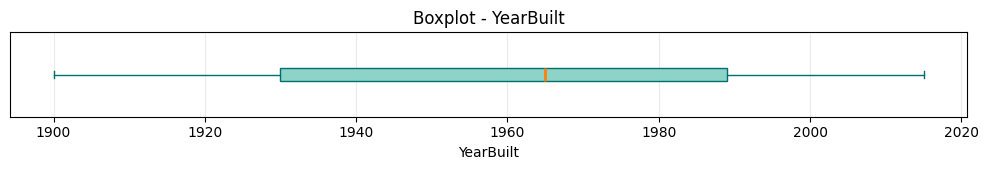

Outliers détectés : 0  |  Bornes IQR = [1.84e+03, 2.08e+03]

Top 10 des valeurs min :
- 1900
- 1900
- 1900
- 1900
- 1900
- 1900
- 1900
- 1900
- 1900
- 1900

Top 10 des valeurs max :
- 2014
- 2014
- 2014
- 2015
- 2015
- 2015
- 2015
- 2015
- 2015
- 2015

Nombre de valeurs NaN : 0


In [26]:
outliers_YearBuilt = analyse_colonne_numerique(df_troisieme_nettoyage, 'YearBuilt')

### Analyse colonne NumberofBuildings

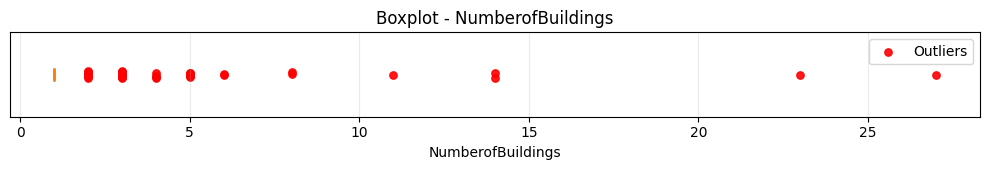

Outliers détectés : 70  |  Bornes IQR = [1, 1]

Top 10 des valeurs min :
- 1
- 1
- 1
- 1
- 1
- 1
- 1
- 1
- 1
- 1

Top 10 des valeurs max :
- 5
- 6
- 6
- 8
- 8
- 11
- 14
- 14
- 23
- 27

Nombre de valeurs NaN : 0


In [27]:
outliers_NumberofBuildings = analyse_colonne_numerique(df_troisieme_nettoyage, 'NumberofBuildings')

In [28]:
# df_troisieme_nettoyage[df_troisieme_nettoyage['NumberofBuildings'] == 111]

In [29]:
# df_troisieme_nettoyage[df_troisieme_nettoyage['NumberofBuildings'] == 0]

### Analyse colonne NumberofFloors

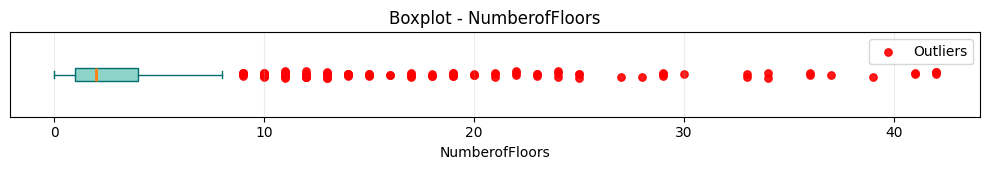

Outliers détectés : 120  |  Bornes IQR = [-3.5, 8.5]

Top 10 des valeurs min :
- 0
- 0
- 0
- 0
- 0
- 0
- 0
- 0
- 0
- 0

Top 10 des valeurs max :
- 34
- 36
- 36
- 37
- 39
- 41
- 41
- 42
- 42
- 42

Nombre de valeurs NaN : 0


In [30]:
outliers_NumberofFloors = analyse_colonne_numerique(df_troisieme_nettoyage, 'NumberofFloors')

### Analyse colonne PropertyGFATotal

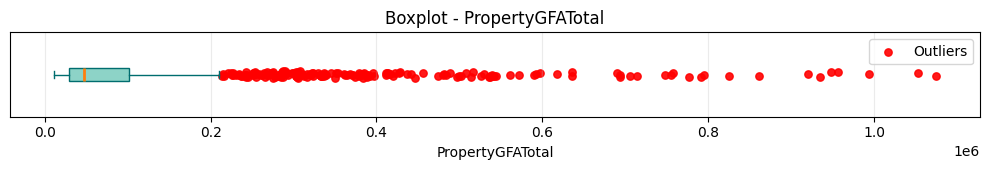

Outliers détectés : 181  |  Bornes IQR = [-7.96e+04, 2.1e+05]

Top 10 des valeurs min :
- 11285
- 11685
- 11968
- 12294
- 12769
- 13157
- 13661
- 14101
- 15398
- 16000

Top 10 des valeurs max :
- 794592
- 824887
- 861702
- 920598
- 934292
- 947987
- 956110
- 994212
- 1052469
- 1074552

Nombre de valeurs NaN : 0


In [31]:
# print(df_troisieme_nettoyage['PropertyGFATotal'].value_counts(dropna=False))
outliers_PropertyGFATotal = analyse_colonne_numerique(df_troisieme_nettoyage, 'PropertyGFATotal')

In [32]:
# outliers_PropertyGFATotal.sort_values(by='PropertyGFATotal', ascending=False).head()

### Analyse colonne PropertyGFAParking

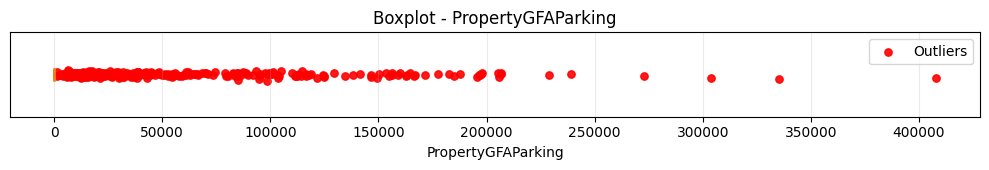

Outliers détectés : 314  |  Bornes IQR = [0, 0]

Top 10 des valeurs min :
- 0
- 0
- 0
- 0
- 0
- 0
- 0
- 0
- 0
- 0

Top 10 des valeurs max :
- 205076
- 205970
- 206580
- 206597
- 228668
- 239252
- 272900
- 303707
- 335109
- 407795

Nombre de valeurs NaN : 0


In [33]:
outliers_PropertyGFAParking = analyse_colonne_numerique(df_troisieme_nettoyage, 'PropertyGFAParking')

In [34]:
# 512600ft en m ça fait 155600m donc c'est 155000m² ? 

### Analyse colonne PropertyGFABuilding(s)

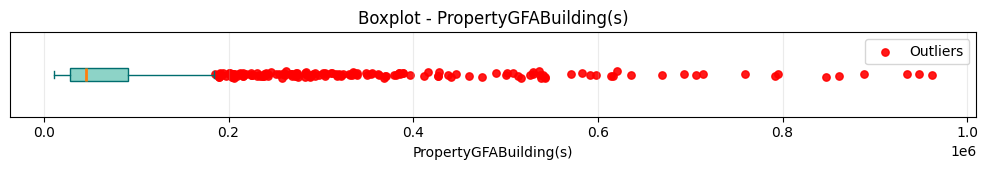

Outliers détectés : 165  |  Bornes IQR = [-6.64e+04, 1.85e+05]

Top 10 des valeurs min :
- 10925
- 11285
- 11440
- 11685
- 11968
- 12294
- 12769
- 12806
- 13157
- 13661

Top 10 des valeurs max :
- 714095
- 759392
- 791396
- 794592
- 847518
- 861702
- 888049
- 934292
- 947987
- 962428

Nombre de valeurs NaN : 0


In [35]:
outliers_PropertyGFABuilding = analyse_colonne_numerique(df_troisieme_nettoyage, 'PropertyGFABuilding(s)')

### Analyse colonne ListOfAllPropertyUseTypes

In [36]:
df_troisieme_nettoyage[df_troisieme_nettoyage['ListOfAllPropertyUseTypes'].isna() == True]

,OSEBuildingID,DataYear,BuildingType,PrimaryPropertyType,ZipCode,CouncilDistrictCode,Neighborhood,Latitude,Longitude,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),ListOfAllPropertyUseTypes,LargestPropertyUseType,LargestPropertyUseTypeGFA,SecondLargestPropertyUseType,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseType,ThirdLargestPropertyUseTypeGFA,YearsENERGYSTARCertified,ENERGYSTARScore,SiteEUI(kBtu/sf),SiteEUIWN(kBtu/sf),SourceEUI(kBtu/sf),SourceEUIWN(kBtu/sf),SiteEnergyUse(kBtu),SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),ComplianceStatus,TotalGHGEmissions,GHGEmissionsIntensity


### Analyse colonne LargestPropertyUseType

In [37]:
df_troisieme_nettoyage[df_troisieme_nettoyage['LargestPropertyUseType'].isna() == True]

,OSEBuildingID,DataYear,BuildingType,PrimaryPropertyType,ZipCode,CouncilDistrictCode,Neighborhood,Latitude,Longitude,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),ListOfAllPropertyUseTypes,LargestPropertyUseType,LargestPropertyUseTypeGFA,SecondLargestPropertyUseType,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseType,ThirdLargestPropertyUseTypeGFA,YearsENERGYSTARCertified,ENERGYSTARScore,SiteEUI(kBtu/sf),SiteEUIWN(kBtu/sf),SourceEUI(kBtu/sf),SourceEUIWN(kBtu/sf),SiteEnergyUse(kBtu),SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),ComplianceStatus,TotalGHGEmissions,GHGEmissionsIntensity


In [38]:
df_troisieme_nettoyage.loc[df_troisieme_nettoyage['OSEBuildingID'] == 496, 'LargestPropertyUseType'] = 'Other - Recreation'
df_troisieme_nettoyage.loc[df_troisieme_nettoyage['OSEBuildingID'] == 496]

,OSEBuildingID,DataYear,BuildingType,PrimaryPropertyType,ZipCode,CouncilDistrictCode,Neighborhood,Latitude,Longitude,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),ListOfAllPropertyUseTypes,LargestPropertyUseType,LargestPropertyUseTypeGFA,SecondLargestPropertyUseType,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseType,ThirdLargestPropertyUseTypeGFA,YearsENERGYSTARCertified,ENERGYSTARScore,SiteEUI(kBtu/sf),SiteEUIWN(kBtu/sf),SourceEUI(kBtu/sf),SourceEUIWN(kBtu/sf),SiteEnergyUse(kBtu),SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),ComplianceStatus,TotalGHGEmissions,GHGEmissionsIntensity


In [39]:
# id_cible = [21103, 25568, 25711]

# for id in id_cible:
#     df_troisieme_nettoyage.loc[df_troisieme_nettoyage['OSEBuildingID'] == id, "LargestPropertyUseType"] = (
#         df_troisieme_nettoyage.loc[df_troisieme_nettoyage['OSEBuildingID'] == id, "ListOfAllPropertyUseTypes"].values[0]
#     )

# for ids in id_cible:
#     display(df_troisieme_nettoyage[df_troisieme_nettoyage['OSEBuildingID'] == ids])


### Analyse colonne LargestPropertyUseTypeGFA

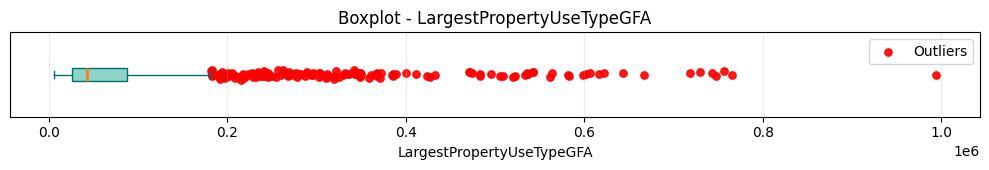

Outliers détectés : 157  |  Bornes IQR = [-6.83e+04, 1.81e+05]

Top 10 des valeurs min :
- 5656
- 6455
- 6601
- 6900
- 7245
- 7387
- 7501
- 7583
- 7758
- 8061

Top 10 des valeurs max :
- 622034
- 643083
- 667335
- 718473
- 729584
- 743562
- 748011
- 756493
- 765351
- 994212

Nombre de valeurs NaN : 0


In [40]:
outliers_LargestPropertyUseTypeGFA = analyse_colonne_numerique(df_troisieme_nettoyage, 'LargestPropertyUseTypeGFA')

In [41]:
df_troisieme_nettoyage[df_troisieme_nettoyage['LargestPropertyUseTypeGFA'].isna()]

,OSEBuildingID,DataYear,BuildingType,PrimaryPropertyType,ZipCode,CouncilDistrictCode,Neighborhood,Latitude,Longitude,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),ListOfAllPropertyUseTypes,LargestPropertyUseType,LargestPropertyUseTypeGFA,SecondLargestPropertyUseType,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseType,ThirdLargestPropertyUseTypeGFA,YearsENERGYSTARCertified,ENERGYSTARScore,SiteEUI(kBtu/sf),SiteEUIWN(kBtu/sf),SourceEUI(kBtu/sf),SourceEUIWN(kBtu/sf),SiteEnergyUse(kBtu),SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),ComplianceStatus,TotalGHGEmissions,GHGEmissionsIntensity


### Analyse colonne SecondLargestPropertyUseTypeGFA

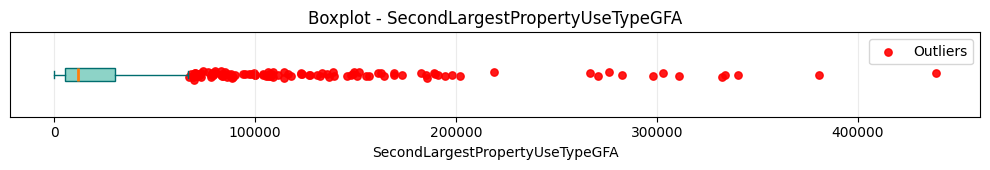

Outliers détectés : 114  |  Bornes IQR = [-3.12e+04, 6.69e+04]

Top 10 des valeurs min :
- 0.0
- 0.0
- 0.0
- 0.0
- 0.0
- 0.0
- 0.0
- 0.0
- 0.0
- 0.0

Top 10 des valeurs max :
- 276000.0
- 282392.0
- 298043.0
- 303000.0
- 310699.0
- 332343.0
- 333698.0
- 340236.0
- 380639.0
- 438756.0

Nombre de valeurs NaN : 759

Lignes contenant NaN :
      OSEBuildingID  DataYear        BuildingType PrimaryPropertyType  \
0                 1      2016      NonResidential               Hotel   
2                 3      2016      NonResidential               Hotel   
3                 5      2016      NonResidential               Hotel   
5                 9      2016  Nonresidential COS               Other   
6                10      2016      NonResidential               Hotel   
...             ...       ...                 ...                 ...   
1615          50212      2016  Nonresidential COS               Other   
1617          50220      2016  Nonresidential COS              Office   
1618 

In [42]:
outliers_SecondLargestPropertyUseTypeGFA = analyse_colonne_numerique(df_troisieme_nettoyage, 'SecondLargestPropertyUseTypeGFA')

In [43]:
df_troisieme_nettoyage[df_troisieme_nettoyage['SecondLargestPropertyUseTypeGFA'].isna()].shape

(759, 38)

In [44]:
df_SecondLargestPropertyUseTypeGFA_a_zero = df_troisieme_nettoyage[df_troisieme_nettoyage['SecondLargestPropertyUseTypeGFA'] == 0]
df_SecondLargestPropertyUseTypeGFA_a_zero.shape

(68, 38)

In [45]:
df_SecondLargestPropertyUseTypeGFA_a_zero[df_SecondLargestPropertyUseTypeGFA_a_zero["NumberofBuildings"] > 1]

,OSEBuildingID,DataYear,BuildingType,PrimaryPropertyType,ZipCode,CouncilDistrictCode,Neighborhood,Latitude,Longitude,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),ListOfAllPropertyUseTypes,LargestPropertyUseType,LargestPropertyUseTypeGFA,SecondLargestPropertyUseType,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseType,ThirdLargestPropertyUseTypeGFA,YearsENERGYSTARCertified,ENERGYSTARScore,SiteEUI(kBtu/sf),SiteEUIWN(kBtu/sf),SourceEUI(kBtu/sf),SourceEUIWN(kBtu/sf),SiteEnergyUse(kBtu),SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),ComplianceStatus,TotalGHGEmissions,GHGEmissionsIntensity


### Analyse colonne ThirdLargestPropertyUseTypeGFA

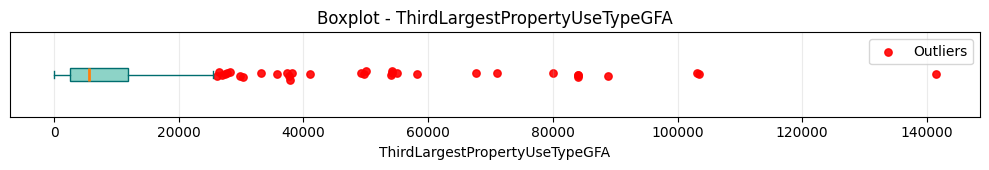

Outliers détectés : 33  |  Bornes IQR = [-1.13e+04, 2.58e+04]

Top 10 des valeurs min :
- 0.0
- 0.0
- 0.0
- 0.0
- 0.0
- 0.0
- 0.0
- 0.0
- 0.0
- 0.0

Top 10 des valeurs max :
- 67627.0
- 71000.0
- 80000.0
- 84000.0
- 84002.0
- 84051.89844
- 88901.0
- 103200.0
- 103478.0
- 141450.0

Nombre de valeurs NaN : 1235

Lignes contenant NaN :
      OSEBuildingID  DataYear        BuildingType PrimaryPropertyType  \
0                 1      2016      NonResidential               Hotel   
2                 3      2016      NonResidential               Hotel   
3                 5      2016      NonResidential               Hotel   
5                 9      2016  Nonresidential COS               Other   
6                10      2016      NonResidential               Hotel   
...             ...       ...                 ...                 ...   
1615          50212      2016  Nonresidential COS               Other   
1617          50220      2016  Nonresidential COS              Office   
1618    

In [46]:
outliers_ThirdLargestPropertyUseTypeGFA = analyse_colonne_numerique(df_troisieme_nettoyage, 'ThirdLargestPropertyUseTypeGFA')

In [47]:
df_troisieme_nettoyage[df_troisieme_nettoyage['ThirdLargestPropertyUseTypeGFA'].isna()].shape

(1235, 38)

In [48]:
df_troisieme_nettoyage[df_troisieme_nettoyage['ThirdLargestPropertyUseTypeGFA'] == 0].shape

(24, 38)

In [49]:
df_ThirdLargestPropertyUseTypeGFA_a_zero = df_troisieme_nettoyage[df_troisieme_nettoyage['ThirdLargestPropertyUseTypeGFA'] == 0]
df_ThirdLargestPropertyUseTypeGFA_a_zero.shape

(24, 38)

In [50]:
df_ThirdLargestPropertyUseTypeGFA_a_zero[df_ThirdLargestPropertyUseTypeGFA_a_zero["ThirdLargestPropertyUseTypeGFA"] > 1]

,OSEBuildingID,DataYear,BuildingType,PrimaryPropertyType,ZipCode,CouncilDistrictCode,Neighborhood,Latitude,Longitude,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),ListOfAllPropertyUseTypes,LargestPropertyUseType,LargestPropertyUseTypeGFA,SecondLargestPropertyUseType,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseType,ThirdLargestPropertyUseTypeGFA,YearsENERGYSTARCertified,ENERGYSTARScore,SiteEUI(kBtu/sf),SiteEUIWN(kBtu/sf),SourceEUI(kBtu/sf),SourceEUIWN(kBtu/sf),SiteEnergyUse(kBtu),SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),ComplianceStatus,TotalGHGEmissions,GHGEmissionsIntensity


### Analyse colonne ENERGYSTARScore

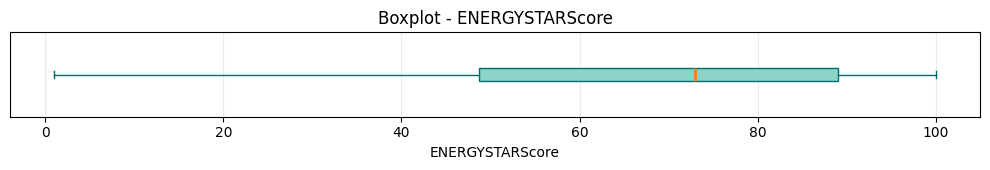

Outliers détectés : 0  |  Bornes IQR = [-11.6, 149]

Top 10 des valeurs min :
- 1.0
- 1.0
- 1.0
- 1.0
- 1.0
- 1.0
- 1.0
- 1.0
- 1.0
- 1.0

Top 10 des valeurs max :
- 100.0
- 100.0
- 100.0
- 100.0
- 100.0
- 100.0
- 100.0
- 100.0
- 100.0
- 100.0

Nombre de valeurs NaN : 538

Lignes contenant NaN :
      OSEBuildingID  DataYear        BuildingType PrimaryPropertyType  \
5                 9      2016  Nonresidential COS               Other   
7                11      2016      NonResidential               Other   
14               21      2016  Nonresidential COS               Other   
15               22      2016      NonResidential               Other   
17               24      2016      NonResidential  Mixed Use Property   
...             ...       ...                 ...                 ...   
1618          50221      2016  Nonresidential COS               Other   
1620          50223      2016  Nonresidential COS               Other   
1621          50224      2016  Nonresidential 

In [51]:
outliers_ENERGYSTARScore = analyse_colonne_numerique(df_troisieme_nettoyage, 'ENERGYSTARScore')

### Analyse colonne SiteEUI(kBtu/sf)

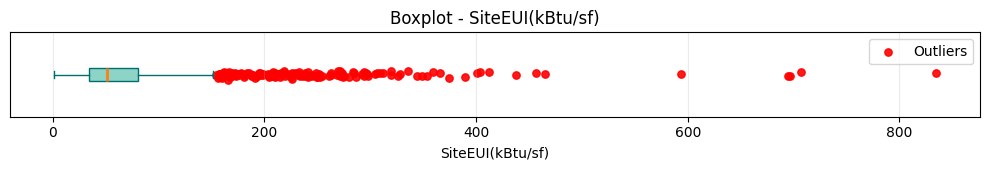

Outliers détectés : 149  |  Bornes IQR = [-36.5, 151]

Top 10 des valeurs min :
- 1.399999976
- 1.799999952
- 2.099999905
- 2.299999952
- 3.0
- 3.200000048
- 3.5
- 3.5
- 3.599999905
- 3.599999905

Top 10 des valeurs max :
- 404.1000061
- 412.7000122
- 438.2000122
- 456.6000061
- 465.5
- 593.5999756
- 694.7000122
- 696.7000122
- 707.2999878
- 834.4000244

Nombre de valeurs NaN : 0


In [52]:
outliers_SiteEUI = analyse_colonne_numerique(df_troisieme_nettoyage, 'SiteEUI(kBtu/sf)')

Site EUI signifie Site Energy Use Intensity = Intensité d’utilisation d’énergie du site.

SiteEUI =  Eˊnergie totale utiliseˊe sur site (en kBtu) / ​Surface brute totale (en pieds²)

kBtu = kilo British Thermal Units (1 kBtu ≈ 0,293 kWh)

sf = square feet (pieds carrés)

SiteEUI mesure combien d’énergie est utilisée par pied carré sur le site total, peu importe l’origine de l’énergie.

### Analyse colonne SiteEUIWN(kBtu/sf)

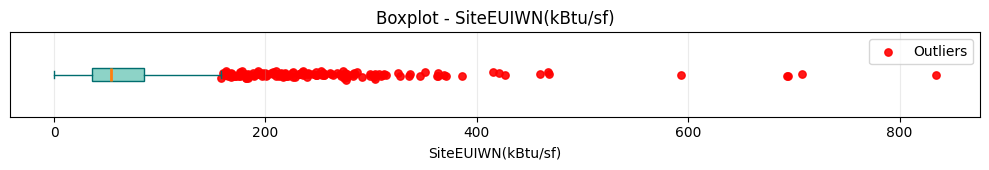

Outliers détectés : 145  |  Bornes IQR = [-37.2, 158]

Top 10 des valeurs min :
- 0.0
- 0.0
- 0.0
- 0.0
- 0.0
- 0.0
- 0.0
- 0.0
- 1.5
- 1.799999952

Top 10 des valeurs max :
- 420.6000061
- 426.6000061
- 460.1000061
- 467.0
- 468.7000122
- 593.5999756
- 693.0999756
- 694.7000122
- 707.2999878
- 834.4000244

Nombre de valeurs NaN : 1

Lignes contenant NaN :
     OSEBuildingID  DataYear    BuildingType PrimaryPropertyType  ZipCode  \
548            757      2016  NonResidential        Large Office    98121   

     CouncilDistrictCode Neighborhood  Latitude  Longitude  YearBuilt  \
548                    7     DOWNTOWN  47.61051 -122.34439       1979   

     NumberofBuildings  NumberofFloors  PropertyGFATotal  PropertyGFAParking  \
548                  1               7            131143               87160   

     PropertyGFABuilding(s) ListOfAllPropertyUseTypes LargestPropertyUseType  \
548                   43983      Office, Retail Store                 Office   

     LargestPrope

In [53]:
outliers_SiteEUIWN = analyse_colonne_numerique(df_troisieme_nettoyage, 'SiteEUIWN(kBtu/sf)')

Site EUI Weather Normalized = Intensité énergétique du site corrigée en fonction du climat.

Parce que la météo influence la consommation :

Hiver rigoureux = plus de chauffage

Été chaud = plus de climatisation

Donc SiteEUIWN modélise la consommation d’énergie comme si la météo avait été "normale", pour comparer les bâtiments plus équitablement.

### Analyse colonne SourceEUI(kBtu/sf)

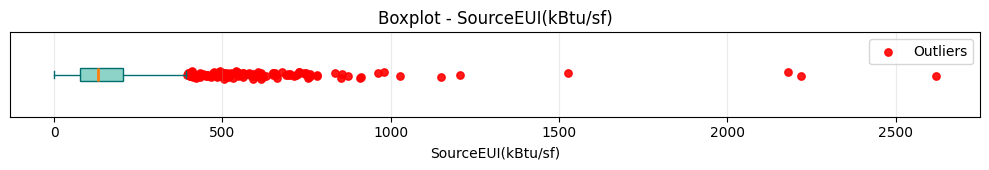

Outliers détectés : 132  |  Bornes IQR = [-112, 393]

Top 10 des valeurs min :
- 0.0
- 0.0
- 4.5
- 5.800000191
- 6.400000095
- 6.599999905
- 6.599999905
- 6.900000095
- 9.0
- 9.5

Top 10 des valeurs max :
- 912.7999878
- 962.0999756
- 978.9000244
- 1026.599976
- 1150.300049
- 1206.699951
- 1527.300049
- 2181.300049
- 2217.800049
- 2620.0

Nombre de valeurs NaN : 0


In [54]:
outliers_SourceEUI = analyse_colonne_numerique(df_troisieme_nettoyage, 'SourceEUI(kBtu/sf)')

Source Energy Use Intensity = Intensité d’utilisation de l’énergie à la source

SourceEUI (ce que tu ne vois pas) = Énergie nécessaire à la source pour fournir de l'énergie au site

Tu consommes 100 kWh d’électricité dans ton bâtiment.
Mais il faut ~300 kWh à la centrale pour produire et transporter cette électricité (pertes, rendement...).

- SiteEUI → 100 kWh
- SourceEUI → 300 kWh (car ça reflète ce que l'environnement a dû fournir)

SourceEUI est donc toujours supérieur ou égal à SiteEUI.

In [55]:
for i, row in df_troisieme_nettoyage.iterrows():
    site_eui = row['SiteEUI(kBtu/sf)']
    source_eui = row['SourceEUI(kBtu/sf)']

    if pd.notna(site_eui) and pd.notna(source_eui):
        if site_eui > source_eui:
            print(f"Ligne {i} : SiteEUI ({site_eui}) > SourceEUI ({source_eui})")

Ligne 437 : SiteEUI (58.0) > SourceEUI (28.0)
Ligne 498 : SiteEUI (208.8000031) > SourceEUI (0.0)
Ligne 1427 : SiteEUI (39.79999924) > SourceEUI (16.39999962)
Ligne 1436 : SiteEUI (89.19999695) > SourceEUI (0.0)


In [56]:
df_troisieme_nettoyage[df_troisieme_nettoyage['SourceEUI(kBtu/sf)'] == 28.0]

,OSEBuildingID,DataYear,BuildingType,PrimaryPropertyType,ZipCode,CouncilDistrictCode,Neighborhood,Latitude,Longitude,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),ListOfAllPropertyUseTypes,LargestPropertyUseType,LargestPropertyUseTypeGFA,SecondLargestPropertyUseType,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseType,ThirdLargestPropertyUseTypeGFA,YearsENERGYSTARCertified,ENERGYSTARScore,SiteEUI(kBtu/sf),SiteEUIWN(kBtu/sf),SourceEUI(kBtu/sf),SourceEUIWN(kBtu/sf),SiteEnergyUse(kBtu),SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),ComplianceStatus,TotalGHGEmissions,GHGEmissionsIntensity
437,608,2016,NonResidential,Large Office,98104,2,DOWNTOWN,47.59878,-122.33458,1913,5,7,154159,0,154159,Office,Office,193154,NaN,NaN,NaN,NaN,NaN,100.0,58.0,58.799999,28.0,28.700001,11195917.0,11348758.0,0.0,471503.0,1608768.0,3430.500488,343050.0,Non-Compliant,29.43,0.19


In [57]:
df_troisieme_nettoyage[df_troisieme_nettoyage['OSEBuildingID'] == 700]

,OSEBuildingID,DataYear,BuildingType,PrimaryPropertyType,ZipCode,CouncilDistrictCode,Neighborhood,Latitude,Longitude,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),ListOfAllPropertyUseTypes,LargestPropertyUseType,LargestPropertyUseTypeGFA,SecondLargestPropertyUseType,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseType,ThirdLargestPropertyUseTypeGFA,YearsENERGYSTARCertified,ENERGYSTARScore,SiteEUI(kBtu/sf),SiteEUIWN(kBtu/sf),SourceEUI(kBtu/sf),SourceEUIWN(kBtu/sf),SiteEnergyUse(kBtu),SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),ComplianceStatus,TotalGHGEmissions,GHGEmissionsIntensity
498,700,2016,NonResidential,Supermarket / Grocery Store,98119,7,MAGNOLIA / QUEEN ANNE,47.63718,-122.37734,2008,1,1,57176,0,57176,"Personal Services (Health/Beauty, Dry Cleaning...",Supermarket/Grocery Store,39500,Retail Store,15000.0,"Personal Services (Health/Beauty, Dry Cleaning...",5500.0,NaN,31.0,208.800003,214.100006,0.0,0.0,12525174.0,12843856.0,0.0,0.0,0.0,0.0,0.0,Compliant,0.0,0.0


In [58]:
# df_troisieme_nettoyage.iloc[[1436]]
df_troisieme_nettoyage[df_troisieme_nettoyage['OSEBuildingID'] == 26973]

,OSEBuildingID,DataYear,BuildingType,PrimaryPropertyType,ZipCode,CouncilDistrictCode,Neighborhood,Latitude,Longitude,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),ListOfAllPropertyUseTypes,LargestPropertyUseType,LargestPropertyUseTypeGFA,SecondLargestPropertyUseType,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseType,ThirdLargestPropertyUseTypeGFA,YearsENERGYSTARCertified,ENERGYSTARScore,SiteEUI(kBtu/sf),SiteEUIWN(kBtu/sf),SourceEUI(kBtu/sf),SourceEUIWN(kBtu/sf),SiteEnergyUse(kBtu),SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),ComplianceStatus,TotalGHGEmissions,GHGEmissionsIntensity
1436,26973,2016,NonResidential,Mixed Use Property,98104,2,DOWNTOWN,47.59737,-122.32487,1909,1,3,49299,0,49299,"Multifamily Housing, Office, Restaurant",Office,24099,Multifamily Housing,23632.0,Restaurant,5320.0,NaN,NaN,89.199997,90.900002,0.0,0.0,4729846.5,4821852.0,0.0,387981.3125,1323792.0,0.0,0.0,Compliant,9.23,0.19


In [59]:
df_troisieme_nettoyage[df_troisieme_nettoyage['SourceEUI(kBtu/sf)'] == 16.39999962]

,OSEBuildingID,DataYear,BuildingType,PrimaryPropertyType,ZipCode,CouncilDistrictCode,Neighborhood,Latitude,Longitude,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),ListOfAllPropertyUseTypes,LargestPropertyUseType,LargestPropertyUseTypeGFA,SecondLargestPropertyUseType,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseType,ThirdLargestPropertyUseTypeGFA,YearsENERGYSTARCertified,ENERGYSTARScore,SiteEUI(kBtu/sf),SiteEUIWN(kBtu/sf),SourceEUI(kBtu/sf),SourceEUIWN(kBtu/sf),SiteEnergyUse(kBtu),SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),ComplianceStatus,TotalGHGEmissions,GHGEmissionsIntensity
1427,26849,2016,NonResidential,Retail Store,98104,2,DOWNTOWN,47.59935,-122.32468,1917,1,2,24550,0,24550,"Office, Retail Store",Retail Store,13500,Office,11050.0,NaN,NaN,NaN,100.0,39.799999,42.0,16.4,17.700001,977230.3125,1.031448e+06,0.0,26436.40039,90201.0,1147.940186,114794.0,Compliant,6.73,0.27
1440,27007,2016,NonResidential,Worship Facility,98105,4,NORTHEAST,47.66146,-122.27880,1954,1,2,20039,0,20039,Worship Facility,Worship Facility,20039,NaN,NaN,NaN,NaN,NaN,100.0,5.200000,5.2,16.4,16.400000,104722.2969,1.047223e+05,0.0,30692.30078,104722.0,0.000000,0.0,Non-Compliant,0.73,0.04


In [60]:
df_troisieme_nettoyage[df_troisieme_nettoyage['OSEBuildingID'] == 26994]

,OSEBuildingID,DataYear,BuildingType,PrimaryPropertyType,ZipCode,CouncilDistrictCode,Neighborhood,Latitude,Longitude,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),ListOfAllPropertyUseTypes,LargestPropertyUseType,LargestPropertyUseTypeGFA,SecondLargestPropertyUseType,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseType,ThirdLargestPropertyUseTypeGFA,YearsENERGYSTARCertified,ENERGYSTARScore,SiteEUI(kBtu/sf),SiteEUIWN(kBtu/sf),SourceEUI(kBtu/sf),SourceEUIWN(kBtu/sf),SiteEnergyUse(kBtu),SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),ComplianceStatus,TotalGHGEmissions,GHGEmissionsIntensity
1438,26994,2016,NonResidential,Mixed Use Property,98122,3,EAST,47.627,-122.29153,1988,1,2,21036,0,21036,"Fitness Center/Health Club/Gym, Medical Office...",Parking,11021,Fitness Center/Health Club/Gym,8164.0,Office,7280.0,NaN,NaN,130.100006,134.600006,280.700012,285.399994,2735811.5,2830649.5,0.0,425240.4063,1450920.0,12848.91016,1284891.0,Compliant,78.36,3.73


In [61]:
# Remplacement des 0 par des NaN pour ne pas fausser les calculs si j'utilise les colonnes enquestion 

ids_cibles = [1436, 26973]

df_troisieme_nettoyage.loc[(df_troisieme_nettoyage['OSEBuildingID'].isin(ids_cibles)) & (df_troisieme_nettoyage['SourceEUI(kBtu/sf)'] == 0),
                            'SourceEUI(kBtu/sf)'] = np.nan
df_troisieme_nettoyage.loc[(df_troisieme_nettoyage['OSEBuildingID'].isin(ids_cibles)) & (df_troisieme_nettoyage['SourceEUIWN(kBtu/sf)'] == 0), 
                           'SourceEUIWN(kBtu/sf)'] = np.nan

### Analyse colonne SourceEUIWN(kBtu/sf)

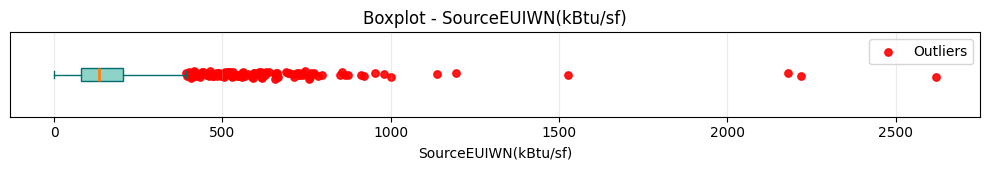

Outliers détectés : 133  |  Bornes IQR = [-107, 392]

Top 10 des valeurs min :
- 0.0
- 0.0
- 0.0
- 0.0
- 0.0
- 0.0
- 0.0
- 0.0
- 0.0
- 0.0

Top 10 des valeurs max :
- 919.2999878
- 954.0
- 978.9000244
- 1001.0
- 1138.400024
- 1195.099976
- 1527.300049
- 2181.300049
- 2217.800049
- 2620.0

Nombre de valeurs NaN : 1

Lignes contenant NaN :
      OSEBuildingID  DataYear    BuildingType PrimaryPropertyType  ZipCode  \
1436          26973      2016  NonResidential  Mixed Use Property    98104   

      CouncilDistrictCode Neighborhood  Latitude  Longitude  YearBuilt  \
1436                    2     DOWNTOWN  47.59737 -122.32487       1909   

      NumberofBuildings  NumberofFloors  PropertyGFATotal  PropertyGFAParking  \
1436                  1               3             49299                   0   

      PropertyGFABuilding(s)                ListOfAllPropertyUseTypes  \
1436                   49299  Multifamily Housing, Office, Restaurant   

     LargestPropertyUseType  LargestProperty

In [62]:
outliers_SourceEUIWN = analyse_colonne_numerique(df_troisieme_nettoyage, 'SourceEUIWN(kBtu/sf)')

Même idée que pour SiteEUIWN : C’est une version corrigée selon les conditions climatiques normales.

Comme la météo varie, comparer deux bâtiments avec SourceEUIWN permet d’être plus juste

SourceEUIWN pour comparer objectivement des bâtiments

### Analyse colonne SiteEnergyUse(kBtu)

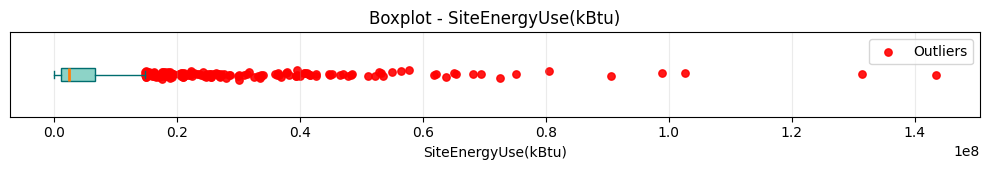

Outliers détectés : 168  |  Bornes IQR = [-6.92e+06, 1.48e+07]

Top 10 des valeurs min :
- 57133.19922
- 72370.39844
- 79711.79688
- 90558.70313
- 97690.39844
- 100841.7031
- 104722.2969
- 106918.0
- 111969.7031
- 113130.0

Top 10 des valeurs max :
- 68090728.0
- 69519808.0
- 72587024.0
- 75073888.0
- 80469216.0
- 90609640.0
- 98960776.0
- 102673696.0
- 131373880.0
- 143423024.0

Nombre de valeurs NaN : 0


In [63]:
outliers_SiteEnergyUse = analyse_colonne_numerique(df_troisieme_nettoyage, 'SiteEnergyUse(kBtu)')

C’est la quantité totale d’énergie utilisée sur le site (bâtiment, campus, etc.), exprimée en kBtu (kilo British Thermal Units)

- C’est l’énergie réellement consommée par le site (électricité, gaz, fuel, etc.)

- Elle est mesurée (ou estimée) à partir des compteurs réels ou des factures

In [64]:
# df_troisieme_nettoyage[df_troisieme_nettoyage['SiteEnergyUse(kBtu)'] == 448385312.0]
# df_troisieme_nettoyage[df_troisieme_nettoyage['SiteEnergyUse(kBtu)'] == 16808.90039]
# df_troisieme_nettoyage[df_troisieme_nettoyage['SiteEnergyUse(kBtu)'] == 24105.5]
# df_troisieme_nettoyage[df_troisieme_nettoyage['SiteEnergyUse(kBtu)'] == 44293.5]
# df_troisieme_nettoyage[df_troisieme_nettoyage['SiteEnergyUse(kBtu)'] == 57133.19922]
# Faire une méthode scientifique pour retirer les outliers, zscore etc... 

In [65]:
df_troisieme_nettoyage[df_troisieme_nettoyage['SiteEnergyUse(kBtu)'] == 0]

,OSEBuildingID,DataYear,BuildingType,PrimaryPropertyType,ZipCode,CouncilDistrictCode,Neighborhood,Latitude,Longitude,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),ListOfAllPropertyUseTypes,LargestPropertyUseType,LargestPropertyUseTypeGFA,SecondLargestPropertyUseType,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseType,ThirdLargestPropertyUseTypeGFA,YearsENERGYSTARCertified,ENERGYSTARScore,SiteEUI(kBtu/sf),SiteEUIWN(kBtu/sf),SourceEUI(kBtu/sf),SourceEUIWN(kBtu/sf),SiteEnergyUse(kBtu),SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),ComplianceStatus,TotalGHGEmissions,GHGEmissionsIntensity


### Analyse colonne SiteEnergyUseWN(kBtu)

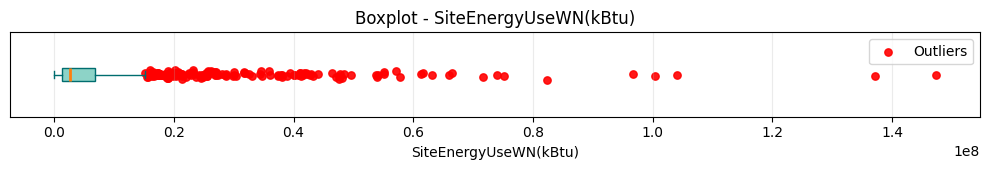

Outliers détectés : 163  |  Bornes IQR = [-7.05e+06, 1.52e+07]

Top 10 des valeurs min :
- 0.0
- 0.0
- 0.0
- 0.0
- 0.0
- 0.0
- 0.0
- 0.0
- 58114.19922
- 72370.39844

Top 10 des valeurs max :
- 66502836.0
- 71568952.0
- 73937112.0
- 75073888.0
- 82318072.0
- 96775464.0
- 100328264.0
- 103985264.0
- 137106112.0
- 147299056.0

Nombre de valeurs NaN : 1

Lignes contenant NaN :
     OSEBuildingID  DataYear    BuildingType PrimaryPropertyType  ZipCode  \
548            757      2016  NonResidential        Large Office    98121   

     CouncilDistrictCode Neighborhood  Latitude  Longitude  YearBuilt  \
548                    7     DOWNTOWN  47.61051 -122.34439       1979   

     NumberofBuildings  NumberofFloors  PropertyGFATotal  PropertyGFAParking  \
548                  1               7            131143               87160   

     PropertyGFABuilding(s) ListOfAllPropertyUseTypes LargestPropertyUseType  \
548                   43983      Office, Retail Store                 Office   



In [66]:
outliers_SiteEnergyUseWN = analyse_colonne_numerique(df_troisieme_nettoyage, 'SiteEnergyUseWN(kBtu)')

Version normalisée selon la météo (Weather Normalized)

Parce que la consommation énergétique dépend énormément de la météo :

- hiver froid → plus de chauffage

- été chaud → plus de clim

Donc SiteEnergyUseWN modélise combien ton bâtiment aurait consommé dans des conditions météo typiques

### Analyse colonne SteamUse(kBtu)

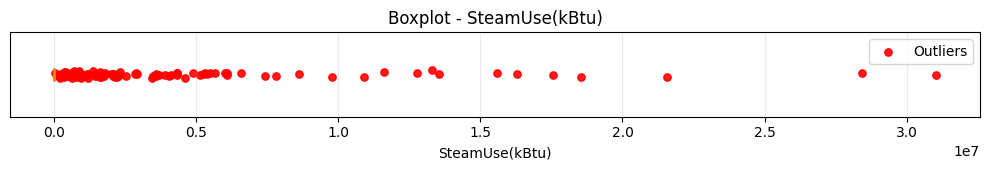

Outliers détectés : 105  |  Bornes IQR = [0, 0]

Top 10 des valeurs min :
- 0.0
- 0.0
- 0.0
- 0.0
- 0.0
- 0.0
- 0.0
- 0.0
- 0.0
- 0.0

Top 10 des valeurs max :
- 12760971.0
- 13296249.0
- 13556219.0
- 15586014.0
- 16284570.0
- 17548416.0
- 18547858.0
- 21566554.0
- 28438884.0
- 31030194.0

Nombre de valeurs NaN : 0


In [67]:
outliers_SteamUse = analyse_colonne_numerique(df_troisieme_nettoyage, 'SteamUse(kBtu)')

Définition : Quantité de vapeur utilisée par le bâtiment, mesurée en kBtu

Source typique : réseaux de vapeur urbains ou chaudières collectives

Utilisation : chauffage, eau chaude sanitaire, parfois production industrielle

Inclus dans SiteEnergyUse normalement

Remarques analytiques :

- Très forte consommation dans les bâtiments anciens ou gros campus

- Peut être totalement absente dans des bâtiments individuels récents

In [68]:
df_troisieme_nettoyage[df_troisieme_nettoyage['SteamUse(kBtu)'] == 122575032.0]

,OSEBuildingID,DataYear,BuildingType,PrimaryPropertyType,ZipCode,CouncilDistrictCode,Neighborhood,Latitude,Longitude,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),ListOfAllPropertyUseTypes,LargestPropertyUseType,LargestPropertyUseTypeGFA,SecondLargestPropertyUseType,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseType,ThirdLargestPropertyUseTypeGFA,YearsENERGYSTARCertified,ENERGYSTARScore,SiteEUI(kBtu/sf),SiteEUIWN(kBtu/sf),SourceEUI(kBtu/sf),SourceEUIWN(kBtu/sf),SiteEnergyUse(kBtu),SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),ComplianceStatus,TotalGHGEmissions,GHGEmissionsIntensity


In [69]:
df_troisieme_nettoyage[df_troisieme_nettoyage['SteamUse(kBtu)'] == 134943456.0]

,OSEBuildingID,DataYear,BuildingType,PrimaryPropertyType,ZipCode,CouncilDistrictCode,Neighborhood,Latitude,Longitude,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),ListOfAllPropertyUseTypes,LargestPropertyUseType,LargestPropertyUseTypeGFA,SecondLargestPropertyUseType,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseType,ThirdLargestPropertyUseTypeGFA,YearsENERGYSTARCertified,ENERGYSTARScore,SiteEUI(kBtu/sf),SiteEUIWN(kBtu/sf),SourceEUI(kBtu/sf),SourceEUIWN(kBtu/sf),SiteEnergyUse(kBtu),SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),ComplianceStatus,TotalGHGEmissions,GHGEmissionsIntensity


### Analyse colonne Electricity(kWh)

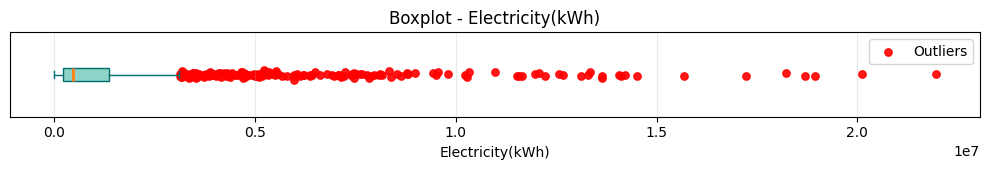

Outliers détectés : 176  |  Bornes IQR = [-1.53e+06, 3.12e+06]

Top 10 des valeurs min :
- 0.0
- 0.0
- 1.0
- 1798.900024
- 4913.5
- 14362.5
- 16744.80078
- 18890.0
- 19771.90039
- 21051.30078

Top 10 des valeurs max :
- 14113435.0
- 14208670.0
- 14515435.0
- 15681864.0
- 17220084.0
- 18228948.0
- 18705198.0
- 18941222.0
- 20116302.0
- 21957020.0

Nombre de valeurs NaN : 0


In [70]:
outliers_Electricity = analyse_colonne_numerique(df_troisieme_nettoyage, 'Electricity(kWh)')

Définition : Électricité consommée, en kilowattheures

Unité brute d’électricité

1 kWh ≈ 3.412 kBtu (convertible)

In [71]:
df_troisieme_nettoyage[df_troisieme_nettoyage['Electricity(kWh)'] == 80460872.0]
# Data Center, Office

,OSEBuildingID,DataYear,BuildingType,PrimaryPropertyType,ZipCode,CouncilDistrictCode,Neighborhood,Latitude,Longitude,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),ListOfAllPropertyUseTypes,LargestPropertyUseType,LargestPropertyUseTypeGFA,SecondLargestPropertyUseType,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseType,ThirdLargestPropertyUseTypeGFA,YearsENERGYSTARCertified,ENERGYSTARScore,SiteEUI(kBtu/sf),SiteEUIWN(kBtu/sf),SourceEUI(kBtu/sf),SourceEUIWN(kBtu/sf),SiteEnergyUse(kBtu),SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),ComplianceStatus,TotalGHGEmissions,GHGEmissionsIntensity


### Analyse colonne Electricity(kBtu)

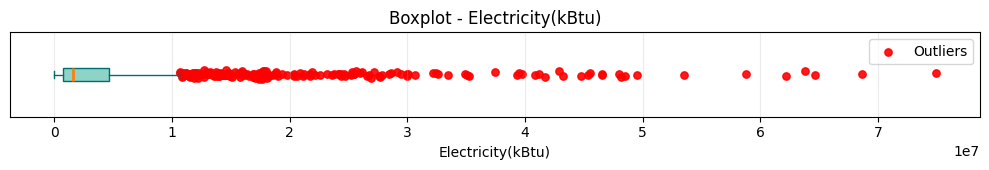

Outliers détectés : 176  |  Bornes IQR = [-5.24e+06, 1.07e+07]

Top 10 des valeurs min :
- 0.0
- 0.0
- 3.0
- 6138.0
- 16765.0
- 49005.0
- 57133.0
- 64453.0
- 67462.0
- 71827.0

Top 10 des valeurs max :
- 48155040.0
- 48479982.0
- 49526664.0
- 53506520.0
- 58754927.0
- 62197171.0
- 63822136.0
- 64627449.0
- 68636822.0
- 74917352.0

Nombre de valeurs NaN : 0


In [72]:
outliers_ElectricityB = analyse_colonne_numerique(df_troisieme_nettoyage, 'Electricity(kBtu)')

Version convertie de la colonne Electricity(kWh)

Electricity(kBtu)=Electricity(kWh)×3.412

C’est ce qui est utilisé dans SiteEnergyUse pour avoir toutes les énergies dans la même unité (kBtu)

In [73]:
# df_troisieme_nettoyage[df_troisieme_nettoyage['Electricity(kBtu)'] == -115417.0]

### Analyse colonne NaturalGas(therms)

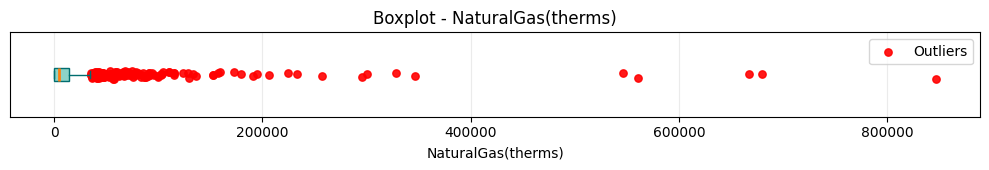

Outliers détectés : 178  |  Bornes IQR = [-2.11e+04, 3.51e+04]

Top 10 des valeurs min :
- 0.0
- 0.0
- 0.0
- 0.0
- 0.0
- 0.0
- 0.0
- 0.0
- 0.0
- 0.0

Top 10 des valeurs max :
- 256831.625
- 296021.5
- 300613.25
- 328535.125
- 346853.3125
- 546713.9375
- 560966.125
- 667464.25
- 679905.375
- 846680.9375

Nombre de valeurs NaN : 0


In [74]:
outliers_NaturalGas = analyse_colonne_numerique(df_troisieme_nettoyage, 'NaturalGas(therms)')

Gaz naturel consommé, en therms

1 therm = environ 100 kBtu



In [75]:
df_troisieme_nettoyage[df_troisieme_nettoyage['NaturalGas(therms)'] == 2979090.0]
# Campus, Energy/Power Station, Laboratory, Manufacturin

,OSEBuildingID,DataYear,BuildingType,PrimaryPropertyType,ZipCode,CouncilDistrictCode,Neighborhood,Latitude,Longitude,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),ListOfAllPropertyUseTypes,LargestPropertyUseType,LargestPropertyUseTypeGFA,SecondLargestPropertyUseType,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseType,ThirdLargestPropertyUseTypeGFA,YearsENERGYSTARCertified,ENERGYSTARScore,SiteEUI(kBtu/sf),SiteEUIWN(kBtu/sf),SourceEUI(kBtu/sf),SourceEUIWN(kBtu/sf),SiteEnergyUse(kBtu),SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),ComplianceStatus,TotalGHGEmissions,GHGEmissionsIntensity


### Analyse colonne NaturalGas(kBtu)

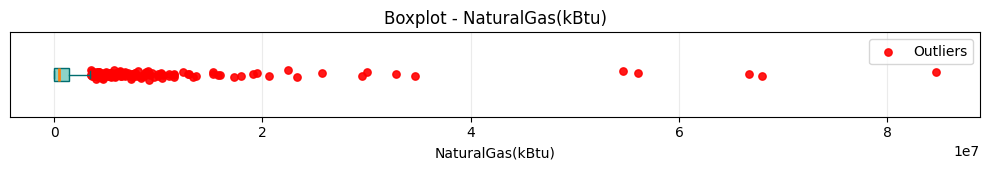

Outliers détectés : 178  |  Bornes IQR = [-2.11e+06, 3.51e+06]

Top 10 des valeurs min :
- 0.0
- 0.0
- 0.0
- 0.0
- 0.0
- 0.0
- 0.0
- 0.0
- 0.0
- 0.0

Top 10 des valeurs max :
- 25683162.0
- 29602150.0
- 30061325.0
- 32853512.0
- 34685331.0
- 54671394.0
- 56096612.0
- 66746425.0
- 67990538.0
- 84668094.0

Nombre de valeurs NaN : 0


In [76]:
outliers_NaturalGas = analyse_colonne_numerique(df_troisieme_nettoyage, 'NaturalGas(kBtu)')

Énergie issue du gaz, convertie en kBtu


### Analyse colonne TotalGHGEmissions

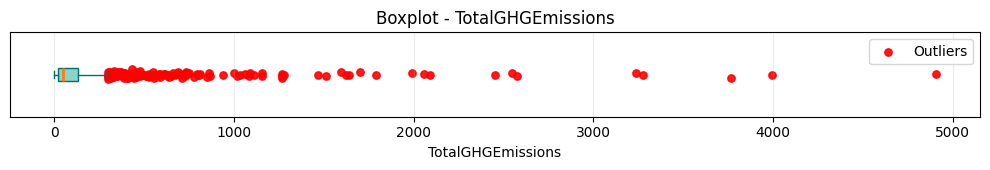

Outliers détectés : 168  |  Bornes IQR = [-146, 296]

Top 10 des valeurs min :
- 0.0
- 0.4
- 0.5
- 0.63
- 0.68
- 0.7
- 0.73
- 0.75
- 0.79
- 0.81

Top 10 des valeurs max :
- 2055.82
- 2089.28
- 2451.58
- 2549.47
- 2573.75
- 3238.24
- 3278.11
- 3768.66
- 3995.45
- 4906.33

Nombre de valeurs NaN : 0


In [77]:
outliers_TotalGHGEmissions = analyse_colonne_numerique(df_troisieme_nettoyage, 'TotalGHGEmissions')

Définition : Total des émissions de gaz à effet de serre du bâtiment, en général exprimé en kg ou tonnes équivalent CO₂

Inclut :

- émissions directes (ex : gaz brûlé sur site)

- émissions indirectes (ex : production d’électricité à distance)

Influencé par le mix énergétique :

- un kWh nucléaire ≠ un kWh charbon en émission

In [78]:
df_troisieme_nettoyage[df_troisieme_nettoyage['TotalGHGEmissions'] == -0.8]

,OSEBuildingID,DataYear,BuildingType,PrimaryPropertyType,ZipCode,CouncilDistrictCode,Neighborhood,Latitude,Longitude,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),ListOfAllPropertyUseTypes,LargestPropertyUseType,LargestPropertyUseTypeGFA,SecondLargestPropertyUseType,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseType,ThirdLargestPropertyUseTypeGFA,YearsENERGYSTARCertified,ENERGYSTARScore,SiteEUI(kBtu/sf),SiteEUIWN(kBtu/sf),SourceEUI(kBtu/sf),SourceEUIWN(kBtu/sf),SiteEnergyUse(kBtu),SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),ComplianceStatus,TotalGHGEmissions,GHGEmissionsIntensity


### Analyse colonne GHGEmissionsIntensity

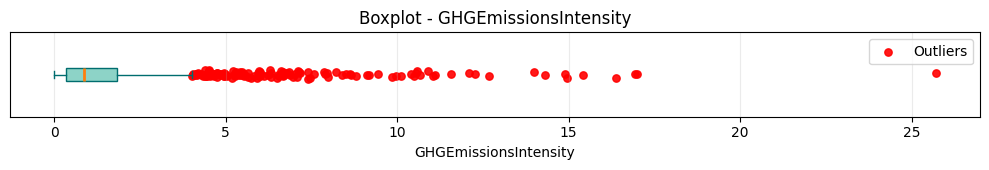

Outliers détectés : 134  |  Bornes IQR = [-1.84, 4.03]

Top 10 des valeurs min :
- 0.0
- 0.01
- 0.01
- 0.01
- 0.02
- 0.02
- 0.02
- 0.02
- 0.03
- 0.03

Top 10 des valeurs max :
- 12.69
- 13.98
- 14.32
- 14.89
- 14.94
- 15.42
- 16.38
- 16.93
- 16.99
- 25.71

Nombre de valeurs NaN : 0


In [79]:
outliers_GHGEmissionsIntensity = analyse_colonne_numerique(df_troisieme_nettoyage, 'GHGEmissionsIntensity')

Définition : Intensité des émissions GES par unité de surface

En général :

GHG Intensity = TotalGHGEmissions / Surface (ft²)

Unité : souvent kgCO₂e / ft²

Permet de comparer les bâtiments de tailles différentes

- Comme un EUI pour les émissions.

### Analyse d'autres données

In [80]:
# # De 0 à 99, c'est ok
# df_troisieme_nettoyage['NumberofFloors'].value_counts(dropna=False)

In [81]:
# # De 1900 à 2015, c'est ok
# df_troisieme_nettoyage['YearBuilt'].value_counts(dropna=False).sort_index().index.tolist()

In [82]:
building_consumption['PropertyGFATotal'].value_counts(dropna=False)

PropertyGFATotal
36000     9
25920     8
28800     7
21600     7
24000     6
         ..
56228     1
88592     1
126593    1
67224     1
59653     1
Name: count, Length: 3195, dtype: int64

### Nouveau control des données

In [83]:
df_troisieme_nettoyage.describe()

,OSEBuildingID,DataYear,ZipCode,CouncilDistrictCode,Latitude,Longitude,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),LargestPropertyUseTypeGFA,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseTypeGFA,ENERGYSTARScore,SiteEUI(kBtu/sf),SiteEUIWN(kBtu/sf),SourceEUI(kBtu/sf),SourceEUIWN(kBtu/sf),SiteEnergyUse(kBtu),SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),TotalGHGEmissions,GHGEmissionsIntensity
count,1570.000000,1570.0,1554.0,1570.000000,1570.000000,1570.000000,1570.000000,1570.0,1570.000000,1.570000e+03,1570.000000,1570.000000,1570.0,811.000000,335.000000,1032.000000,1570.000000,1569.000000,1569.000000,1569.000000,1.570000e+03,1.569000e+03,1.570000e+03,1.570000e+03,1.570000e+03,1570.000000,1.570000e+03,1570.000000,1570.000000
mean,16295.307643,2016.0,98116.611969,4.352229,47.615274,-122.333232,1961.499363,1.144586,3.773885,9.872937e+04,11651.101911,87078.266879,80351.761146,31283.967074,11206.765369,65.477713,72.158917,74.671574,176.599426,178.941938,6.513307e+06,6.624087e+06,2.729161e+05,1.343439e+06,4.583813e+06,16070.523718,1.607052e+06,138.371994,1.562975
std,13656.770607,0.0,18.006456,2.207845,0.048273,0.024562,32.714327,1.130204,4.938289,1.336773e+05,36165.393612,116152.805218,106293.450352,52192.171423,17694.857225,28.291531,73.267018,74.187044,183.177654,183.049988,1.156080e+07,1.165767e+07,1.786409e+06,2.376499e+06,8.108613e+06,47220.391474,4.722039e+06,318.693770,2.150406
min,1.000000,2016.0,98006.0,1.000000,47.499170,-122.411820,1900.000000,1.0,0.000000,1.128500e+04,0.000000,10925.000000,5656.0,0.000000,0.000000,1.000000,1.400000,0.000000,0.000000,0.000000,5.713320e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000
25%,589.250000,2016.0,98105.0,2.000000,47.584110,-122.343482,1930.000000,1.0,1.000000,2.901975e+04,0.000000,28087.250000,25215.5,5567.500000,2583.500000,48.750000,34.000000,36.000000,77.199997,80.199997,1.242400e+06,1.300766e+06,0.000000e+00,2.114083e+05,7.213255e+05,0.000000,0.000000e+00,19.865000,0.360000
50%,21177.500000,2016.0,98109.0,4.000000,47.612315,-122.333160,1965.000000,1.0,2.000000,4.776750e+04,0.000000,45912.000000,42367.0,11999.000000,5636.000000,73.000000,51.650000,53.900002,130.800003,134.100006,2.482240e+06,2.641682e+06,0.000000e+00,4.612493e+05,1.573782e+06,4783.004882,4.783005e+05,48.520000,0.870000
75%,24590.500000,2016.0,98123.5,7.000000,47.648962,-122.322110,1989.000000,1.0,4.000000,1.014602e+05,0.000000,91048.250000,87570.0,30088.500000,11869.000000,89.000000,80.975000,84.800003,203.399994,205.000000,6.685433e+06,6.868712e+06,0.000000e+00,1.375386e+06,4.692816e+06,14053.410402,1.405341e+06,130.500000,1.827500
max,50226.000000,2016.0,98199.0,7.000000,47.733870,-122.258640,2015.000000,27.0,42.000000,1.074552e+06,407795.000000,962428.000000,994212.0,438756.000000,141450.000000,100.000000,834.400024,834.400024,2620.000000,2620.000000,1.434230e+08,1.472991e+08,3.103019e+07,2.195702e+07,7.491735e+07,846680.937500,8.466809e+07,4906.330000,25.710000


In [84]:
dict(df_troisieme_nettoyage.isnull().sum())

{'OSEBuildingID': np.int64(0),
 'DataYear': np.int64(0),
 'BuildingType': np.int64(0),
 'PrimaryPropertyType': np.int64(0),
 'ZipCode': np.int64(16),
 'CouncilDistrictCode': np.int64(0),
 'Neighborhood': np.int64(0),
 'Latitude': np.int64(0),
 'Longitude': np.int64(0),
 'YearBuilt': np.int64(0),
 'NumberofBuildings': np.int64(0),
 'NumberofFloors': np.int64(0),
 'PropertyGFATotal': np.int64(0),
 'PropertyGFAParking': np.int64(0),
 'PropertyGFABuilding(s)': np.int64(0),
 'ListOfAllPropertyUseTypes': np.int64(0),
 'LargestPropertyUseType': np.int64(0),
 'LargestPropertyUseTypeGFA': np.int64(0),
 'SecondLargestPropertyUseType': np.int64(759),
 'SecondLargestPropertyUseTypeGFA': np.int64(759),
 'ThirdLargestPropertyUseType': np.int64(1235),
 'ThirdLargestPropertyUseTypeGFA': np.int64(1235),
 'YearsENERGYSTARCertified': np.int64(1483),
 'ENERGYSTARScore': np.int64(538),
 'SiteEUI(kBtu/sf)': np.int64(0),
 'SiteEUIWN(kBtu/sf)': np.int64(1),
 'SourceEUI(kBtu/sf)': np.int64(1),
 'SourceEUIWN(kB

### Corrélation des données

In [85]:
df_troisieme_nettoyage.select_dtypes(include='number').corr()

,OSEBuildingID,DataYear,ZipCode,CouncilDistrictCode,Latitude,Longitude,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),LargestPropertyUseTypeGFA,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseTypeGFA,ENERGYSTARScore,SiteEUI(kBtu/sf),SiteEUIWN(kBtu/sf),SourceEUI(kBtu/sf),SourceEUIWN(kBtu/sf),SiteEnergyUse(kBtu),SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),TotalGHGEmissions,GHGEmissionsIntensity
OSEBuildingID,1.000000,NaN,0.113311,-0.173169,0.017598,0.086675,0.001768,-0.000691,-0.292897,-0.358534,-0.226577,-0.342081,-0.345671,-0.202832,-0.185510,-0.044214,0.004312,0.008580,-0.036474,-0.034827,-0.247984,-0.252626,-0.068604,-0.292029,-0.292029,-0.080607,-0.080607,-0.144913,0.104088
DataYear,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ZipCode,0.113311,NaN,1.000000,-0.195454,-0.011556,-0.019593,0.092824,-0.000658,-0.165698,-0.097637,-0.107105,-0.078968,-0.065782,-0.054975,-0.023449,0.005053,-0.068933,-0.077603,-0.061914,-0.070872,-0.079052,-0.089010,-0.100543,-0.074188,-0.074188,-0.038737,-0.038737,-0.087161,-0.074079
CouncilDistrictCode,-0.173169,NaN,-0.195454,1.000000,0.535330,-0.329241,-0.050555,-0.024253,0.349513,0.231660,0.198474,0.204814,0.190740,0.214430,0.095629,0.094611,0.083474,0.075626,0.108226,0.103421,0.172598,0.168437,0.101071,0.202526,0.202526,0.039449,0.039449,0.110697,0.015142
Latitude,0.017598,NaN,-0.011556,0.535330,1.000000,-0.092684,0.066392,-0.002668,0.019465,0.006361,0.061037,-0.011684,0.002457,0.023754,-0.072720,0.049712,0.091805,0.087367,0.092528,0.089379,0.038504,0.035233,-0.017402,0.025630,0.025630,0.057820,0.057820,0.042516,0.054624
Longitude,0.086675,NaN,-0.019593,-0.329241,-0.092684,1.000000,0.011066,-0.015791,-0.036701,-0.004898,-0.026664,0.002665,0.007680,-0.008557,0.046450,0.003063,-0.024610,-0.026462,-0.024173,-0.025564,-0.008083,-0.008991,0.000590,-0.017059,-0.017059,0.010022,0.010022,0.005116,-0.005940
YearBuilt,0.001768,NaN,0.092824,-0.050555,0.066392,0.011066,1.000000,0.022420,0.076217,0.247428,0.303108,0.190383,0.219927,0.285348,0.192961,-0.037582,0.128988,0.121656,0.164095,0.159493,0.195588,0.191886,-0.016303,0.231780,0.231780,0.086731,0.086731,0.102309,-0.011451
NumberofBuildings,-0.000691,NaN,-0.000658,-0.024253,-0.002668,-0.015791,0.022420,1.000000,-0.035020,0.152207,-0.002108,0.175827,0.204751,0.121111,0.084650,-0.029071,0.056205,0.058049,0.040798,0.042077,0.256308,0.264795,-0.014148,0.197041,0.197041,0.291492,0.291492,0.258211,0.080664
NumberofFloors,-0.292897,NaN,-0.165698,0.349513,0.019465,-0.036701,0.076217,-0.035020,1.000000,0.668854,0.437752,0.633468,0.655550,0.422206,0.248122,0.094363,0.030906,0.017072,0.069574,0.060284,0.449625,0.442114,0.274502,0.537296,0.537296,0.074244,0.074244,0.272496,-0.045837
PropertyGFATotal,-0.358534,NaN,-0.097637,0.231660,0.006361,-0.004898,0.247428,0.152207,0.668854,1.000000,0.588074,0.967771,0.942076,0.800564,0.540115,0.133816,0.050645,0.036489,0.086316,0.076207,0.704739,0.701712,0.238747,0.758438,0.758438,0.328745,0.328745,0.496524,-0.055501


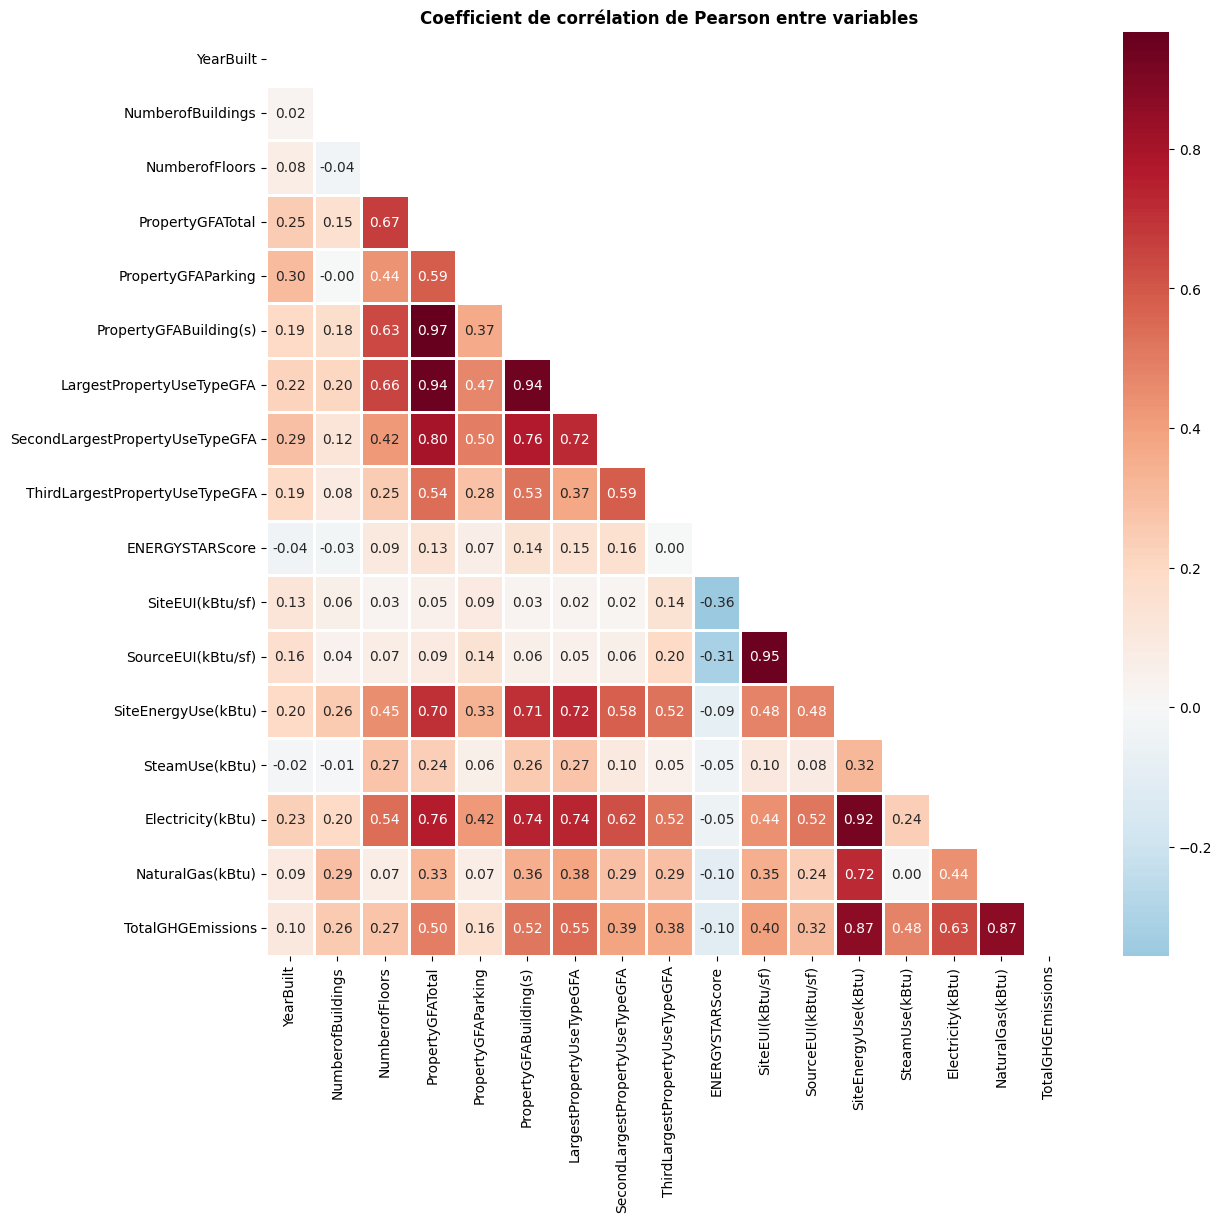

In [86]:
cols_to_exclude = [
    "OSEBuildingID",
    "CouncilDistrictCode",

    # méta / géo
    "DataYear",
    "ZipCode",
    "Latitude",
    "Longitude",

    # # surfaces très corrélées
    # "PropertyGFAParking",
    # "PropertyGFABuilding(s)",
    # "SecondLargestPropertyUseTypeGFA",
    # "ThirdLargestPropertyUseTypeGFA",

    # versions météo-normalisées
    "SiteEnergyUseWN(kBtu)",
    "SiteEUIWN(kBtu/sf)",
    "SourceEUIWN(kBtu/sf)",

    # doublons d’unités
    "Electricity(kWh)",
    "NaturalGas(therms)",

    # dérivé de la cible
    "GHGEmissionsIntensity",
]

corr = (df_troisieme_nettoyage.select_dtypes(include='number').drop(columns=cols_to_exclude).corr())

mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(13, 12))
sns.heatmap(corr, mask=mask, center=0, cmap='RdBu_r', linewidths=1, annot=True, fmt=".2f")
plt.title("Coefficient de corrélation de Pearson entre variables", fontweight="bold")
plt.show()

### Récapitulatif des éléments modifiés

In [87]:
print("Nombre de lignes avant nettoyage :", len(building_consumption))
print("Nombre de lignes après premier nettoyage :", len(df_premier_nettoyage))
print("Nombre de lignes après deuxième nettoyage :", len(df_deuxieme_nettoyage))
print("Nombre de lignes après troisième nettoyage :", len(df_troisieme_nettoyage))

Nombre de lignes avant nettoyage : 3376
Nombre de lignes après premier nettoyage : 1668
Nombre de lignes après deuxième nettoyage : 1624
Nombre de lignes après troisième nettoyage : 1570


# Modélisation 

### Import des modules 

In [ ]:
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV, 
    cross_validate,
    cross_val_score,
    KFold)

from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error , mean_absolute_percentage_error
from sklearn.inspection import permutation_importance

from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler

from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor, ExtraTreesRegressor

from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from xgboost import XGBRegressor


In [89]:
df_clean = df_troisieme_nettoyage.copy()

### Choix des Features X et target y

In [90]:
df_clean

,OSEBuildingID,DataYear,BuildingType,PrimaryPropertyType,ZipCode,CouncilDistrictCode,Neighborhood,Latitude,Longitude,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),ListOfAllPropertyUseTypes,LargestPropertyUseType,LargestPropertyUseTypeGFA,SecondLargestPropertyUseType,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseType,ThirdLargestPropertyUseTypeGFA,YearsENERGYSTARCertified,ENERGYSTARScore,SiteEUI(kBtu/sf),SiteEUIWN(kBtu/sf),SourceEUI(kBtu/sf),SourceEUIWN(kBtu/sf),SiteEnergyUse(kBtu),SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),ComplianceStatus,TotalGHGEmissions,GHGEmissionsIntensity
0,1,2016,NonResidential,Hotel,98101,7,DOWNTOWN,47.61220,-122.33799,1927,1,12,88434,0,88434,Hotel,Hotel,88434,NaN,NaN,NaN,NaN,NaN,60.0,81.699997,84.300003,182.500000,189.000000,7.226362e+06,7.456910e+06,2003882.00,1.156514e+06,3.946027e+06,12764.529300,1.276453e+06,Compliant,249.98,2.83
1,2,2016,NonResidential,Hotel,98101,7,DOWNTOWN,47.61317,-122.33393,1996,1,11,103566,15064,88502,"Hotel, Parking, Restaurant",Hotel,83880,Parking,15064.0,Restaurant,4622.0,NaN,61.0,94.800003,97.900002,176.100006,179.399994,8.387933e+06,8.664479e+06,0.00,9.504252e+05,3.242851e+06,51450.816410,5.145082e+06,Compliant,295.86,2.86
2,3,2016,NonResidential,Hotel,98101,7,DOWNTOWN,47.61393,-122.33810,1969,1,41,956110,196718,759392,Hotel,Hotel,756493,NaN,NaN,NaN,NaN,NaN,43.0,96.000000,97.699997,241.899994,244.100006,7.258702e+07,7.393711e+07,21566554.00,1.451544e+07,4.952666e+07,14938.000000,1.493800e+06,Compliant,2089.28,2.19
3,5,2016,NonResidential,Hotel,98101,7,DOWNTOWN,47.61412,-122.33664,1926,1,10,61320,0,61320,Hotel,Hotel,61320,NaN,NaN,NaN,NaN,NaN,56.0,110.800003,113.300003,216.199997,224.000000,6.794584e+06,6.946800e+06,2214446.25,8.115253e+05,2.768924e+06,18112.130860,1.811213e+06,Compliant,286.43,4.67
4,8,2016,NonResidential,Hotel,98121,7,DOWNTOWN,47.61375,-122.34047,1980,1,18,175580,62000,113580,"Hotel, Parking, Swimming Pool",Hotel,123445,Parking,68009.0,Swimming Pool,0.0,NaN,75.0,114.800003,118.699997,211.399994,215.600006,1.417261e+07,1.465650e+07,0.00,1.573449e+06,5.368607e+06,88039.984380,8.803998e+06,Compliant,505.01,2.88
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1619,50222,2016,Nonresidential COS,Office,<NA>,2,GREATER DUWAMISH,47.56722,-122.31154,1990,1,1,12294,0,12294,Office,Office,12294,NaN,NaN,NaN,NaN,NaN,46.0,69.099998,76.699997,161.699997,176.100006,8.497457e+05,9.430032e+05,0.00,1.536550e+05,5.242709e+05,3254.750244,3.254750e+05,Error - Correct Default Data,20.94,1.70
1620,50223,2016,Nonresidential COS,Other,<NA>,2,DOWNTOWN,47.59625,-122.32283,2004,1,1,16000,0,16000,Other - Recreation,Other - Recreation,16000,NaN,NaN,NaN,NaN,NaN,NaN,59.400002,65.900002,114.199997,118.900002,9.502762e+05,1.053706e+06,0.00,1.162210e+05,3.965461e+05,5537.299805,5.537300e+05,Compliant,32.17,2.01
1621,50224,2016,Nonresidential COS,Other,<NA>,7,MAGNOLIA / QUEEN ANNE,47.63644,-122.35784,1974,1,1,13157,0,13157,"Fitness Center/Health Club/Gym, Other - Recrea...",Other - Recreation,7583,Fitness Center/Health Club/Gym,5574.0,Swimming Pool,0.0,NaN,NaN,438.200012,460.100006,744.799988,767.799988,5.765898e+06,6.053764e+06,0.00,5.252517e+05,1.792159e+06,39737.390630,3.973739e+06,Compliant,223.54,16.99
1622,50225,2016,Nonresidential COS,Mixed Use Property,<NA>,1,GREATER DUWAMISH,47.52832,-122.32431,1989,1,1,14101,0,14101,"Fitness Center/Health Club/Gym, Food Service, ...",Other - Recreation,6601,Fitness Center/Health Club/Gym,6501.0,Pre-school/Daycare,484.0,NaN,NaN,51.000000,55.500000,105.300003,110.800003,7.194712e+05,7.828413e+05,0.00,1.022480e+05,3.488702e+05,3706.010010,3.706010e+05,Compliant,22.11,1.57


In [91]:
# %pip install xgboost

#### Initialisation de : LinearRegression, RandomForestRegressor et XGBoost

In [92]:
RANDOM_STATE = 45

linreg = LinearRegression()

rf = RandomForestRegressor(
    n_estimators=800,        # valeur de base raisonnable (la grille ajustera)
    max_depth=None,          # illimité (la grille peut fixer une profondeur)
    min_samples_leaf=2,      # un peu de régularisation
    n_jobs=-1, 
    random_state=RANDOM_STATE
)

xgb_param = dict(
    random_state=42,
    n_estimators=2000,    # nombre d’arbres 
    learning_rate=0.03,   # vitesse d’apprentissage
    max_depth=6,          # profondeur max des arbres
    subsample=0.8,        # pour éviter l’overfitting
    colsample_bytree=0.8, # idem
    tree_method="hist",   # rapide si dispo
    n_jobs=-1             # utilise tous les coeurs CPU
)

linreg_scaled = Pipeline([
    ("scaler", StandardScaler()),
    ("linreg", LinearRegression())
])

model_ETR = ExtraTreesRegressor(
    n_estimators=800, max_depth=None, min_samples_leaf=2,
    n_jobs=-1, random_state=RANDOM_STATE
)

cv = KFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)

xgb = XGBRegressor(
    n_estimators=800, learning_rate=0.05, max_depth=8,
    subsample=0.8, colsample_bytree=0.8, reg_lambda=1.0,
    n_jobs=-1, random_state=RANDOM_STATE, tree_method="hist"
)

#### Fonctions de nettoyage et d'évaluation

In [93]:
# def lower_and_uniformisation(s):
#     s = s.lower().strip()
#     s = re.sub(r"[^\w]+", "_", s)
#     s = re.sub(r"_{2,}", "_", s).strip("_")
#     return s or "unknown"

def lower_and_uniformisation(s):
    if pd.isna(s):
        return "unknown or NaN"
    s = str(s).strip().lower()
    s = re.sub(r"[^\w]+", "_", s)
    s = re.sub(r"_{2,}", "_", s).strip("_")
    return s or "unknown"

def split_and_clean(series):
    def split_one(x):
        if pd.isna(x):
            return []
        items = [i.strip() for i in str(x).split(",")]
        items = [lower_and_uniformisation(i) for i in items if i]
        return items
    return series.apply(split_one)

def eval_model(y_true, y_pred, name):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    print(f"{name} => MAE={mae:.2f}, RMSE={rmse:.2f}, R²={r2:.3f}")


if "Neighborhood" in df_clean.columns:
    df_clean["Neighborhood"] = df_clean["Neighborhood"].apply(lower_and_uniformisation)

for col in ["LargestPropertyUseType", "SecondLargestPropertyUseType", "ThirdLargestPropertyUseType"]:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].apply(lower_and_uniformisation)


df_clean["BuildingAge"] = df_clean["DataYear"] - df_clean["YearBuilt"]


# df_one_other_to_rule_them_all = df_clean.copy()
# df_one_other_to_rule_them_all["LargestPropertyUseType"] = df_one_other_to_rule_them_all["LargestPropertyUseType"].replace(
#     to_replace=r"^other.*", value="other", regex=True
# )
# df_one_other_to_rule_them_all["SecondLargestPropertyUseType"] = df_one_other_to_rule_them_all["SecondLargestPropertyUseType"].replace(
#     to_replace=r"^other.*", value="other", regex=True
# )
# df_one_other_to_rule_them_all["ThirdLargestPropertyUseType"] = df_one_other_to_rule_them_all["ThirdLargestPropertyUseType"].replace(
#     to_replace=r"^other.*", value="other", regex=True
# )

#### PARTIE STRCTURELLE 

In [ ]:
# ================================
# BLOC 1 — STRUCTUREL ONLY (sans log)
# ================================

df = df_clean.copy()

df["BuildingAge"] = df["DataYear"] - df["YearBuilt"]
df["PropertyGFATotal"] = df["PropertyGFATotal"].replace(0, np.nan)  # évite division par 0
df["NumberofFloors"]   = df["NumberofFloors"].replace(0, np.nan)

num_features = [
    "PropertyGFATotal",
    "LargestPropertyUseTypeGFA", "SecondLargestPropertyUseTypeGFA", "ThirdLargestPropertyUseTypeGFA",
    "NumberofBuildings", "NumberofFloors",
    "YearBuilt", "BuildingAge" 
]

cat_features = [
    "PrimaryPropertyType",
    "LargestPropertyUseType", "SecondLargestPropertyUseType", "ThirdLargestPropertyUseType",
    "Neighborhood"
]


y_co2    = df["TotalGHGEmissions"].copy()
y_energy = df["SiteEnergyUse(kBtu)"].copy()

X = df[num_features + cat_features].copy()

X_co2_train, X_co2_test, y_co2_train, y_co2_test = train_test_split(X, y_co2,    test_size=0.2, random_state=RANDOM_STATE)
X_en_train, X_en_test, y_en_train,  y_en_test  = train_test_split(X, y_energy,  test_size=0.2, random_state=RANDOM_STATE)

preprocessor = ColumnTransformer(
    transformers=[
        ("num",
         Pipeline(steps=[("imputer", SimpleImputer(strategy="median"))]),
         num_features),
        ("cat",
         Pipeline(steps=[
             ("imputer", SimpleImputer(strategy="most_frequent")),
             ("ohe", OneHotEncoder(handle_unknown="ignore", min_frequency=0.01, sparse_output=False))
         ]),
         cat_features)
    ],
    remainder="drop"
)

pipe = Pipeline([
    ("preprocess", preprocessor),
    ("model", model_ETR)
])



scores_co2 = cross_validate(
    pipe, X_co2_train, y_co2_train,
    cv=cv, scoring=("r2", "neg_mean_absolute_error"),
    n_jobs=-1, return_estimator=False
)
print("=== CO2 (Structure, sans log) — CV ===")
print(f"R² CV moyen : {scores_co2['test_r2'].mean():.3f} | MAE CV moyen : {-scores_co2['test_neg_mean_absolute_error'].mean():,.0f}")

pipe.fit(X_co2_train, y_co2_train)
y_pred = pipe.predict(X_co2_test)
print("=== CO2 (Structure, sans log) — Test ===")
print(f"R² Test : {r2_score(y_co2_test, y_pred):.3f} | MAE Test : {mean_absolute_error(y_co2_test, y_pred):,.0f}")



scores_en = cross_validate(
    pipe, X_en_train, y_en_train,
    cv=cv, scoring=("r2", "neg_mean_absolute_error"),
    n_jobs=-1, return_estimator=False
)
print("\n=== ÉNERGIE (Structure, sans log) — CV ===")
print(f"R² CV moyen : {scores_en['test_r2'].mean():.3f} | MAE CV moyen : {-scores_en['test_neg_mean_absolute_error'].mean():,.0f}")

pipe.fit(X_en_train, y_en_train)
y_pred = pipe.predict(X_en_test)
print("=== ÉNERGIE (Structure, sans log) — Test ===")
print(f"R² Test : {r2_score(y_en_test, y_pred):.3f} | MAE Test : {mean_absolute_error(y_en_test, y_pred):,.0f}")

=== CO2 (Structure, sans log) — CV ===
R² CV moyen : 0.550 | MAE CV moyen : 84
=== CO2 (Structure, sans log) — Test ===
R² Test : 0.455 | MAE Test : 102

=== ÉNERGIE (Structure, sans log) — CV ===
R² CV moyen : 0.635 | MAE CV moyen : 2,959,340
=== ÉNERGIE (Structure, sans log) — Test ===
R² Test : 0.703 | MAE Test : 2,840,584


In [ ]:
# ======================================
# BLOC 2 — STRUCTUREL ONLY (avec log sur y)
# J'ai pas vraiment besoin de log, c'est pour les cibles avec des zero etc..
# ======================================

# On réutilise X_train/X_test, preprocessor, et le même modèle de base
pipe = Pipeline([
    ("preprocess", preprocessor),
    ("model", model_ETR)
])

# Emballage log1p/expm1 de la CIBLE
ttr_co2 = TransformedTargetRegressor(
    regressor=pipe,
    func=np.log1p,
    inverse_func=np.expm1 
)

ttr_en = TransformedTargetRegressor(
    regressor=pipe,
    func=np.log1p,
    inverse_func=np.expm1
)

# CO2 (avec log sur y)
scores_co2 = cross_validate(
    ttr_co2, X_co2_train, y_co2_train,
    cv=cv, scoring=("r2", "neg_mean_absolute_error"),
    n_jobs=-1
)
print("\n=== CO2 (Structure, AVEC log(y)) — CV ===")
print(f"R² CV moyen : {scores_co2['test_r2'].mean():.3f} | MAE CV moyen : {-scores_co2['test_neg_mean_absolute_error'].mean():,.0f}")

ttr_co2.fit(X_co2_train, y_co2_train)
y_pred = ttr_co2.predict(X_co2_test)
print("=== CO2 (Structure, AVEC log(y)) — Test ===")
print(f"R² Test : {r2_score(y_co2_test, y_pred):.3f} | MAE Test : {mean_absolute_error(y_co2_test, y_pred):,.0f}")

# ÉNERGIE (avec log sur y)
scores_en = cross_validate(
    ttr_en, X_en_train, y_en_train,
    cv=cv, scoring=("r2", "neg_mean_absolute_error"),
    n_jobs=-1
)
print("\n=== ÉNERGIE (Structure, AVEC log(y)) — CV ===")
print(f"R² CV moyen : {scores_en['test_r2'].mean():.3f} | MAE CV moyen : {-scores_en['test_neg_mean_absolute_error'].mean():,.0f}")

ttr_en.fit(X_en_train, y_en_train)
y_pred = ttr_en.predict(X_en_test)
print("=== ÉNERGIE (Structure, AVEC log(y)) — Test ===")
print(f"R² Test : {r2_score(y_en_test, y_pred):.3f} | MAE Test : {mean_absolute_error(y_en_test, y_pred):,.0f}")



=== CO2 (Structure, AVEC log(y)) — CV ===
R² CV moyen : 0.514 | MAE CV moyen : 80
=== CO2 (Structure, AVEC log(y)) — Test ===
R² Test : 0.435 | MAE Test : 93

=== ÉNERGIE (Structure, AVEC log(y)) — CV ===
R² CV moyen : 0.633 | MAE CV moyen : 2,800,653
=== ÉNERGIE (Structure, AVEC log(y)) — Test ===
R² Test : 0.652 | MAE Test : 2,814,090


In [ ]:
# # ============================================
# # STRUCTUREL ONLY
# # RandomForest + GridSearchCV
# # - 2 modèles séparés (CO2 et Énergie)
# # - ColumnTransformer (imputation + OHE)
# # - Option log-transform sur la cible 
# # ============================================

# USE_LOG = True

# # Données & features structurelles minimales
# df = df_clean.copy()

# df["BuildingAge"] = df["DataYear"] - df["YearBuilt"]

# # df["PropertyGFATotal"] = df["PropertyGFATotal"].replace(0, np.nan)
# # df["NumberofFloors"]   = df["NumberofFloors"].replace(0, np.nan)

# # Listes de features (structurelles uniquement)
# num_features = [
#     "PropertyGFATotal",
#     "LargestPropertyUseTypeGFA", "SecondLargestPropertyUseTypeGFA", "ThirdLargestPropertyUseTypeGFA",
#     "NumberofBuildings", "NumberofFloors",
#     "YearBuilt", "BuildingAge",
# ]
# cat_features = [
#     "PrimaryPropertyType",
#     "LargestPropertyUseType", "SecondLargestPropertyUseType", "ThirdLargestPropertyUseType",
#     "Neighborhood",
# ]

# # Matrice X / y
# X = df[num_features + cat_features].copy()
# y_co2 = df["TotalGHGEmissions"].copy()
# y_en  = df["SiteEnergyUse(kBtu)"].copy()

# # Split commun (même découpe pour comparer)
# X_co2_train, X_co2_test, y_co2_train, y_co2_test = train_test_split(X, y_co2,    test_size=0.2, random_state=RANDOM_STATE)
# X_en_train, X_en_test, y_en_train,  y_en_test  = train_test_split(X, y_energy,  test_size=0.2, random_state=RANDOM_STATE)

# # Préprocesseur 
# # Explication :
# # - numériques : imputation médiane (robuste aux outliers)
# # - catégorielles : imputation par le mode + OneHotEncoder dense
# # Pourquoi dense ? pour éviter des soucis avec certains modèles et permettre get_feature_names_out facilement.
# preprocessor = ColumnTransformer(
#     transformers=[
#         ("num", Pipeline([("imputer", SimpleImputer(strategy="median"))]), num_features),
#         ("cat", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")),
#                           ("ohe", OneHotEncoder(handle_unknown="ignore", min_frequency=0.01, sparse_output=False))]),
#          cat_features),
#     ],
#     remainder="drop"
# )

# # Modèle & Pipeline 
# # Pourquoi RandomForest ?
# # - modèle d’arbres baggés : robuste, interprétable (importances), moins sensible aux hyperparamètres que XGB

# base_pipe = Pipeline([
#     ("preprocess", preprocessor),
#     ("model", rf)
# ])

# # Option log(y) : on emballe le pipeline dans TransformedTargetRegressor
# def maybe_wrap_with_log(base_pipe):
#     if USE_LOG:
#         return TransformedTargetRegressor(
#             regressor=pipe, func=np.log1p, inverse_func=np.expm1, check_inverse=False
#         )
#     else:
#         return base_pipe

# # Grille RandomForest 
# # - n_estimators : nb d’arbres (plus → plus stable mais plus lent)
# # - max_depth : limite la profondeur (contrôle la variance)
# # - min_samples_leaf : taille min d’une feuille (ralentit l’overfit)
# # - max_features : nb de variables testées à chaque split (0.5 ≈ 50% des features)
# param_grid = {
#     "regressor__model__n_estimators": [400, 800, 1200],
#     "regressor__model__max_depth": [None, 20, 40],
#     "regressor__model__min_samples_leaf": [1, 2, 4],
#     "regressor__model__max_features": ["sqrt", 0.5, 0.7],
# }


# # Si USE_LOG, le step s’appelle "regressor" (le TTR) → on passe toujours par "regressor__model__..."
# # car la grille cible le modèle interne du pipeline.

# # CO2 : CV + GridSearch + Test + importances
# co2_est = maybe_wrap_with_log(base_pipe)
# grid_co2 = GridSearchCV(
#     estimator=co2_est, param_grid=param_grid,
#     cv=cv, scoring="r2", n_jobs=-1, verbose=1, refit=True
# )

# # Petit récap CV avant Grid 
# cv_scores = cross_validate(co2_est, X_co2_train, y_co2_train, cv=cv,
#                            scoring=("r2","neg_mean_absolute_error"), n_jobs=-1)
# print("=== CO2 (Structure) — CV (avant Grid) ===")
# print(f"R² CV moyen: {cv_scores['test_r2'].mean():.3f} | MAE CV moyen: {-cv_scores['test_neg_mean_absolute_error'].mean():,.0f}")

# # GridSearch
# grid_co2.fit(X_co2_train, y_co2_train)
# y_pred = grid_co2.predict(X_co2_test)

# print("\n=== CO2 (Structure) — GridSearch(RandomForest) ===")
# print("Best params:", grid_co2.best_params_)
# print(f"Best mean R² (CV): {grid_co2.best_score_:0.3f}")
# print(f"TEST — R²: {r2_score(y_co2_test, y_pred):0.3f} | MAE: {mean_absolute_error(y_co2_test, y_pred):,.0f}")

# # ENERGIE : CV + GridSearch + Test + importances
# en_est = maybe_wrap_with_log(base_pipe)
# grid_en = GridSearchCV(
#     estimator=en_est, param_grid=param_grid,
#     cv=cv, scoring="r2", n_jobs=-1, verbose=1, refit=True
# )

# cv_scores = cross_validate(en_est, X_en_train, y_en_train, cv=cv,
#                            scoring=("r2","neg_mean_absolute_error"), n_jobs=-1)
# print("\n=== ÉNERGIE (Structure) — CV (avant Grid) ===")
# print(f"R² CV moyen: {cv_scores['test_r2'].mean():.3f} | MAE CV moyen: {-cv_scores['test_neg_mean_absolute_error'].mean():,.0f}")

# grid_en.fit(X_en_train, y_en_train)
# y_pred = grid_en.predict(X_en_test)

# print("\n=== ÉNERGIE (Structure) — GridSearch(RandomForest) ===")
# print("Best params:", grid_en.best_params_)
# print(f"Best mean R² (CV): {grid_en.best_score_:0.3f}")
# print(f"TEST — R²: {r2_score(y_en_test, y_pred):0.3f} | MAE: {mean_absolute_error(y_en_test, y_pred):,.0f}")


In [ ]:
# ============================================
# STRUCTUREL ONLY
# RandomForest + GridSearchCV
# - 2 modèles séparés (CO2 et Énergie)
# - ColumnTransformer (imputation + OHE)
# - Option log-transform sur la cible 
# ============================================

df = df_clean.copy()
df["BuildingAge"] = df["DataYear"] - df["YearBuilt"]

# df["PropertyGFATotal"] = df["PropertyGFATotal"].replace(0, np.nan)
# df["NumberofFloors"]   = df["NumberofFloors"].replace(0, np.nan)

# Listes de features (structurelles uniquement)
num_features = [
    "PropertyGFATotal",
    "LargestPropertyUseTypeGFA", "SecondLargestPropertyUseTypeGFA", "ThirdLargestPropertyUseTypeGFA",
    "NumberofBuildings", "NumberofFloors",
    "YearBuilt", "BuildingAge",
]
cat_features = [
    "PrimaryPropertyType",
    "LargestPropertyUseType", "SecondLargestPropertyUseType", "ThirdLargestPropertyUseType",
    "Neighborhood",
]

# Matrice X / y
X = df[num_features + cat_features].copy()
y_co2 = df["TotalGHGEmissions"].copy()
y_en  = df["SiteEnergyUse(kBtu)"].copy()

# Split commun 
X_co2_train, X_co2_test, y_co2_train, y_co2_test = train_test_split(X, y_co2,    test_size=0.2, random_state=RANDOM_STATE)
X_en_train, X_en_test, y_en_train,  y_en_test  = train_test_split(X, y_energy,  test_size=0.2, random_state=RANDOM_STATE)

# Préprocesseur 
# - numériques : imputation médiane (robuste aux outliers)
# - catégorielles : imputation par le mode + OneHotEncoder dense
preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline([("imputer", SimpleImputer(strategy="median"))]), num_features),
        ("cat", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")),
                          ("ohe", OneHotEncoder(handle_unknown="ignore", min_frequency=0.01, sparse_output=False))]),
         cat_features),
    ],
    remainder="drop"
)

# Modèle & Pipeline
# Pourquoi RandomForest ? Modèle d’arbres baggés : robuste, interprétable (importances), moins sensible aux hyperparamètres que XGB
base_pipe = Pipeline([
    ("preprocess", preprocessor),
    ("model", rf)
])

# Grille RandomForest
# - n_estimators : nb d’arbres (plus → plus stable mais plus lent)
# - max_depth : limite la profondeur (contrôle la variance)
# - min_samples_leaf : taille min d’une feuille (ralentit l’overfit)
# - max_features : nb de variables testées à chaque split (0.5 ≈ 50% des features)
param_grid = {
    "model__n_estimators": [400, 800, 1200],
    "model__max_depth": [None, 20, 40],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", 0.5, 0.7],
}

# CO2 : CV + GridSearch + Test + importances
grid_co2 = GridSearchCV(
    estimator=base_pipe, param_grid=param_grid,
    cv=cv, scoring="r2", n_jobs=-1, verbose=1, refit=True
)

# Petit récap CV avant Grid
cv_scores = cross_validate(base_pipe, X_co2_train, y_co2_train, cv=cv,
                           scoring=("r2","neg_mean_absolute_error"), n_jobs=-1)
print("=== CO2 (Structure) — CV (avant Grid) ===")
print(f"R² CV moyen: {cv_scores['test_r2'].mean():.3f} | MAE CV moyen: {-cv_scores['test_neg_mean_absolute_error'].mean():,.0f}")

# GridSearch
grid_co2.fit(X_co2_train, y_co2_train)
y_pred = grid_co2.predict(X_co2_test)

print("\n=== CO2 (Structure) — GridSearch(RandomForest) ===")
print("Best params:", grid_co2.best_params_)
print(f"Best mean R² (CV): {grid_co2.best_score_:0.3f}")
print(f"TEST — R²: {r2_score(y_co2_test, y_pred):0.3f} | MAE: {mean_absolute_error(y_co2_test, y_pred):,.0f}")

# ENERGIE : CV + GridSearch + Test + importances
grid_en = GridSearchCV(
    estimator=base_pipe, param_grid=param_grid,
    cv=cv, scoring="r2", n_jobs=-1, verbose=1, refit=True
)

cv_scores = cross_validate(base_pipe, X_en_train, y_en_train, cv=cv,
                           scoring=("r2","neg_mean_absolute_error"), n_jobs=-1)
print("\n=== ÉNERGIE (Structure) — CV (avant Grid) ===")
print(f"R² CV moyen: {cv_scores['test_r2'].mean():.3f} | MAE CV moyen: {-cv_scores['test_neg_mean_absolute_error'].mean():,.0f}")

grid_en.fit(X_en_train, y_en_train)
y_pred = grid_en.predict(X_en_test)

print("\n=== ÉNERGIE (Structure) — GridSearch(RandomForest) ===")
print("Best params:", grid_en.best_params_)
print(f"Best mean R² (CV): {grid_en.best_score_:0.3f}")
print(f"TEST — R²: {r2_score(y_en_test, y_pred):0.3f} | MAE: {mean_absolute_error(y_en_test, y_pred):,.0f}")

=== CO2 (Structure) — CV (avant Grid) ===
R² CV moyen: 0.473 | MAE CV moyen: 87
Fitting 10 folds for each of 81 candidates, totalling 810 fits

=== CO2 (Structure) — GridSearch(RandomForest) ===
Best params: {'model__max_depth': 20, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 1, 'model__n_estimators': 1200}
Best mean R² (CV): 0.519
TEST — R²: 0.371 | MAE: 101

=== ÉNERGIE (Structure) — CV (avant Grid) ===
R² CV moyen: 0.610 | MAE CV moyen: 3,079,325
Fitting 10 folds for each of 81 candidates, totalling 810 fits

=== ÉNERGIE (Structure) — GridSearch(RandomForest) ===
Best params: {'model__max_depth': 40, 'model__max_features': 0.5, 'model__min_samples_leaf': 1, 'model__n_estimators': 400}
Best mean R² (CV): 0.638
TEST — R²: 0.680 | MAE: 2,869,824


In [ ]:
# Recréation manuelle des meilleurs modèles trouvés
best_rf_co2 = RandomForestRegressor(
    n_estimators=1200,
    max_depth=20,
    min_samples_leaf=1,
    max_features='sqrt',
    random_state=RANDOM_STATE,
    n_jobs=-1
)

best_rf_en = RandomForestRegressor(
    n_estimators=400,
    max_depth=40,
    min_samples_leaf=1,
    max_features=0.5,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

In [ ]:
df = df_clean.copy()
df["BuildingAge"] = df["DataYear"] - df["YearBuilt"]

num_features = [
    "PropertyGFATotal",
    "LargestPropertyUseTypeGFA", "SecondLargestPropertyUseTypeGFA", "ThirdLargestPropertyUseTypeGFA",
    "NumberofBuildings", "NumberofFloors",
    "YearBuilt", "BuildingAge",
]
cat_features = [
    "PrimaryPropertyType",
    "LargestPropertyUseType", "SecondLargestPropertyUseType", "ThirdLargestPropertyUseType",
    "Neighborhood",
]

X = df[num_features + cat_features].copy()
y_co2 = df["TotalGHGEmissions"].copy()
y_en  = df["SiteEnergyUse(kBtu)"].copy()

# 1 seul split pour tout le monde
X_train, X_test, y_co2_train, y_co2_test, y_en_train, y_en_test = train_test_split(
    X, y_co2, y_en, test_size=0.2, random_state=RANDOM_STATE
)

# Préprocesseur
preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline([("imputer", SimpleImputer(strategy="median"))]), num_features),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("ohe", OneHotEncoder(handle_unknown="ignore", min_frequency=0.01, sparse_output=False))
        ]), cat_features),
    ],
    remainder="drop",
)

# Pipeline CO2 avec les best params
pipe_co2 = Pipeline([
    ("preprocess", preprocessor),
    ("model", best_rf_co2),
])

pipe_co2.fit(X_train, y_co2_train)
y_co2_pred = pipe_co2.predict(X_test)

print("=== CO2 — modèle final (best params) ===")
print(f"TEST — R²: {r2_score(y_co2_test, y_co2_pred):0.3f} | MAE: {mean_absolute_error(y_co2_test, y_co2_pred):,.0f}")

# Pipeline ÉNERGIE avec les best params
pipe_en = Pipeline([
    ("preprocess", preprocessor),
    ("model", best_rf_en),
])

pipe_en.fit(X_train, y_en_train)
y_en_pred = pipe_en.predict(X_test)

print("\n=== ÉNERGIE — modèle final (best params) ===")
print(f"TEST — R²: {r2_score(y_en_test, y_en_pred):0.3f} | MAE: {mean_absolute_error(y_en_test, y_en_pred):,.0f}")


=== CO2 — modèle final (best params) ===
TEST — R²: 0.371 | MAE: 101

=== ÉNERGIE — modèle final (best params) ===
TEST — R²: 0.680 | MAE: 2,869,824


#### PARTIE STRUCTURE + ENERGIES

In [ ]:
# # ============================================
# # Structure + Énergie (ratios énergie/surface)
# # Objectif : capturer l'intensité énergétique (kBtu / m²)
# # Modèles : RandomForest et XGBoost
# # ============================================

# USE_LOG = True  # on garde la transformation log(y)

# df = df_clean.copy()
# df["BuildingAge"] = df["DataYear"] - df["YearBuilt"]

# # Ratios énergie/surface 
# df["Elec_GFA_share"]  = df["Electricity(kBtu)"] / df["PropertyGFATotal"]
# df["Gas_GFA_share"]   = df["NaturalGas(kBtu)"]  / df["PropertyGFATotal"]
# df["Steam_GFA_share"] = df["SteamUse(kBtu)"]    / df["PropertyGFATotal"]

# df[["Elec_GFA_share","Gas_GFA_share","Steam_GFA_share"]] = (
#     df[["Elec_GFA_share","Gas_GFA_share","Steam_GFA_share"]]
#     .replace([np.inf, -np.inf], np.nan)
#     .fillna(0.0)
# )

# # Features
# num_features = [
#     "PropertyGFATotal",
#     "LargestPropertyUseTypeGFA", "SecondLargestPropertyUseTypeGFA", "ThirdLargestPropertyUseTypeGFA",
#     "NumberofBuildings", "NumberofFloors",
#     "YearBuilt", "BuildingAge",
#     "Elec_GFA_share", "Gas_GFA_share", "Steam_GFA_share"
# ]
# cat_features = [
#     "PrimaryPropertyType",
#     "LargestPropertyUseType", "SecondLargestPropertyUseType", "ThirdLargestPropertyUseType",
#     "Neighborhood"
# ]

# # X / y
# X = df[num_features + cat_features].copy()
# y_co2 = df["TotalGHGEmissions"].copy()
# y_en  = df["SiteEnergyUse(kBtu)"].copy()

# # Split commun
# X_co2_train, X_co2_test, y_co2_train, y_co2_test = train_test_split(X, y_co2,    test_size=0.2, random_state=RANDOM_STATE)
# X_en_train, X_en_test, y_en_train,  y_en_test  = train_test_split(X, y_energy,  test_size=0.2, random_state=RANDOM_STATE)

# # Préprocesseur : impute + OHE
# preprocessor = ColumnTransformer(
#     transformers=[
#         ("num", Pipeline([("imputer", SimpleImputer(strategy="median"))]), num_features),
#         ("cat", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")),
#                           ("ohe", OneHotEncoder(handle_unknown="ignore", min_frequency=0.01, sparse_output=False))]),
#          cat_features),
#     ],
#     remainder="drop"
# )

# # Fonction utilitaire pour envelopper avec log(y)
# def wrap(pipe):
#     if USE_LOG:
#         return TransformedTargetRegressor(
#             regressor=pipe, func=np.log1p, inverse_func=np.expm1, check_inverse=False
#         )
#     else:
#         return pipe

# # PIPELINES
# pipe_rf = Pipeline([("preprocess", preprocessor), ("model", rf)])
# pipe_xgb = Pipeline([("preprocess", preprocessor), ("model", xgb)])

# # COMPARAISON DES ALGORITHMES — CO2
# ttr_rf = wrap(pipe_rf)
# ttr_xgb = wrap(pipe_xgb)

# scores_rf = cross_validate(ttr_rf, X_co2_train, y_co2_train, cv=cv, scoring=("r2","neg_mean_absolute_error"), n_jobs=-1)
# scores_xgb = cross_validate(ttr_xgb, X_co2_train, y_co2_train, cv=cv, scoring=("r2","neg_mean_absolute_error"), n_jobs=-1)

# print("=== CO2 (Structure + Énergie/GFA) — Comparaison CV ===")
# print(f"  RandomForest | R²={scores_rf['test_r2'].mean():.3f} | MAE={-scores_rf['test_neg_mean_absolute_error'].mean():,.0f}")
# print(f"  XGBoost      | R²={scores_xgb['test_r2'].mean():.3f} | MAE={-scores_xgb['test_neg_mean_absolute_error'].mean():,.0f}")

# best_algo_co2 = "RandomForest" if scores_rf["test_r2"].mean() >= scores_xgb["test_r2"].mean() else "XGBoost"
# print(f"→ Meilleur algo CO2 : {best_algo_co2}")

# # GRIDSEARCH sur le meilleur algo (CO2)
# if best_algo_co2 == "RandomForest":
#     model = RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1)
#     param_grid = {
#         "regressor__model__n_estimators": [600, 900, 1200],
#         "regressor__model__max_depth": [None, 30, 60],
#         "regressor__model__min_samples_leaf": [1, 2, 4],
#         "regressor__model__max_features": ["sqrt", 0.5, 0.7]
#     }
# else:
#     model = XGBRegressor(
#         n_jobs=-1, random_state=RANDOM_STATE, tree_method="hist",
#         n_estimators=800, max_depth=8, learning_rate=0.05,
#         subsample=0.8, colsample_bytree=0.8, reg_lambda=1.0
#     )
#     param_grid = {
#         "regressor__model__n_estimators": [800, 1200, 1600],
#         "regressor__model__max_depth": [6, 8, 10],
#         "regressor__model__learning_rate": [0.03, 0.05, 0.08],
#         "regressor__model__subsample": [0.7, 0.85, 1.0],
#         "regressor__model__colsample_bytree": [0.6, 0.8, 1.0],
#         "regressor__model__reg_lambda": [0.5, 1.0, 2.0],
#     }

# pipe = Pipeline([("preprocess", preprocessor), ("model", model)])
# ttr = wrap(pipe)

# grid_co2 = GridSearchCV(
#     estimator=ttr, param_grid=param_grid,
#     cv=cv, scoring="r2", n_jobs=-1, verbose=1, refit=True
# )
# grid_co2.fit(X_co2_train, y_co2_train)
# y_pred = grid_co2.predict(X_co2_test)

# print("\n=== CO2 (Structure+Énergie/GFA) — GridSearch ===")
# print("Best params:", grid_co2.best_params_)
# print(f"Best mean R² (CV): {grid_co2.best_score_:.3f}")
# print(f"TEST — R²: {r2_score(y_co2_test, y_pred):.3f} | MAE: {mean_absolute_error(y_co2_test, y_pred):,.0f}")

# # ENERGIE
# scores_rf = cross_validate(ttr_rf, X_en_train, y_en_train, cv=cv,
#                            scoring=("r2","neg_mean_absolute_error"), n_jobs=-1)
# scores_xgb = cross_validate(ttr_xgb, X_en_train, y_en_train, cv=cv,
#                             scoring=("r2","neg_mean_absolute_error"), n_jobs=-1)

# print("\n=== ÉNERGIE (Structure + Énergie/GFA) — Comparaison CV ===")
# print(f"  RandomForest | R²={scores_rf['test_r2'].mean():.3f} | MAE={-scores_rf['test_neg_mean_absolute_error'].mean():,.0f}")
# print(f"  XGBoost      | R²={scores_xgb['test_r2'].mean():.3f} | MAE={-scores_xgb['test_neg_mean_absolute_error'].mean():,.0f}")

# best_algo_en = "RandomForest" if scores_rf["test_r2"].mean() >= scores_xgb["test_r2"].mean() else "XGBoost"
# print(f"→ Meilleur algo ÉNERGIE : {best_algo_en}")

# if best_algo_en == "RandomForest":
#     model = RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1)
#     param_grid = {
#         "regressor__model__n_estimators": [600, 900, 1200],
#         "regressor__model__max_depth": [None, 30, 60],
#         "regressor__model__min_samples_leaf": [1, 2, 4],
#         "regressor__model__max_features": ["sqrt", 0.5, 0.7]
#     }
# else:
#     model = XGBRegressor(
#         n_jobs=-1, random_state=RANDOM_STATE, tree_method="hist",
#         n_estimators=800, max_depth=8, learning_rate=0.05,
#         subsample=0.8, colsample_bytree=0.8, reg_lambda=1.0
#     )
#     param_grid = {
#         "regressor__model__n_estimators": [800, 1200, 1600],
#         "regressor__model__max_depth": [6, 8, 10],
#         "regressor__model__learning_rate": [0.03, 0.05, 0.08],
#         "regressor__model__subsample": [0.7, 0.85, 1.0],
#         "regressor__model__colsample_bytree": [0.6, 0.8, 1.0],
#         "regressor__model__reg_lambda": [0.5, 1.0, 2.0],
#     }

# pipe = Pipeline([("preprocess", preprocessor), ("model", model)])
# ttr = wrap(pipe)

# grid_en = GridSearchCV(
#     estimator=ttr, param_grid=param_grid,
#     cv=cv, scoring="r2", n_jobs=-1, verbose=1, refit=True
# )
# grid_en.fit(X_en_train, y_en_train)
# y_pred = grid_en.predict(X_en_test)

# print("\n=== ÉNERGIE (Structure+Énergie/GFA) — GridSearch ===")
# print("Best params:", grid_en.best_params_)
# print(f"Best mean R² (CV): {grid_en.best_score_:.3f}")
# print(f"TEST — R²: {r2_score(y_en_test, y_pred):.3f} | MAE: {mean_absolute_error(y_en_test, y_pred):,.0f}")

=== CO2 (Structure + Énergie/GFA) — Comparaison CV ===
  RandomForest | R²=0.826 | MAE=30
  XGBoost      | R²=0.864 | MAE=28
→ Meilleur algo CO2 : XGBoost
Fitting 10 folds for each of 729 candidates, totalling 7290 fits

=== CO2 (Structure+Énergie/GFA) — GridSearch ===
Best params: {'regressor__model__colsample_bytree': 1.0, 'regressor__model__learning_rate': 0.03, 'regressor__model__max_depth': 10, 'regressor__model__n_estimators': 1200, 'regressor__model__reg_lambda': 0.5, 'regressor__model__subsample': 0.7}
Best mean R² (CV): 0.899
TEST — R²: 0.845 | MAE: 26

=== ÉNERGIE (Structure + Énergie/GFA) — Comparaison CV ===
  RandomForest | R²=0.876 | MAE=1,227,735
  XGBoost      | R²=0.927 | MAE=989,536
→ Meilleur algo ÉNERGIE : XGBoost
Fitting 10 folds for each of 729 candidates, totalling 7290 fits

=== ÉNERGIE (Structure+Énergie/GFA) — GridSearch ===
Best params: {'regressor__model__colsample_bytree': 1.0, 'regressor__model__learning_rate': 0.05, 'regressor__model__max_depth': 6, 'regr

In [106]:
# ============================================
# Structure + Énergie (ratios énergie/surface)
# Objectif : capturer l'intensité énergétique (kBtu / m²)
# Modèles : RandomForest et XGBoost
# ============================================

df = df_clean.copy()
df["BuildingAge"] = df["DataYear"] - df["YearBuilt"]

# Ratios énergie/surface 
df["Elec_GFA_share"]  = df["Electricity(kBtu)"] / df["PropertyGFATotal"]
df["Gas_GFA_share"]   = df["NaturalGas(kBtu)"]  / df["PropertyGFATotal"]
df["Steam_GFA_share"] = df["SteamUse(kBtu)"]    / df["PropertyGFATotal"]

df[["Elec_GFA_share","Gas_GFA_share","Steam_GFA_share"]] = (
    df[["Elec_GFA_share","Gas_GFA_share","Steam_GFA_share"]]
    .replace([np.inf, -np.inf], np.nan)
    .fillna(0.0)
)

# Features
num_features = [
    "PropertyGFATotal",
    "LargestPropertyUseTypeGFA", "SecondLargestPropertyUseTypeGFA", "ThirdLargestPropertyUseTypeGFA",
    "NumberofBuildings", "NumberofFloors",
    "YearBuilt", "BuildingAge",
    "Elec_GFA_share", "Gas_GFA_share", "Steam_GFA_share"
]
cat_features = [
    "PrimaryPropertyType",
    "LargestPropertyUseType", "SecondLargestPropertyUseType", "ThirdLargestPropertyUseType",
    "Neighborhood"
]

# X / y
X = df[num_features + cat_features].copy()
y_co2 = df["TotalGHGEmissions"].copy()
y_en  = df["SiteEnergyUse(kBtu)"].copy()

# Split commun
X_co2_train, X_co2_test, y_co2_train, y_co2_test = train_test_split(X, y_co2, test_size=0.2, random_state=RANDOM_STATE)
X_en_train, X_en_test, y_en_train, y_en_test = train_test_split(X, y_en, test_size=0.2, random_state=RANDOM_STATE)

# Préprocesseur : impute + OHE
preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline([("imputer", SimpleImputer(strategy="median"))]), num_features),
        ("cat", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")),
                          ("ohe", OneHotEncoder(handle_unknown="ignore", min_frequency=0.01, sparse_output=False))]),
         cat_features),
    ],
    remainder="drop"
)

# PIPELINES
ttr_rf = Pipeline([("preprocess", preprocessor), ("model", rf)])
ttr_xgb = Pipeline([("preprocess", preprocessor), ("model", xgb)])

scores_rf = cross_validate(ttr_rf, X_co2_train, y_co2_train, cv=cv, scoring=("r2","neg_mean_absolute_error"), n_jobs=-1)
scores_xgb = cross_validate(ttr_xgb, X_co2_train, y_co2_train, cv=cv, scoring=("r2","neg_mean_absolute_error"), n_jobs=-1)

print("=== CO2 (Structure + Énergie/GFA) — Comparaison CV ===")
print(f"  RandomForest | R²={scores_rf['test_r2'].mean():.3f} | MAE={-scores_rf['test_neg_mean_absolute_error'].mean():,.0f}")
print(f"  XGBoost      | R²={scores_xgb['test_r2'].mean():.3f} | MAE={-scores_xgb['test_neg_mean_absolute_error'].mean():,.0f}")

best_algo_co2 = "RandomForest" if scores_rf["test_r2"].mean() >= scores_xgb["test_r2"].mean() else "XGBoost"
print(f"Meilleur algo CO2 : {best_algo_co2}")

# GRIDSEARCH sur le meilleur algo (CO2)
if best_algo_co2 == "RandomForest":
    model = RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1)
    param_grid = {
        "model__n_estimators": [600, 900, 1200],
        "model__max_depth": [None, 30, 60],
        "model__min_samples_leaf": [1, 2, 4],
        "model__max_features": ["sqrt", 0.5, 0.7]
    }
else:
    model = XGBRegressor(
        n_jobs=-1, random_state=RANDOM_STATE, tree_method="hist",
        n_estimators=800, max_depth=8, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8, reg_lambda=1.0
    )
    
    param_grid = {
        "model__n_estimators": [800, 1200, 1600],
        "model__max_depth": [6, 8, 10],
        "model__learning_rate": [0.03, 0.05, 0.08],
        "model__subsample": [0.7, 0.85, 1.0],
        "model__colsample_bytree": [0.6, 0.8, 1.0],
        "model__reg_lambda": [0.5, 1.0, 2.0],
    }

ttr = Pipeline([("preprocess", preprocessor), ("model", model)])

grid_co2 = GridSearchCV(
    estimator=ttr, param_grid=param_grid,
    cv=cv, scoring="r2", n_jobs=-1, verbose=1, refit=True
)
grid_co2.fit(X_co2_train, y_co2_train)
y_pred = grid_co2.predict(X_co2_test)

print("\n=== CO2 (Structure+Énergie/GFA) — GridSearch ===")
print("Best params:", grid_co2.best_params_)
print(f"Best mean R² (CV): {grid_co2.best_score_:.3f}")
print(f"TEST — R²: {r2_score(y_co2_test, y_pred):.3f} | MAE: {mean_absolute_error(y_co2_test, y_pred):,.0f}")



# ENERGIE
scores_rf = cross_validate(ttr_rf, X_en_train, y_en_train, cv=cv,
                           scoring=("r2","neg_mean_absolute_error"), n_jobs=-1)
scores_xgb = cross_validate(ttr_xgb, X_en_train, y_en_train, cv=cv,
                            scoring=("r2","neg_mean_absolute_error"), n_jobs=-1)

print("\n=== ÉNERGIE (Structure + Énergie/GFA) — Comparaison CV ===")
print(f"  RandomForest | R²={scores_rf['test_r2'].mean():.3f} | MAE={-scores_rf['test_neg_mean_absolute_error'].mean():,.0f}")
print(f"  XGBoost      | R²={scores_xgb['test_r2'].mean():.3f} | MAE={-scores_xgb['test_neg_mean_absolute_error'].mean():,.0f}")

best_algo_en = "RandomForest" if scores_rf["test_r2"].mean() >= scores_xgb["test_r2"].mean() else "XGBoost"
print(f"Meilleur algo ÉNERGIE : {best_algo_en}")

if best_algo_en == "RandomForest":
    model = RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1)
    param_grid = {
        "model__n_estimators": [600, 900, 1200],
        "model__max_depth": [None, 30, 60],
        "model__min_samples_leaf": [1, 2, 4],
        "model__max_features": ["sqrt", 0.5, 0.7]
    }
else:
    model = XGBRegressor(
        n_jobs=-1, random_state=RANDOM_STATE, tree_method="hist",
        n_estimators=800, max_depth=8, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8, reg_lambda=1.0
    )
    param_grid = {
        "model__n_estimators": [800, 1200, 1600],
        "model__max_depth": [6, 8, 10],
        "model__learning_rate": [0.03, 0.05, 0.08],
        "model__subsample": [0.7, 0.85, 1.0],
        "model__colsample_bytree": [0.6, 0.8, 1.0],
        "model__reg_lambda": [0.5, 1.0, 2.0],
    }

ttr = Pipeline([("preprocess", preprocessor), ("model", model)])

grid_en = GridSearchCV(
    estimator=ttr, param_grid=param_grid,
    cv=cv, scoring="r2", n_jobs=-1, verbose=1, refit=True
)
grid_en.fit(X_en_train, y_en_train)
y_pred = grid_en.predict(X_en_test)

print("\n=== ÉNERGIE (Structure+Énergie/GFA) — GridSearch ===")
print("Best params:", grid_en.best_params_)
print(f"Best mean R² (CV): {grid_en.best_score_:.3f}")
print(f"TEST — R²: {r2_score(y_en_test, y_pred):.3f} | MAE: {mean_absolute_error(y_en_test, y_pred):,.0f}")

=== CO2 (Structure + Énergie/GFA) — Comparaison CV ===
  RandomForest | R²=0.866 | MAE=29
  XGBoost      | R²=0.794 | MAE=31
Meilleur algo CO2 : RandomForest
Fitting 10 folds for each of 81 candidates, totalling 810 fits

=== CO2 (Structure+Énergie/GFA) — GridSearch ===
Best params: {'model__max_depth': 30, 'model__max_features': 0.7, 'model__min_samples_leaf': 1, 'model__n_estimators': 600}
Best mean R² (CV): 0.862
TEST — R²: 0.816 | MAE: 35

=== ÉNERGIE (Structure + Énergie/GFA) — Comparaison CV ===
  RandomForest | R²=0.914 | MAE=1,142,879
  XGBoost      | R²=0.925 | MAE=1,078,257
Meilleur algo ÉNERGIE : XGBoost
Fitting 10 folds for each of 729 candidates, totalling 7290 fits

=== ÉNERGIE (Structure+Énergie/GFA) — GridSearch ===
Best params: {'model__colsample_bytree': 1.0, 'model__learning_rate': 0.05, 'model__max_depth': 6, 'model__n_estimators': 1600, 'model__reg_lambda': 0.5, 'model__subsample': 0.7}
Best mean R² (CV): 0.946
TEST — R²: 0.957 | MAE: 804,075


In [107]:
# Recréation manuelle des meilleurs modèles trouvés
best_rf_co2_with_energy_share = RandomForestRegressor(
    n_estimators=600, max_depth=30, min_samples_leaf=1, max_features=0.7,
    random_state=RANDOM_STATE, n_jobs=-1
)

best_xgb_en_with_energy_share = XGBRegressor(
    n_estimators=1600, max_depth=6, learning_rate=0.05,
    subsample=0.7, colsample_bytree=1.0, reg_lambda=0.5,
    tree_method="hist", n_jobs=-1, random_state=RANDOM_STATE
)

In [108]:
df = df_clean.copy()
df["BuildingAge"] = df["DataYear"] - df["YearBuilt"]
df["Elec_GFA_share"]  = df["Electricity(kBtu)"] / df["PropertyGFATotal"]
df["Gas_GFA_share"]   = df["NaturalGas(kBtu)"]  / df["PropertyGFATotal"]
df["Steam_GFA_share"] = df["SteamUse(kBtu)"]    / df["PropertyGFATotal"]
df[["Elec_GFA_share","Gas_GFA_share","Steam_GFA_share"]] = (
    df[["Elec_GFA_share","Gas_GFA_share","Steam_GFA_share"]]
    .replace([np.inf, -np.inf], np.nan)
    .fillna(0.0)
)

num_features = [
    "PropertyGFATotal",
    "LargestPropertyUseTypeGFA", "SecondLargestPropertyUseTypeGFA", "ThirdLargestPropertyUseTypeGFA",
    "NumberofBuildings", "NumberofFloors",
    "YearBuilt", "BuildingAge",
    "Elec_GFA_share", "Gas_GFA_share", "Steam_GFA_share"
]
cat_features = [
    "PrimaryPropertyType",
    "LargestPropertyUseType", "SecondLargestPropertyUseType", "ThirdLargestPropertyUseType",
    "Neighborhood"
]

# X / y
X = df[num_features + cat_features].copy()
y_co2 = df["TotalGHGEmissions"].copy()
y_en  = df["SiteEnergyUse(kBtu)"].copy()

X_train, X_test, y_co2_train, y_co2_test, y_en_train, y_en_test = train_test_split(
    X, y_co2, y_en, test_size=0.2, random_state=RANDOM_STATE
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
        ]), num_features),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("ohe", OneHotEncoder(handle_unknown="ignore", min_frequency=0.01, sparse_output=False)),
        ]), cat_features),
    ],
    remainder="drop",
)

pipe_co2 = Pipeline([
    ("preprocess", preprocessor),
    ("model", best_rf_co2_with_energy_share),
])

pipe_en = Pipeline([
    ("preprocess", preprocessor),
    ("model", best_xgb_en_with_energy_share),
])

pipe_co2.fit(X_train, y_co2_train)
y_co2_pred = pipe_co2.predict(X_test)
print("=== CO2 — modèle final (RF + ratios GFA) ===")
print(f"TEST — R²: {r2_score(y_co2_test, y_co2_pred):0.3f} | MAE: {mean_absolute_error(y_co2_test, y_co2_pred):,.0f}")

pipe_en.fit(X_train, y_en_train)
y_en_pred = pipe_en.predict(X_test)
print("\n=== ÉNERGIE — modèle final (XGB + ratios GFA) ===")
print(f"TEST — R²: {r2_score(y_en_test, y_en_pred):0.3f} | MAE: {mean_absolute_error(y_en_test, y_en_pred):,.0f}")

=== CO2 — modèle final (RF + ratios GFA) ===
TEST — R²: 0.816 | MAE: 35

=== ÉNERGIE — modèle final (XGB + ratios GFA) ===
TEST — R²: 0.957 | MAE: 804,075


In [ ]:
print(projectstop)

NameError: name 'projectstop' is not defined

# Tous les autres tests avant de savoir pour le CO2

### Dataset 1 (Avec LargestPropertyUseType)

In [ ]:
# X = df_clean[['YearBuilt', 'NumberofBuildings', 'PropertyGFATotal', 'LargestPropertyUseType']]

# y = df_clean[['SiteEnergyUse(kBtu)']]

# X = pd.get_dummies(df_clean[['YearBuilt', 'NumberofBuildings', 'PropertyGFATotal', 'LargestPropertyUseType']])

In [ ]:
num_cols = ["BuildingAge", "NumberofBuildings", "PropertyGFATotal"]

df_clean["LargestPropertyUseType_clean"] = df_clean["LargestPropertyUseType"].apply(
    lambda x: lower_and_uniformisation(x) if pd.notna(x) else "unknown"
)

X = pd.get_dummies(
    df_clean[num_cols + ["LargestPropertyUseType_clean"]],
    columns=["LargestPropertyUseType_clean"],
    prefix="has"           # donnera has_hotel, has_office, etc...
)

y = df_clean["SiteEnergyUse(kBtu)"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

#### Linearregression + cross_validation pour le premier dataset

In [ ]:
cv_r2   = cross_val_score(linreg_scaled, X_train, y_train, cv=5, scoring="r2")
cv_mae  = cross_val_score(linreg_scaled, X_train, y_train, cv=5, scoring="neg_mean_absolute_error")
cv_rmse = cross_val_score(linreg_scaled, X_train, y_train, cv=5, scoring="neg_root_mean_squared_error")

print("R² moyen :", np.mean(cv_r2))
print("MAE moyen :", -np.mean(cv_mae))
print("RMSE moyen :", -np.mean(cv_rmse))

R² moyen : 0.5277869752057677
MAE moyen : 3179856.129726842
RMSE moyen : 7260920.8870488005


#### Linearregression pour le premier dataset

In [ ]:
# linreg.fit(X_train, y_train)
# y_pred_lin = linreg.predict(X_test)

In [ ]:
linreg_scaled.fit(X_train, y_train)
y_pred_lin = linreg_scaled.predict(X_test)

In [ ]:
mae  = mean_absolute_error(y_test, y_pred_lin) 
# C’est la moyenne des erreurs en valeur absolue
# Concrètement : “en moyenne, le modèle se trompe de … kBtu”
# Plus le MAE est petit, mieux c’est

mse  = mean_squared_error(y_test, y_pred_lin)
# C’est la moyenne des erreurs au carré
# Ça pénalise très fortement les grosses erreurs
# Un peu dur à interpréter car l’unité est au carré (kBtu²)

rmse = np.sqrt(mse)
# C’est la racine carrée du MSE, donc on revient dans la même unité que la cible
# Interprétation : “l’erreur moyenne typique est d’environ … kBtu”
# Comme le MAE, mais plus sensible aux grosses erreurs

r2   = r2_score(y_test, y_pred_lin)
# Mesure de la qualité globale du modèle
# 1.0 = parfait (le modèle colle exactement aux données)
# 0.0 = le modèle ne fait pas mieux qu’une prédiction constante (la moyenne de y)
# < 0 = le modèle est pire qu’une prédiction bête avec la moyenne
# C’est souvent la métrique la plus regardée en régression.

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R²  :", r2)

MAE : 3730593.4314275635
MSE : 67740040830503.75
RMSE: 8230433.8178800605
R²  : 0.5963607032564673


#### Randomforestregressor pour le premier dataset

In [ ]:
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

#### XGBoost pour le premier dataset 

In [ ]:
xgb1 = XGBRegressor(**xgb_param)
xgb1.fit(X_train, y_train)

y_pred_xgb = xgb1.predict(X_test)

#### Résultat pour le premier dataset :

In [ ]:
eval_model(y_test, y_pred_lin, "Régression Linéaire")
print()
eval_model(y_test, y_pred_rf,  "Random Forest")
print()
eval_model(y_test, y_pred_xgb, "XGBoost")

Régression Linéaire => MAE=3730593.43, RMSE=8230433.82, R²=0.596

Random Forest => MAE=3673904.97, RMSE=8888550.36, R²=0.529

XGBoost => MAE=3988524.79, RMSE=9068846.90, R²=0.510


### Dataset 2 (avec 'ListOfAllPropertyUseTypes' à la place de 'LargestPropertyUseType')

In [ ]:
# X_2 = df_clean[['YearBuilt', 'NumberofBuildings', 'PropertyGFATotal', 'ListOfAllPropertyUseTypes']]

# y_2 = df_clean[['SiteEnergyUse(kBtu)']]

In [ ]:
# X_2 = pd.get_dummies(df_clean[['YearBuilt', 'NumberofBuildings', 'PropertyGFATotal', 'ListOfAllPropertyUseTypes']])

In [ ]:
# Découper + nettoyer 
lists_clean = split_and_clean(df_clean["ListOfAllPropertyUseTypes"])

# Binariser
mlb = MultiLabelBinarizer()
fit_liste_clean = mlb.fit_transform(lists_clean)

# DataFrame avec des noms propres de colonnes
multi_hot = pd.DataFrame(
    fit_liste_clean,
    columns=[f"has_{c}" for c in mlb.classes_],  # mlb.classes_ = étiquettes apprises
    index=df_clean.index
)

num_cols = ["BuildingAge", "NumberofBuildings", "PropertyGFATotal"]

X_2 = pd.concat([df_clean[num_cols], multi_hot], axis=1)

y_2  = df_clean["SiteEnergyUse(kBtu)"]

In [ ]:
lists_clean

0                                                 [hotel]
1                            [hotel, parking, restaurant]
2                                                 [hotel]
3                                                 [hotel]
4                         [hotel, parking, swimming_pool]
                              ...                        
1619                                             [office]
1620                                   [other_recreation]
1621    [fitness_center_health_club_gym, other_recreat...
1622    [fitness_center_health_club_gym, food_service,...
1623    [fitness_center_health_club_gym, food_service,...
Name: ListOfAllPropertyUseTypes, Length: 1570, dtype: object

In [ ]:
X_train_2, X_test_2, y_train_2, y_test_2 = train_test_split(X_2, y_2, test_size=0.3, random_state=42)

#### Linearregression + cross_validation pour le deuxième dataset

In [ ]:
cv_r2_2   = cross_val_score(linreg_scaled, X_train_2, y_train_2, cv=5, scoring="r2")
cv_mae_2  = cross_val_score(linreg_scaled, X_train_2, y_train_2, cv=5, scoring="neg_mean_absolute_error")
cv_rmse_2 = cross_val_score(linreg_scaled, X_train_2, y_train_2, cv=5, scoring="neg_root_mean_squared_error")

print("R² moyen :", np.mean(cv_r2_2))
print("MAE moyen :", -np.mean(cv_mae_2))
print("RMSE moyen :", -np.mean(cv_rmse_2))

R² moyen : 0.5317946958431102
MAE moyen : 3289760.4764106018
RMSE moyen : 7228576.982924737


#### linearregression pour le deuxième dataset

In [ ]:
# linreg.fit(X_train_2, y_train_2)
# y_pred_lin_2 = linreg.predict(X_test_2)

In [ ]:
linreg_scaled.fit(X_train_2, y_train_2)
y_pred_lin_2 = linreg_scaled.predict(X_test_2)

In [ ]:
mae_2  = mean_absolute_error(y_test_2, y_pred_lin_2) 

mse_2  = mean_squared_error(y_test_2, y_pred_lin_2)

rmse_2 = np.sqrt(mse_2)

r2_2   = r2_score(y_test_2, y_pred_lin_2)

print(f"MAE alt :", mae_2)
print(f"MSE alt :", mse_2)
print(f"RMSE alt :", rmse_2)
print(f"R² alt :", r2_2)

MAE alt : 3840778.456478718
MSE alt : 68895531124629.63
RMSE alt : 8300333.193591064
R² alt : 0.5894755392678308


#### Randomforestregressor pour le deuxième dataset

In [ ]:
rf.fit(X_train_2, y_train_2)
y_pred_rf_2 = rf.predict(X_test_2)

#### XGBoost pour le deuxième dataset 

In [ ]:
xgb2 = XGBRegressor(**xgb_param)
xgb2.fit(X_train_2, y_train_2)

y_pred_xgb_2 = xgb2.predict(X_test_2)

#### Résultat pour le deuxième dataset :

In [ ]:
eval_model(y_test_2, y_pred_lin_2, "Régression Linéaire")
print()
eval_model(y_test_2, y_pred_rf_2,  "Random Forest")
print()
eval_model(y_test_2, y_pred_xgb_2, "XGBoost")

Régression Linéaire => MAE=3840778.46, RMSE=8300333.19, R²=0.589

Random Forest => MAE=3577907.77, RMSE=8749006.80, R²=0.544

XGBoost => MAE=3672318.92, RMSE=8587764.77, R²=0.561


### Dataset 3 (avec le top 3 batiments et leurs surfaces)

In [ ]:
X_3 = df_clean[["BuildingAge", "NumberofBuildings", "LargestPropertyUseType", "LargestPropertyUseTypeGFA", "SecondLargestPropertyUseType",
            "SecondLargestPropertyUseTypeGFA", "ThirdLargestPropertyUseType", "ThirdLargestPropertyUseTypeGFA"]]

y_3  = df_clean[["SiteEnergyUse(kBtu)"]]

In [ ]:
cols_types = ["LargestPropertyUseType", "SecondLargestPropertyUseType", "ThirdLargestPropertyUseType"]

# Compte le nombre de lignes qui contiennent une virgule dans chaque colonne
for c in cols_types:
    n_commas = df_clean[c].astype("string").fillna("").str.contains(",").sum()
    print(f"{c}: {n_commas} lignes avec des virgules")

LargestPropertyUseType: 0 lignes avec des virgules
SecondLargestPropertyUseType: 0 lignes avec des virgules
ThirdLargestPropertyUseType: 0 lignes avec des virgules


In [ ]:
for c in cols_types:
    df_clean[c] = (
        df_clean[c]
        .astype("string")
        .fillna("unknown")
        .map(lambda x: x.split(",")[0])  # garde uniquement la 1ère valeur
        .map(lower_and_uniformisation)   # normalisation
    )

for c in cols_types:
    n_commas = df_clean[c].astype("string").fillna("").str.contains(",").sum()
    print(f"{c}: {n_commas} lignes avec des virgules")

LargestPropertyUseType: 0 lignes avec des virgules
SecondLargestPropertyUseType: 0 lignes avec des virgules
ThirdLargestPropertyUseType: 0 lignes avec des virgules


In [ ]:
for col in ["SecondLargestPropertyUseType", "ThirdLargestPropertyUseType"]:
    df_clean[col] = df_clean[col].fillna("unknown")

for col in ["SecondLargestPropertyUseTypeGFA", "ThirdLargestPropertyUseTypeGFA"]:
    df_clean[col] = df_clean[col].fillna(0)  # 0 = pas de surface car pas de second/third type

In [ ]:
# Combien de NaN par colonne ?
print(X_3.isna().sum())

# Quelles lignes posent problème ?
rows_with_nan = X_3[X_3.isna().any(axis=1)]
rows_with_nan.head()

BuildingAge                           0
NumberofBuildings                     0
LargestPropertyUseType                0
LargestPropertyUseTypeGFA             0
SecondLargestPropertyUseType          0
SecondLargestPropertyUseTypeGFA     759
ThirdLargestPropertyUseType           0
ThirdLargestPropertyUseTypeGFA     1235
dtype: int64


,BuildingAge,NumberofBuildings,LargestPropertyUseType,LargestPropertyUseTypeGFA,SecondLargestPropertyUseType,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseType,ThirdLargestPropertyUseTypeGFA
0,89,1,hotel,88434,unknown or NaN,NaN,unknown or NaN,NaN
2,47,1,hotel,756493,unknown or NaN,NaN,unknown or NaN,NaN
3,90,1,hotel,61320,unknown or NaN,NaN,unknown or NaN,NaN
5,17,1,police_station,88830,unknown or NaN,NaN,unknown or NaN,NaN
6,90,1,hotel,81352,unknown or NaN,NaN,unknown or NaN,NaN


In [ ]:
num_features = ["YearBuilt", "NumberofBuildings",
                "LargestPropertyUseTypeGFA",
                "SecondLargestPropertyUseTypeGFA",
                "ThirdLargestPropertyUseTypeGFA"]

cat_features = ["LargestPropertyUseType",
                "SecondLargestPropertyUseType",
                "ThirdLargestPropertyUseType"]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features)
    ]
)

# Pipeline: prétraitement -> modèle
pipeline_3 = Pipeline([
    ("prep", preprocessor),
    ("linreg", LinearRegression())
])



In [ ]:
X_3 = df_clean[num_features + cat_features]
y_3 = df_clean["SiteEnergyUse(kBtu)"]

In [ ]:
X_train_3, X_test_3, y_train_3, y_test_3 = train_test_split(X_3, y_3, test_size=0.3, random_state=42)

In [ ]:
# Prétraitement : on fit le préprocesseur sur le TRAIN puis on transforme TRAIN et TEST
# (scaler sur num + one-hot sur cat comme défini dans "preprocessor")
X_train_3_prep = preprocessor.fit_transform(X_train_3)
X_test_3_prep  = preprocessor.transform(X_test_3)

# Les modèles linéaires acceptent le sparse, mais RandomForest préfère du dense.
# on prépare des versions "dense" si besoin.
X_train_3_dense = X_train_3_prep.toarray() if hasattr(X_train_3_prep, "toarray") else X_train_3_prep
X_test_3_dense  = X_test_3_prep.toarray()  if hasattr(X_test_3_prep,  "toarray") else X_test_3_prep

#### linearregression + cross_validation pour le troisième dataset

In [ ]:
cv_r2_3   = cross_val_score(pipeline_3, X_train_3, y_train_3, cv=5, scoring="r2")
cv_mae_3  = cross_val_score(pipeline_3, X_train_3, y_train_3, cv=5, scoring="neg_mean_absolute_error")
cv_rmse_3 = cross_val_score(pipeline_3, X_train_3, y_train_3, cv=5, scoring="neg_root_mean_squared_error")

print("R² moyen   :", np.mean(cv_r2_3))
print("MAE moyen  :", -np.mean(cv_mae_3))
print("RMSE moyen :", -np.mean(cv_rmse_3))

R² moyen   : 0.5229391077675853
MAE moyen  : 3452988.4758848487
RMSE moyen : 7261287.277362606


#### linearregression pour le troisième dataset

In [ ]:
linreg.fit(X_train_3_prep, y_train_3)        # entraînement sur features prétraitées (sparse OK)
y_pred_lin_3 = linreg.predict(X_test_3_prep) # prédictions sur le test

#### Randomforestregressor pour le troisième dataset

In [ ]:
rf.fit(X_train_3_dense, y_train_3)           # entraînement sur features DENSE
y_pred_rf_3 = rf.predict(X_test_3_dense)     # prédictions sur le test

In [ ]:
print("LinearRegression (X_3)  -> R2:", r2_score(y_test_3, y_pred_lin_3),
      " MAE:", mean_absolute_error(y_test_3, y_pred_lin_3))

print("RandomForest   (X_3)    -> R2:", r2_score(y_test_3, y_pred_rf_3),
      " MAE:", mean_absolute_error(y_test_3, y_pred_rf_3))

LinearRegression (X_3)  -> R2: 0.6203769831501242  MAE: 3744061.1771749924
RandomForest   (X_3)    -> R2: 0.6670195424479259  MAE: 3261210.3278767997


#### XGBoost pour le troisième dataset 

In [ ]:
# Si xgboost rale sur le sparse, il faut dé-commenter ces deux lignes :
# X_train_3_xgb = X_train_3_prep.toarray() if hasattr(X_train_3_prep, "toarray") else X_train_3_prep
# X_test_3_xgb  = X_test_3_prep.toarray()  if hasattr(X_test_3_prep,  "toarray")  else X_test_3_prep

X_train_3_xgb = X_train_3_prep
X_test_3_xgb  = X_test_3_prep

xgb3 = XGBRegressor(**xgb_param)
xgb3.fit(X_train_3_xgb, y_train_3)

y_pred_xgb_3 = xgb3.predict(X_test_3_xgb)

#### Résultat pour le troisième dataset :

In [ ]:
eval_model(y_test_3, y_pred_lin_3, "Régression Linéaire")
print()
eval_model(y_test_3, y_pred_rf_3,  "Random Forest")
print()
eval_model(y_test_3, y_pred_xgb_3, "XGBoost")

Régression Linéaire => MAE=3744061.18, RMSE=7981826.34, R²=0.620

Random Forest => MAE=3261210.33, RMSE=7475416.24, R²=0.667

XGBoost => MAE=3405054.44, RMSE=7155043.11, R²=0.695


### Comparaison des modèles :

In [ ]:
eval_model(y_test, y_pred_lin, "Régression Linéaire dataset 1")
print()
eval_model(y_test_2, y_pred_lin_2, "Régression Linéaire dataset 2")
print()
eval_model(y_test_3, y_pred_lin_3, "Régression Linéaire dataset 3")
print()
print()
eval_model(y_test, y_pred_rf,  "Random Forest dataset 1")
print()
eval_model(y_test_2, y_pred_rf_2,  "Random Forest dataset 2")
print()
eval_model(y_test_3, y_pred_rf_3,  "Random Forest dataset 3")
print()
print()
eval_model(y_test, y_pred_xgb,  "XGBoost dataset 1")
print()
eval_model(y_test_2, y_pred_xgb_2,  "XGBoost dataset 2")
print()
eval_model(y_test_3, y_pred_xgb_3,  "XGBoost dataset 3")

Régression Linéaire dataset 1 => MAE=3730593.43, RMSE=8230433.82, R²=0.596

Régression Linéaire dataset 2 => MAE=3840778.46, RMSE=8300333.19, R²=0.589

Régression Linéaire dataset 3 => MAE=3744061.18, RMSE=7981826.34, R²=0.620


Random Forest dataset 1 => MAE=3673904.97, RMSE=8888550.36, R²=0.529

Random Forest dataset 2 => MAE=3577907.77, RMSE=8749006.80, R²=0.544

Random Forest dataset 3 => MAE=3261210.33, RMSE=7475416.24, R²=0.667


XGBoost dataset 1 => MAE=3988524.79, RMSE=9068846.90, R²=0.510

XGBoost dataset 2 => MAE=3672318.92, RMSE=8587764.77, R²=0.561

XGBoost dataset 3 => MAE=3405054.44, RMSE=7155043.11, R²=0.695


In [ ]:
# MAE
# C’est la moyenne des erreurs en valeur absolue
# Concrètement : “en moyenne, le modèle se trompe de … kBtu”
# Plus le MAE est petit, mieux c’est

# MSE
# C’est la moyenne des erreurs au carré
# Ça pénalise très fortement les grosses erreurs
# Un peu dur à interpréter car l’unité est au carré (kBtu²)

# RMSE
# C’est la racine carrée du MSE, donc on revient dans la même unité que la cible
# Interprétation : “l’erreur moyenne typique est d’environ … kBtu”
# Comme le MAE, mais plus sensible aux grosses erreurs

# R2
# Mesure de la qualité globale du modèle
# 1.0 = parfait (le modèle colle exactement aux données)
# 0.0 = le modèle ne fait pas mieux qu’une prédiction constante (la moyenne de y)
# < 0 = le modèle est pire qu’une prédiction bête avec la moyenne
# C’est souvent la métrique la plus regardée en régression.

### Initiation des modèles V2

In [ ]:
linreg = LinearRegression()

rf = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)


xgb = XGBRegressor(
    random_state=42,
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method="hist",
    n_jobs=-1
)

# Paramètres communs d'évaluation (mêmes pour tous)
cv = KFold(n_splits=5, shuffle=True, random_state=42)
scoring = {
    "r2": "r2",
    "mae": "neg_mean_absolute_error",
    "rmse": "neg_root_mean_squared_error",
}

# Petite fonction utilitaire pour évaluer un dictionnaire de pipelines
def run_cv(pipelines_dict, X, y):
    """
    pipelines_dict: ex {"LinearRegression": linreg_pipe, "RandomForest": rf_pipe, ...}
    Retourne un DataFrame trié par R2 moyen.
    """
    rows = []
    for name, pipe in pipelines_dict.items():
        cv_res = cross_validate(
            pipe, X, y,
            cv=cv, scoring=scoring, n_jobs=-1, return_train_score=False
        )
        rows.append({
            "model": name,
            "R2_mean":  np.mean(cv_res["test_r2"]),
            "R2_std":   np.std(cv_res["test_r2"]),
            "MAE_mean": -np.mean(cv_res["test_mae"]),
            "MAE_std":  np.std(-cv_res["test_mae"]),
            "RMSE_mean": -np.mean(cv_res["test_rmse"]),
            "RMSE_std":  np.std(-cv_res["test_rmse"]),
        })
    res = pd.DataFrame(rows).sort_values("R2_mean", ascending=False).reset_index(drop=True)
    return res


# def wrap_with_log_target(pipe):
#     """Enveloppe n'importe quel Pipeline('preprocessor' + 'model') pour prédire sur log1p(y)."""
#     return TransformedTargetRegressor(
#         regressor=pipe,
#         func=np.log1p,
#         inverse_func=np.expm1
#     )

### Dataset 1 (Avec LargestPropertyUseType) V2

In [ ]:
# numeric_features_1 = [
#     "BuildingAge",
#     "NumberofBuildings",
#     "PropertyGFATotal",
# ]
# categorical_features_1 = [
#     "LargestPropertyUseType",
# ]

# X1 = df_clean[numeric_features_1 + categorical_features_1].copy()
# y1 = df_clean["SiteEnergyUse(kBtu)"].copy()

# numeric_tr_1 = Pipeline(steps=[
#     ("imputer", SimpleImputer(strategy="median")),
#     ("scaler", StandardScaler())
# ])
# categorical_tr_1 = Pipeline(steps=[
#     ("imputer", SimpleImputer(strategy="constant", fill_value="Unknown")),
#     ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
# ])
# preprocessor_1 = ColumnTransformer(
#     transformers=[
#         ("num", numeric_tr_1, numeric_features_1),
#         ("cat", categorical_tr_1, categorical_features_1),
#     ],
#     remainder="drop"
# )

# # linreg_pipe_1 = Pipeline([("preprocessor", preprocessor_1), ("model", linreg)])
# # rf_pipe_1     = Pipeline([("preprocessor", preprocessor_1), ("model", rf)])
# # pipes_1 = {"LinearRegression": linreg_pipe_1, "RandomForest": rf_pipe_1}

# xgb_pipe_1 = Pipeline([("preprocessor", preprocessor_1), ("model", xgb)])
# pipes_1["XGBoost"] = xgb_pipe_1

# results_ds1 = run_cv(pipes_1, X1, y1)
# results_ds1

In [ ]:
numeric_features_1 = [
    "BuildingAge",
    "NumberofBuildings",
    "PropertyGFATotal",
]
categorical_features_1 = [
    "LargestPropertyUseType",
]

X1 = df_clean[numeric_features_1 + categorical_features_1].copy()
y1 = df_clean["SiteEnergyUse(kBtu)"].copy()

numeric_tr_1 = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_tr_1 = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="Unknown")),
    ("ohe", OneHotEncoder(handle_unknown="ignore", max_categories=50, sparse_output=False))
])

preprocessor_1 = ColumnTransformer(
    transformers=[
        ("num", numeric_tr_1, numeric_features_1),
        ("cat", categorical_tr_1, categorical_features_1),
    ],
    remainder="drop"
)

linreg_pipe_1 = Pipeline([("preprocessor", preprocessor_1),("model", linreg)])
rf_pipe_1 = Pipeline([("preprocessor", preprocessor_1),("model", rf)])
xgb_pipe_1 = Pipeline([("preprocessor", preprocessor_1), ("model", xgb)])
hgb_pipe_1 = Pipeline([("preprocessor", preprocessor_1),("model", HistGradientBoostingRegressor(random_state=42))])

pipes_1 = {
    "LinearRegression": linreg_pipe_1,
    "RandomForest": rf_pipe_1,
    "XGBoost": xgb_pipe_1, 
    "HistGBR": hgb_pipe_1
}

results_ds1 = run_cv(pipes_1, X1, y1)
results_ds1

,model,R2_mean,R2_std,MAE_mean,MAE_std,RMSE_mean,RMSE_std
0,LinearRegression,0.611817,0.080278,3.292720e+06,448999.928570,7.149529e+06,1.121104e+06
1,RandomForest,0.570105,0.096743,3.186934e+06,353256.894590,7.478621e+06,1.019455e+06
2,XGBoost,0.528454,0.107506,3.408290e+06,387187.911534,7.834649e+06,1.125278e+06
3,HistGBR,0.513024,0.086262,3.618647e+06,397697.484171,7.977112e+06,9.165123e+05


### Dataset 2 (avec 'ListOfAllPropertyUseTypes' à la place de 'LargestPropertyUseType') V2

In [ ]:
# numeric_features_2 = [
#     "BuildingAge",
#     "NumberofBuildings",
#     "PropertyGFATotal",
# ]
# categorical_features_2 = ["ListOfAllPropertyUseTypes" ]

# X2 = df_clean[numeric_features_2 + categorical_features_2].copy()
# y2 = df_clean["SiteEnergyUse(kBtu)"].copy()

# numeric_tr_2 = Pipeline(steps=[
#     ("imputer", SimpleImputer(strategy="median")),
#     ("scaler", StandardScaler())
# ])
# categorical_tr_2 = Pipeline(steps=[
#     ("imputer", SimpleImputer(strategy="constant", fill_value="Unknown")),
#     ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
# ])
# preprocessor_2 = ColumnTransformer(
#     transformers=[
#         ("num", numeric_tr_2, numeric_features_2),
#         ("cat", categorical_tr_2, categorical_features_2),
#     ],
#     remainder="drop"
# )

# linreg_pipe_2 = Pipeline([("preprocessor", preprocessor_2), ("model", linreg)])
# rf_pipe_2     = Pipeline([("preprocessor", preprocessor_2), ("model", rf)])
# pipes_2 = {"LinearRegression": linreg_pipe_2, "RandomForest": rf_pipe_2}

# xgb_pipe_2 = Pipeline([("preprocessor", preprocessor_2), ("model", xgb)])
# pipes_2["XGBoost"] = xgb_pipe_2

# results_ds2 = run_cv(pipes_2, X2, y2)
# results_ds2

In [ ]:
numeric_features_2 = [
    "BuildingAge",
    "NumberofBuildings",
    "PropertyGFATotal",
]
categorical_features_2 = ["ListOfAllPropertyUseTypes" ]

X2 = df_clean[numeric_features_2 + categorical_features_2].copy()
y2 = df_clean["SiteEnergyUse(kBtu)"].copy()

numeric_tr_2 = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_tr_2 = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ohe", OneHotEncoder(handle_unknown="ignore", max_categories=50, sparse_output=False))
])

preprocessor_2 = ColumnTransformer(
    transformers=[
        ("num", numeric_tr_2, numeric_features_2),
        ("cat", categorical_tr_2, categorical_features_2),
    ],
    remainder="drop"
)

linreg_pipe_2 = Pipeline([("preprocessor", preprocessor_2), ("model", linreg)])
rf_pipe_2     = Pipeline([("preprocessor", preprocessor_2), ("model", rf)])
xgb_pipe_2 = Pipeline([("preprocessor", preprocessor_2), ("model", xgb)])
hgb_pipe_2 = Pipeline([("preprocessor", preprocessor_2),("model", HistGradientBoostingRegressor(random_state=42))])

pipes_2 = {
    "LinearRegression": linreg_pipe_2, 
    "RandomForest": rf_pipe_2,
    "XGBoost": xgb_pipe_2,
    "HistGBR": hgb_pipe_2
    }

results_ds2 = run_cv(pipes_2, X2, y2)
results_ds2

,model,R2_mean,R2_std,MAE_mean,MAE_std,RMSE_mean,RMSE_std
0,LinearRegression,0.536997,0.068837,3.613726e+06,417119.966994,7.830066e+06,1.065867e+06
1,RandomForest,0.493403,0.097970,3.410003e+06,291735.856456,8.111974e+06,7.772738e+05
2,HistGBR,0.483147,0.078486,3.784398e+06,348722.995056,8.237126e+06,9.381745e+05
3,XGBoost,0.419037,0.092718,3.612569e+06,381619.933581,8.724038e+06,9.560663e+05


### Dataset 3 (avec le top 3 batiments et leurs surfaces) V2

In [ ]:
# df_clean_for_ds_3 = df_clean.copy()

# df_clean_for_ds_3["GFA1_share"] = df_clean_for_ds_3["LargestPropertyUseTypeGFA"] / df_clean_for_ds_3["PropertyGFATotal"]
# df_clean_for_ds_3["GFA2_share"] = df_clean_for_ds_3["SecondLargestPropertyUseTypeGFA"] / df_clean_for_ds_3["PropertyGFATotal"]
# df_clean_for_ds_3["GFA3_share"] = df_clean_for_ds_3["ThirdLargestPropertyUseTypeGFA"]  / df_clean_for_ds_3["PropertyGFATotal"]
# df_clean_for_ds_3[["GFA1_share","GFA2_share","GFA3_share"]] = df_clean_for_ds_3[["GFA1_share","GFA2_share","GFA3_share"]].fillna(0)

# df_clean_for_ds_3["GFA1_share_x_total"] = df_clean_for_ds_3["GFA1_share"] * df_clean_for_ds_3["PropertyGFATotal"]

# df_clean_for_ds_3["has_second"] = (df_clean_for_ds_3["SecondLargestPropertyUseTypeGFA"] > 0).astype(int)
# df_clean_for_ds_3["has_third"]  = (df_clean_for_ds_3["ThirdLargestPropertyUseTypeGFA"]  > 0).astype(int)

# numeric_features_3_v2 = [
#     "BuildingAge",
#     "NumberofBuildings",
#     "PropertyGFATotal",
#     "LargestPropertyUseTypeGFA",
#     "SecondLargestPropertyUseTypeGFA",
#     "ThirdLargestPropertyUseTypeGFA",
#     "GFA1_share","GFA2_share","GFA3_share",
#     "has_second","has_third", 'GFA1_share_x_total'
# ]
# categorical_features_3_v2 = [
#     "LargestPropertyUseType",
#     "SecondLargestPropertyUseType",
#     "ThirdLargestPropertyUseType",
# ]

# # X et y
# X3_V2 = df_clean_for_ds_3[numeric_features_3_v2 + categorical_features_3_v2].copy()
# y3_V2 = df_clean_for_ds_3["SiteEnergyUse(kBtu)"].copy()

# # Préprocesseur unique
# numeric_tr_3 = Pipeline(steps=[
#     ("imputer", SimpleImputer(strategy="median")),
#     ("scaler", StandardScaler())
# ])
# categorical_tr_3 = Pipeline(steps=[
#     ("imputer", SimpleImputer(strategy="constant", fill_value="Unknown")),
#     ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
# ])
# preprocessor_3 = ColumnTransformer(
#     transformers=[
#         ("num", numeric_tr_3, numeric_features_3_v2),
#         ("cat", categorical_tr_3, categorical_features_3_v2),
#     ],
#     remainder="drop"
# )

# # Pipelines modèles
# linreg_pipe_3 = Pipeline([("preprocessor", preprocessor_3), ("model", linreg)])
# rf_pipe_3     = Pipeline([("preprocessor", preprocessor_3), ("model", rf)])
# xgb_pipe_3 = Pipeline([("preprocessor", preprocessor_3), ("model", xgb)])

# pipes_3 = {
#     "LinearRegression": linreg_pipe_3,
#     "RandomForest": rf_pipe_3,
#     "XGBoost": xgb_pipe_3}

# # Évaluation identique
# results_ds3 = run_cv(pipes_3, X3_V2, y3_V2)
# results_ds3

In [ ]:
df_clean_for_ds_3 = df_clean.copy()

# Eviter divisions par 0
df_clean_for_ds_3["PropertyGFATotal"] = df_clean_for_ds_3["PropertyGFATotal"].replace(0, np.nan)
df_clean_for_ds_3["NumberofFloors"]   = df_clean_for_ds_3["NumberofFloors"].replace(0, np.nan)


df_clean_for_ds_3["GFA_per_floor"] = df_clean_for_ds_3["PropertyGFATotal"] / df_clean_for_ds_3["NumberofFloors"]
df_clean_for_ds_3["GFA1_share"] = df_clean_for_ds_3["LargestPropertyUseTypeGFA"]  / df_clean_for_ds_3["PropertyGFATotal"]
df_clean_for_ds_3["GFA2_share"] = df_clean_for_ds_3["SecondLargestPropertyUseTypeGFA"] / df_clean_for_ds_3["PropertyGFATotal"]
df_clean_for_ds_3["GFA3_share"] = df_clean_for_ds_3["ThirdLargestPropertyUseTypeGFA"]   / df_clean_for_ds_3["PropertyGFATotal"]

df_clean_for_ds_3[["GFA2_share","GFA3_share"]] = df_clean_for_ds_3[["GFA2_share","GFA3_share"]].fillna(0.0)
df_clean_for_ds_3["has_second"] = (df_clean_for_ds_3["SecondLargestPropertyUseTypeGFA"].fillna(0) > 0).astype(int)
df_clean_for_ds_3["has_third"]  = (df_clean_for_ds_3["ThirdLargestPropertyUseTypeGFA"].fillna(0)  > 0).astype(int)

cols_check = ["GFA1_share","GFA2_share","GFA3_share","GFA_per_floor"]
df_clean_for_ds_3[cols_check] = df_clean_for_ds_3[cols_check].replace([np.inf, -np.inf], np.nan)

# LISTES DE FEATURES
numeric_features_3_v2 = [
    "BuildingAge", "NumberofBuildings", "PropertyGFATotal",
    "GFA1_share", "GFA2_share", "GFA3_share",
    "has_second", "has_third",
    "NumberofFloors",
    "GFA_per_floor"
]

categorical_features_3_v2 = [
    "LargestPropertyUseType",
    "SecondLargestPropertyUseType",
    "ThirdLargestPropertyUseType",
    "Neighborhood",
    "CouncilDistrictCode"
]

# X/y
X3_V2 = df_clean_for_ds_3[numeric_features_3_v2 + categorical_features_3_v2]
y3_V2 = df_clean_for_ds_3["SiteEnergyUse(kBtu)"]

# preprocess + modèles
numeric_tr_3 = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])
categorical_tr_3 = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ohe", OneHotEncoder(handle_unknown="ignore", max_categories=50, sparse_output=False))
])
preprocessor_3 = ColumnTransformer(
    transformers=[
        ("num", numeric_tr_3, numeric_features_3_v2),
        ("cat", categorical_tr_3, categorical_features_3_v2),
    ],
    remainder="drop"
)

linreg_pipe_3 = Pipeline([("preprocessor", preprocessor_3), ("model", linreg)])
rf_pipe_3     = Pipeline([("preprocessor", preprocessor_3), ("model", rf)])
xgb_pipe_3    = Pipeline([("preprocessor", preprocessor_3), ("model", xgb)])
hgb_pipe_3    = Pipeline([("preprocessor", preprocessor_3), ("model", HistGradientBoostingRegressor(random_state=42))])

pipes_3 = {
    "LinearRegression": linreg_pipe_3,
    "RandomForest": rf_pipe_3,
    "XGBoost": xgb_pipe_3,
    "HistGBR": hgb_pipe_3
}

results_ds3 = run_cv(pipes_3, X3_V2, y3_V2)
results_ds3

,model,R2_mean,R2_std,MAE_mean,MAE_std,RMSE_mean,RMSE_std
0,XGBoost,0.642577,0.096020,3.015700e+06,431044.772143,6.814581e+06,1.162323e+06
1,RandomForest,0.629418,0.094592,2.952223e+06,396789.593504,6.946310e+06,1.120690e+06
2,LinearRegression,0.579243,0.073725,3.658622e+06,395557.708603,7.447786e+06,1.046027e+06
3,HistGBR,0.546802,0.073538,3.609779e+06,317125.851025,7.685808e+06,6.988766e+05


### Initiation GridSearchCV

In [ ]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# Pipeline de base HGBR
hgb_base = Pipeline([
    ("preprocessor", preprocessor_3),
    ("model", HistGradientBoostingRegressor(random_state=42))
])

param_grid_hgb = {
    "model__learning_rate": [0.05, 0.1],
    "model__max_depth": [None, 8, 12],
    "model__max_leaf_nodes": [31, 63, 127],
    "model__min_samples_leaf": [10, 30]
}

grid_hgb = GridSearchCV(
    estimator=hgb_base,
    param_grid=param_grid_hgb,
    cv=cv,
    scoring="r2",
    n_jobs=-1,
    verbose=1
)
grid_hgb.fit(X3_V2, y3_V2)

print("Best R² HGBR:", grid_hgb.best_score_)
print("Best params:", grid_hgb.best_params_)

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best R² HGBR: 0.5775669205968235
Best params: {'model__learning_rate': 0.05, 'model__max_depth': None, 'model__max_leaf_nodes': 31, 'model__min_samples_leaf': 10}


In [ ]:
rf_base = Pipeline([
    ("preprocessor", preprocessor_3),
    ("model", rf)
])

param_grid_rf = {
    "model__n_estimators": [300, 600],
    "model__max_depth": [None, 20, 40],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 5],
    "model__max_features": ["sqrt", 0.5]
}

grid_rf = GridSearchCV(
    estimator=rf_base,
    param_grid=param_grid_rf,
    cv=cv,
    scoring="r2",
    n_jobs=-1,
    verbose=1
)
grid_rf.fit(X3_V2, y3_V2)

print("Best R² RF:", grid_rf.best_score_)
print("Best params:", grid_rf.best_params_)

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best R² RF: 0.6408914261674552
Best params: {'model__max_depth': None, 'model__max_features': 0.5, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 600}


In [ ]:
print(projetstop)

NameError: name 'projetstop' is not defined

### Feature Engineering

A réaliser : Enrichir le jeu de données actuel avec de nouvelles features issues de celles existantes. 

In [ ]:
# CODE FEATURE ENGINEERING

### Préparation des features pour la modélisation

A réaliser :
* Si ce n'est pas déjà fait, supprimer toutes les colonnes peu pertinentes pour la modélisation.
* Tracer la distribution de la cible pour vous familiariser avec l'ordre de grandeur. En cas d'outliers, mettez en place une démarche pour les supprimer.
* Débarrassez-vous des features redondantes en utilisant une matrice de corrélation.
* Réalisez différents graphiques pour comprendre le lien entre vos features et la target (boxplots, scatterplots, pairplot si votre nombre de features numériques n'est pas très élevé).
*  Séparez votre jeu de données en un Pandas DataFrame X (ensemble de feautures) et Pandas Series y (votre target).
* Si vous avez des features catégorielles, il faut les encoder pour que votre modèle fonctionne.

In [ ]:
# CODE PREPARATION DES FEATURES

### Comparaison de différents modèles supervisés

A réaliser :
* Pour chaque algorithme que vous allez tester, vous devez :
    * Réaliser au préalable une séparation en jeu d'apprentissage et jeu de test via une validation croisée.
    * Si les features quantitatives que vous souhaitez utiliser ont des ordres de grandeur très différents les uns des autres, et que vous utilisez un algorithme de regression qui est sensible à cette différence, alors il faut réaliser un scaling (normalisation) de la donnée au préalable.
    * Entrainer le modèle sur le jeu de Train
    * Prédire la cible sur la donnée de test (nous appelons cette étape, l'inférence).
    * Calculer les métriques de performance R2, MAE et RMSE sur le jeu de train et de test.
    * Interpréter les résultats pour juger de la fiabilité de l'algorithme.
* Vous pouvez choisir par exemple de tester un modèle linéaire, un modèle à base d'arbres et un modèle de type SVM
* Déterminer le modèle le plus performant parmi ceux testés.

In [ ]:
# CODE COMPARAISON DES MODELES

### Optimisation et interprétation du modèle

A réaliser :
* Reprennez le meilleur algorithme que vous avez sécurisé via l'étape précédente, et réalisez une GridSearch de petite taille sur au moins 3 hyperparamètres.
* Si le meilleur modèle fait partie de la famille des modèles à arbres (RandomForest, GradientBoosting) alors utilisez la fonctionnalité feature importance pour identifier les features les plus impactantes sur la performance du modèle. Sinon, utilisez la méthode Permutation Importance de sklearn. 

In [ ]:
# CODE OPTIMISATION ET INTERPRETATION DU MODELE